In [1]:
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import pickle


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
# import sys
# !{sys.executable} -m pip install spatialdata_io

# Latest

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.addrelapse'
adata_5k=sc.read_h5ad(PATH)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"].copy()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST




 

adata_5k.obs["Site_status"].value_counts()




Site_status
Lesional                            205785
Non-lesional                        192952
3D_Week12                           180311
3D_Lesional_baseline                153479
Week 12                             149280
Remission_longterm (past)           140285
Remission_longterm (never)          127032
Relapse                             102198
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72094
Remission_longterm (week 8)          71279
Psoriasis_replicate_Lesional         60647
Healthy                              59315
Psoriasis_replicate_PostRx           49385
Day 14_HF                            30438
Name: count, dtype: int64

In [5]:
# {x:x for x in adata_5k.obs["niche12"].unique()}

In [6]:
# eFig4f: non-lesional composition

/tmp/ipykernel_2406173/1976204583.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")


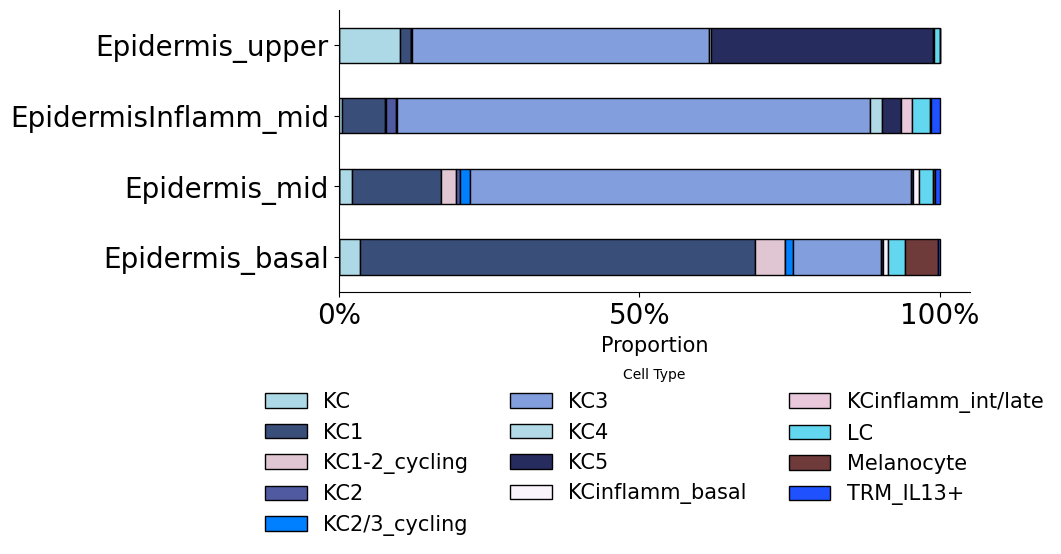

In [7]:
# Constants
COLOR_PICKLE_PATH =  '/nfs/team298/ls34/color_for_adult_skin2.pkl'

NICHE11 = "Epider"
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 100].index
KEEP = ["Non-lesional"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation"]!="F1: Superficial"]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "lvl5_annotation"]].copy()

# Count cell types per niche
grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# #[::-1]
custom_order = [
 


    #'Epidermis_mid1,
    #'Epidermis_APChi',

   # 'EpidermisInflamm_late',
       'Epidermis_upper',
    'EpidermisInflamm_mid',
        'Epidermis_mid',
      #  'Epidermis_basal_cycling',
        "Epidermis_basal"
 #   'Epidermis_basal_immune'
][::-1]

 
proportions = proportions.loc[proportions.index.intersection(custom_order)]
proportions = proportions.reindex(custom_order)

# Filter for plotting and re-normalize so bars reach 100%
plot_proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
plot_proportions = plot_proportions.div(plot_proportions.sum(axis=1), axis=0) * 100

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors
plot_colors = [colors.get(cell_type, "grey") for cell_type in plot_proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

ax.set_ylabel("", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"", fontsize=1)
ax.set_yticks(range(len(plot_proportions)))
ax.set_yticklabels(plot_proportions.index, fontsize=20)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=20)

# Legend below
ax.legend(
    title="Cell Type",
    labels=plot_proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    fontsize=15,
    title_fontsize=10,
    frameon=False
)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    "supp_epidermisINFLAMM_composition.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


 

/tmp/ipykernel_2406173/2807177770.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")


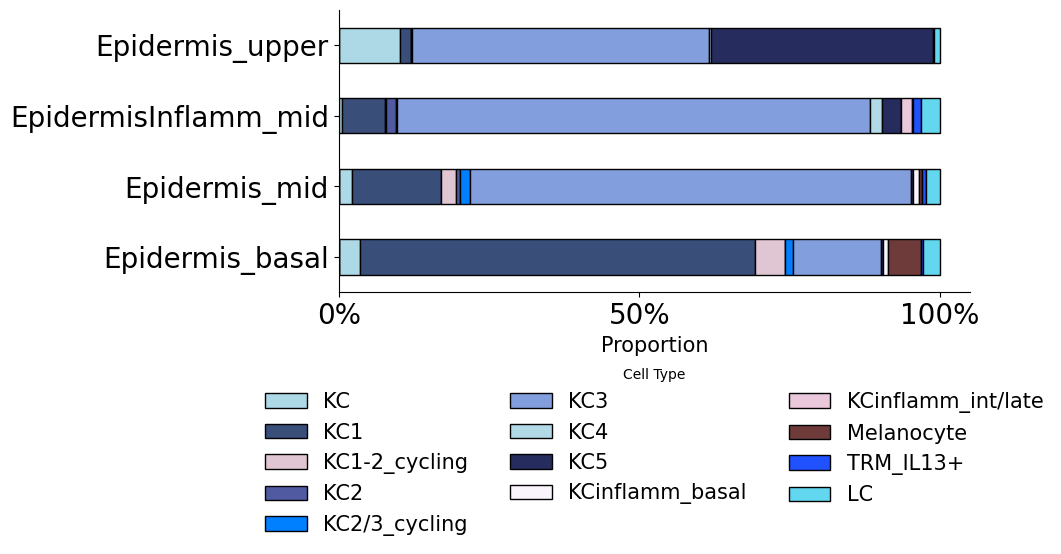

In [11]:
# Constants
COLOR_PICKLE_PATH =  '/nfs/team298/ls34/color_for_adult_skin2.pkl'

NICHE11 = "Epider"
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 100].index
KEEP = ["Non-lesional"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[adata_filtered.obs["lvl5_annotation"]!="F1: Superficial"]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "lvl5_annotation"]].copy()

# Count cell types per niche
grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# #[::-1]
custom_order = [
 


    #'Epidermis_mid1,
    #'Epidermis_APChi',

   # 'EpidermisInflamm_late',
       'Epidermis_upper',
    'EpidermisInflamm_mid',
        'Epidermis_mid',
      #  'Epidermis_basal_cycling',
        "Epidermis_basal"
 #   'Epidermis_basal_immune'
][::-1]

 
proportions = proportions.loc[proportions.index.intersection(custom_order)]
proportions = proportions.reindex(custom_order)

# Filter for plotting and re-normalize so bars reach 100%
plot_proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
plot_proportions = plot_proportions.div(plot_proportions.sum(axis=1), axis=0) * 100

# Move LC to the end of stacking order
cols = list(plot_proportions.columns)
if "LC" in cols:
    cols = [c for c in cols if c != "LC"] + ["LC"]
plot_proportions = plot_proportions[cols]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors
plot_colors = [colors.get(cell_type, "grey") for cell_type in plot_proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

ax.set_ylabel("", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"", fontsize=1)
ax.set_yticks(range(len(plot_proportions)))
ax.set_yticklabels(plot_proportions.index, fontsize=20)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=20)

# Legend below
ax.legend(
    title="Cell Type",
    labels=plot_proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    fontsize=15,
    title_fontsize=10,
    frameon=False
)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    "supp_epidermisINFLAMM_composition.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
 

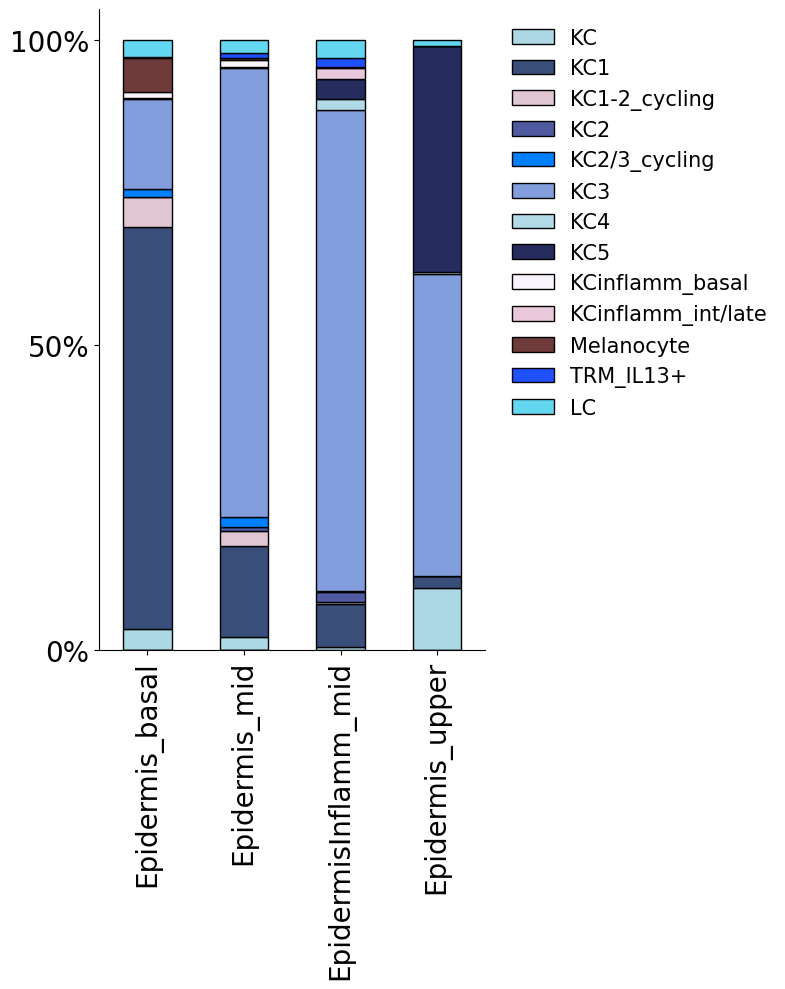

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(8, 10))  # taller than wide

plot_proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axis formatting
ax.set_xlabel("")
ax.set_ylabel("", fontsize=22)
ax.set_title("")

# X-axis labels
ax.set_xticks(range(len(plot_proportions)))
ax.set_xticklabels(plot_proportions.index, fontsize=20, rotation=90)

# Y-axis ticks
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=20)

# Legend to the right
ax.legend(
    labels=plot_proportions.columns,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=1,
    fontsize=15,
    frameon=False,
    title=None
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    "./supp_epidermisINFLAMM_composition_final.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
stpp

NameError: name 'stpp' is not defined

# extra

In [ ]:
adata_5k.obs["lvl5_annotation"].isna().sum()

In [ ]:

# Constants
NICHE11 = "EpidermisInflamm_mid"  # Replace this with your filter string
MINIMUM_PERCENT = 1
COLOR_PICKLE_PATH =  '/nfs/team298/ls34/color_for_adult_skin2.pkl'



# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Nonlesional"]
adata_filtered=adata_filtered[adata_filtered.obs["Site_status_binary"].isin(KEEP)]
# Final filtering"Lesz
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Get disease_overall per sample so we can sort
sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# Sort samples: put one disease on left, the other on right
disease_order = sample_diseases.sort_values().index
proportions = proportions.loc[disease_order]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10,8))
proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate axes
ax.set_xlabel("Sample ID", fontsize=15)
ax.set_ylabel("Proportion", fontsize=15)
ax.set_title(NICHE11, fontsize=15)
ax.set_xticks(range(len(proportions)))
#ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)
ax.set_xticklabels(range(len(proportions)), rotation=0, fontsize=14)

# Y-axis
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



# Add disease group annotations above the bars
import numpy as np

# Get the disease label per bar, in the correct order
disease_labels = sample_diseases.loc[proportions.index]

# Get where the disease groups start and end
disease_groups = disease_labels.groupby(disease_labels).apply(lambda x: (x.index[0], x.index[-1]))

# Determine y-position to draw lines above the bars (just above 100%)
y = 105

for disease, (start_sample, end_sample) in disease_groups.items():
    # Find x-axis positions of the first and last bar in this group
    x_start = proportions.index.get_loc(start_sample)
    x_end = proportions.index.get_loc(end_sample)

    # Draw a horizontal line over the group
    ax.hlines(y, x_start - 0.4, x_end + 0.4, color='black', linewidth=1.5)
    
    # Put the disease label above the line
    ax.text((x_start + x_end) / 2, y + 2, disease, ha='center', va='bottom', fontsize=12, fontweight='bold')

# Extend the y-axis limit so annotations don't get clipped
ax.set_ylim(0, y + 15)


plt.tight_layout()
plt.show()


In [ ]:
adata_filtered.obs.info_id6.value_counts()

In [ ]:
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]

counts = adata_filtered.obs["info_id6"].value_counts()
keep = counts[counts >= 200].index
adata_filtered = adata_filtered[adata_filtered.obs["info_id6"].isin(keep)].copy()

df = adata_filtered.obs[["Site_status", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["Site_status", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="Site_status", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Get disease_overall per sample so we can sort
sample_diseases = df.drop_duplicates("Site_status").set_index("Site_status")["disease_overall"]

# Sort samples: put one disease on left, the other on right
disease_order = sample_diseases.sort_values().index
proportions = proportions.loc[disease_order]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(20, 12))
proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate axes
ax.set_xlabel("Site_status ID", fontsize=15)
ax.set_ylabel("Proportion", fontsize=15)
ax.set_title("Cell Type Proportions by Sample", fontsize=15)
ax.set_xticks(range(len(proportions)))
ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)

# Y-axis
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=10)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
# adata_filtered = adata_5k[
#     adata_5k.obs["niche19"].str.startswith(NICHE11)
# ]

# counts = adata_filtered.obs["info_id6"].value_counts()
# keep = counts[counts >= 500].index
# adata_filtered = adata_filtered[adata_filtered.obs["info_id6"].isin(keep)].copy()
# adata_filtered=adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Les")]

# df = adata_filtered.obs[["sample_id", "niche19", "disease_overall"]].copy()

# # Count cell types per sample
# grouped = df.groupby(["sample_id", "niche19"]).size().reset_index(name="cell_count")

# # Pivot to get counts matrix
# pivot = grouped.pivot(index="sample_id", columns="niche19", values="cell_count").fillna(0)

# # Normalize to get percentages
# proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# # Filter out cell types with too small contribution
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# # Get disease_overall per sample so we can sort
# sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# # Sort samples: put one disease on left, the other on right
# disease_order = sample_diseases.sort_values().index
# proportions = proportions.loc[disease_order]

# # Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# # Map colors to columns
# plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(20, 12))
# proportions.plot(
#     kind="bar",
#     stacked=True,
#     color=plot_colors,
#     edgecolor="black",
#     ax=ax
# )

# # Annotate axes
# ax.set_xlabel("Sample ID", fontsize=15)
# ax.set_ylabel("Proportion", fontsize=15)
# ax.set_title("Cell Type Proportions by Sample", fontsize=15)
# ax.set_xticks(range(len(proportions)))
# ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)

# # Y-axis
# ax.set_yticks([0, 50, 100])
# ax.set_yticklabels(["0%", "50%", "100%"], fontsize=10)

# # Legend
# ax.legend(
#     title="Cell Type",
#     labels=proportions.columns,
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=12,
#     title_fontsize=10,
#     frameon=False
# )

# # Clean up
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# plt.tight_layout()
# plt.show()


In [ ]:
# adata_filtered = adata_5k[
#     adata_5k.obs["niche19"].str.startswith(NICHE11)
# ]

# counts = adata_filtered.obs["info_id6"].value_counts()
# keep = counts[counts >= 500].index
# adata_filtered = adata_filtered[adata_filtered.obs["info_id6"].isin(keep)].copy()

# df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# # Count cell types per sample
# grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# # Pivot to get counts matrix
# pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# # Normalize to get percentages
# proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# # Filter out cell types with too small contribution
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# # Get disease_overall per sample so we can sort
# sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# # Sort samples: put one disease on left, the other on right
# disease_order = sample_diseases.sort_values().index
# proportions = proportions.loc[disease_order]

# # Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# # Map colors to columns
# plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(20, 12))
# proportions.plot(
#     kind="bar",
#     stacked=True,
#     color=plot_colors,
#     edgecolor="black",
#     ax=ax
# )

# # Annotate axes
# ax.set_xlabel("Sample ID", fontsize=15)
# ax.set_ylabel("Proportion", fontsize=15)
# ax.set_title("Cell Type Proportions by Sample", fontsize=15)
# ax.set_xticks(range(len(proportions)))
# ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)

# # Y-axis
# ax.set_yticks([0, 50, 100])
# ax.set_yticklabels(["0%", "50%", "100%"], fontsize=10)

# # Legend
# ax.legend(
#     title="Cell Type",
#     labels=proportions.columns,
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=12,
#     title_fontsize=10,
#     frameon=False
# )

# # Clean up
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# plt.tight_layout()
# plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Constants
NICHE11 = "Epider"  # Replace this with your filter string


# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Non-lesional", "Never lesional"]
adata_filtered=adata_filtered[adata_filtered.obs["Site_status_binary"].isin(KEEP)]
# Final filtering"Lesz
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Get disease_overall per sample so we can sort
sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# Sort samples: put one disease on left, the other on right
disease_order = sample_diseases.sort_values().index
proportions = proportions.loc[disease_order]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10,8))
proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate axes
ax.set_xlabel("Sample ID", fontsize=15)
ax.set_ylabel("Proportion", fontsize=15)
ax.set_title(NICHE11, fontsize=15)
ax.set_xticks(range(len(proportions)))
#ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)
ax.set_xticklabels(range(len(proportions)), rotation=0, fontsize=14)

# Y-axis
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



# Add disease group annotations above the bars
import numpy as np

# Get the disease label per bar, in the correct order
disease_labels = sample_diseases.loc[proportions.index]

# Get where the disease groups start and end
disease_groups = disease_labels.groupby(disease_labels).apply(lambda x: (x.index[0], x.index[-1]))

# Determine y-position to draw lines above the bars (just above 100%)
y = 105

for disease, (start_sample, end_sample) in disease_groups.items():
    # Find x-axis positions of the first and last bar in this group
    x_start = proportions.index.get_loc(start_sample)
    x_end = proportions.index.get_loc(end_sample)

    # Draw a horizontal line over the group
    ax.hlines(y, x_start - 0.4, x_end + 0.4, color='black', linewidth=1.5)
    
    # Put the disease label above the line
    ax.text((x_start + x_end) / 2, y + 2, disease, ha='center', va='bottom', fontsize=12, fontweight='bold')

# Extend the y-axis limit so annotations don't get clipped
ax.set_ylim(0, y + 15)


plt.tight_layout()
plt.show()


# Lesional epidermis composition

In [ ]:
adata_5k_lesional = adata_5k[adata_5k.obs["Site_status"]=="Lesional"]

In [ ]:
# adata_filtered.obs.Site_status_binary.value_counts()

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pickle

# # Constants
# NICHE11 = "Epider"  # Replace this with your filter string
 

# # Filter the data
# adata_filtered = adata_5k[
#     adata_5k.obs["niche19"].str.startswith(NICHE11)
# ]
# sample_counts = adata_filtered.obs["sample_id"].value_counts()
# valid_samples = sample_counts[sample_counts > 1000].index
# KEEP = ["Lesional", "Lesional Baseline"]
# adata_filtered=adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
# # Final filtering"Lesz
# adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
# # Extract relevant columns
# df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# # Count cell types per sample
# grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# # Pivot to get counts matrix
# pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# # Normalize to get percentages
# proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# # Filter out cell types with too small contribution
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# # Get disease_overall per sample so we can sort
# sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# # Sort samples: put one disease on left, the other on right
# disease_order = sample_diseases.sort_values().index
# proportions = proportions.loc[disease_order]

# # Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# # Map colors to columns
# plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# # Plot
# fig, ax = plt.subplots(figsize=(20,8))
# proportions.plot(
#     kind="bar",
#     stacked=True,
#     color=plot_colors,
#     edgecolor="black",
#     ax=ax
# )

# # Annotate axes
# ax.set_xlabel("Sample ID", fontsize=15)
# ax.set_ylabel("Proportion", fontsize=15)
# ax.set_title(NICHE11, fontsize=15)
# ax.set_xticks(range(len(proportions)))
# #ax.set_xticklabels(proportions.index, rotation=90, fontsize=8)
# ax.set_xticklabels(range(len(proportions)), rotation=0, fontsize=14)

# # Y-axis
# ax.set_yticks([0, 50, 100])
# ax.set_yticklabels(["0%", "50%", "100%"], fontsize=14)

# # Legend
# ax.legend(
#     title="Cell Type",
#     labels=proportions.columns,
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=12,
#     title_fontsize=10,
#     frameon=False
# )

# # Clean up
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)



# # Add disease group annotations above the bars
# import numpy as np

# # Get the disease label per bar, in the correct order
# disease_labels = sample_diseases.loc[proportions.index]

# # Get where the disease groups start and end
# disease_groups = disease_labels.groupby(disease_labels).apply(lambda x: (x.index[0], x.index[-1]))

# # Determine y-position to draw lines above the bars (just above 100%)
# y = 105

# for disease, (start_sample, end_sample) in disease_groups.items():
#     # Find x-axis positions of the first and last bar in this group
#     x_start = proportions.index.get_loc(start_sample)
#     x_end = proportions.index.get_loc(end_sample)

#     # Draw a horizontal line over the group
#     ax.hlines(y, x_start - 0.4, x_end + 0.4, color='black', linewidth=1.5)
    
#     # Put the disease label above the line
#     ax.text((x_start + x_end) / 2, y + 2, disease, ha='center', va='bottom', fontsize=12, fontweight='bold')

# # Extend the y-axis limit so annotations don't get clipped
# ax.set_ylim(0, y + 15)


# plt.tight_layout()
# plt.show()


In [ ]:
# Constants
NICHE11 = "Epider"
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]

counts = adata_filtered.obs["info_id6"].value_counts()
keep = counts[counts >= 200].index
adata_filtered = adata_filtered[adata_filtered.obs["info_id6"].isin(keep)].copy()

sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "lvl5_annotation", "disease_overall"]].copy()

# Create a combined index: disease_overall + niche11
df["niche_disease_id"] = df["disease_overall"].astype(str) + " | " + df["niche19"].astype(str)

# Count cell types per combined group
grouped = df.groupby(["niche_disease_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="niche_disease_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Extract disease label from index
proportions["disease"] = proportions.index.str.extract(r'^(.*?)\s+\|')[0]

# Sort by disease group
proportions = proportions.sort_values(by="disease")
disease_labels = proportions["disease"]
proportions = proportions.drop(columns="disease")

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("niche11 by disease", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Niche (Grouped by Disease)", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=12)

# X-axis ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate disease groupings with horizontal lines
group_indices = disease_labels.reset_index(drop=True)
disease_groups = group_indices.groupby(group_indices).apply(lambda x: (x.index[0], x.index[-1]))

y_max = proportions.shape[1] + 5

for disease, (start_idx, end_idx) in disease_groups.items():
    ax.vlines(-5, start_idx - 0.4, end_idx + 0.4, color='black', linewidth=1.5)
    ax.text(-7, (start_idx + end_idx) / 2, disease, va='center', ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:

NICHE11 = "Epider"
MINIMUM_PERCENT = .1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
counts = adata_filtered.obs["info_id6"].value_counts()
keep = counts[counts >= 200].index
adata_filtered = adata_filtered[adata_filtered.obs["info_id6"].isin(keep)].copy()

sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["niche19", "lvl5_annotation"]].copy()

# Count cell types per niche
grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out low-percentage cell types
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to the columns (cell types)
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("niche11", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Niche", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=12)

# X-axis ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
list(adata_filtered.obs["niche19"].unique())

In [ ]:

# Constants
NICHE11 = "Epider"
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "lvl5_annotation"]].copy()

# Count cell types per niche
grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Apply custom order
# custom_order = [
#     'Epidermis_late',
#     'Epidermis_mid',
#     "Epidermis_basal"
#     #'Epidermis_mid1,
#     'Epidermis_APChi',

#     'EpidermisInflamm_late',
#     'EpidermisInflamm_mid',
#         'Epidermis_basal_cycling',
#  #   'Epidermis_basal_immune'
# ]
# #[::-1]
custom_order = [
 


    #'Epidermis_mid1,
    'Epidermis_APChi',

    'EpidermisInflamm_late',
       'Epidermis_late',
    'EpidermisInflamm_mid',
        'Epidermis_mid',
        'Epidermis_basal_cycling',
        "Epidermis_basal"
 #   'Epidermis_basal_immune'
]
#[::-1]
custom_order=custom_order[::-1]
proportions = proportions.loc[proportions.index.intersection(custom_order)]
proportions = proportions.reindex(custom_order)

#Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
   colors = pickle.load(f)

#Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("niche11", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Niche", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=12)

# X-axis ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend below plot
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Constants
NICHE11 = "Epider"
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "lvl5_annotation"]].copy()

# Count cell types per niche
grouped = df.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# # Custom order
# custom_order = [
#     'Epidermis_late',
#     'Epidermis_mid2',
#     'Epidermis_mid1',
#     'Epidermis basal_cycling',
#     'Epidermis_basal',
#     'Epidermis_Inflamm_immune',
#     'Epidermis_basal_immune'
# ][::-1]

proportions = proportions.loc[proportions.index.intersection(custom_order)]
proportions = proportions.reindex(custom_order)

# Filter for plotting and re-normalize so bars reach 100%
plot_proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
plot_proportions = plot_proportions.div(plot_proportions.sum(axis=1), axis=0) * 100

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors
plot_colors = [colors.get(cell_type, "grey") for cell_type in plot_proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

ax.set_ylabel("niche11", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Niche", fontsize=16)
ax.set_yticks(range(len(plot_proportions)))
ax.set_yticklabels(plot_proportions.index, fontsize=12)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend below
ax.legend(
    title="Cell Type",
    labels=plot_proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
adata_5k.obs["Site_status"].value_counts()

In [ ]:
# Plot vertical stacked bars
fig, ax = plt.subplots(figsize=(4, 10))
plot_proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axis labels and ticks
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("Proportion", fontsize=20)
ax.set_title("", fontsize=1)
ax.set_xticks(range(len(plot_proportions)))
ax.set_xticklabels(plot_proportions.index, fontsize=20)  # no rotation
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=20)

# Legend on the right, reversed order
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    ncol=1,
    fontsize=20,
    title_fontsize=10,
    frameon=False
)

# Clean aesthetics
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    "supp_epidermisINFLAMM_composition_VERT.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:

NICHE11 = "Epider"  # Replace this with your filter string
MINIMUM_PERCENT = 1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts per disease group
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(4,8))
proportions.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_xlabel("Disease Group", fontsize=15)
ax.set_ylabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_xticks(range(len(proportions)))
ax.set_xticklabels(proportions.index, rotation=0, fontsize=14)

# Y-axis ticks
ax.set_yticks([0, 50, 100])
ax.set_yticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()


plt.show()


In [ ]:
# Constants
NICHE11 = "Epider"  # Replace this with your filter string
MINIMUM_PERCENT = .1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts per disease group
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 2))
proportions.plot(
    kind="barh",  # HORIZONTAL bars
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)

# X-axis ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:

# Constants
NICHE11 = "Epider"
MINIMUM_PERCENT = 0.1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per disease group
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out low-percentage cell types
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(15, 6))  # increase height to fit legend
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend below plot
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),  # adjust vertical position lower
    ncol=6,  # increase columns to prevent wrapping
    fontsize=12,
    title_fontsize=10,
    frameon=False
)
 
# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
NICHE11 = "Epider"
MINIMUM_PERCENT = 0.1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per disease group
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out low-percentage cell types
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 3))  # increase height to fit legend
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend below plot
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),  # adjust vertical position lower
    ncol=6,  # increase columns to prevent wrapping
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import pickle

with open('/nfs/team298/ls34/niche_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)

# colors_new2 is now the dictionary you saved

In [ ]:


# Constant
NICHE11 = "Epider"

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Drop irrelevant cell types
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["niche19", "disease_overall"]].copy()

# Count niche11 cell types per disease group
grouped = df.groupby(["disease_overall", "niche19"]).size().reset_index(name="count")

# Pivot to matrix
pivot = grouped.pivot(index="disease_overall", columns="niche19", values="count").fillna(0)

# Normalize to get proportions
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# Map colors to niche11 groups
plot_colors = [colors_new2.get(niche, "grey") for niche in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Labels and title
ax.set_ylabel("Disease Group", fontsize=14)
ax.set_xlabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=1)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=12)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=13)

# Legend below
ax.legend(
    title="Niche11",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=4,
    fontsize=11,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:


# Constant
NICHE11 = "Epider"

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
adata_filtered=adata_filtered[adata_filtered.obs["disease_overall"]=="AD"]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Drop irrelevant cell types
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["niche19", "disease_overall"]].copy()

# Count niche11 cell types per disease group
grouped = df.groupby(["disease_overall", "niche19"]).size().reset_index(name="count")

# Pivot to matrix
pivot = grouped.pivot(index="disease_overall", columns="niche19", values="count").fillna(0)

# Normalize to get proportions
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# Map colors to niche11 groups
plot_colors = [colors_new2.get(niche, "grey") for niche in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Labels and title
ax.set_ylabel("", fontsize=14)
ax.set_xlabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=1)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=12)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=13)

# Legend below
ax.legend(
    title="",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    fontsize=11,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    "supp_ADEpidermi_composition.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [ ]:


# Constant
NICHE11 = "Epider"

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
adata_filtered=adata_filtered[adata_filtered.obs["disease_overall"]=="Psoriasis"]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Drop irrelevant cell types
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["niche19", "disease_overall"]].copy()

# Count niche11 cell types per disease group
grouped = df.groupby(["disease_overall", "niche19"]).size().reset_index(name="count")

# Pivot to matrix
pivot = grouped.pivot(index="disease_overall", columns="niche19", values="count").fillna(0)

# Normalize to get proportions
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# Map colors to niche11 groups
plot_colors = [colors_new2.get(niche, "grey") for niche in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Labels and title
ax.set_ylabel("", fontsize=14)
ax.set_xlabel("Proportion", fontsize=14)
ax.set_title(f"", fontsize=1)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=12)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=13)

# Legend below
ax.legend(
    title="",
    labels=proportions.columns,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    fontsize=11,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    "supp_PsoEpidermi_composition.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [ ]:
NICHE11 = "Epider"  # Replace this with your filter string
MINIMUM_PERCENT = .1

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "niche19", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["disease_overall", "niche19"]).size().reset_index(name="cell_count")

# Pivot to get counts per disease group
pivot = grouped.pivot(index="disease_overall", columns="niche19", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with too small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin_XENIUMniches.pkl'

# Load the dictionary from the file
with open(file_path, 'rb') as file:
    colors_new = pickle.load(file)


# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 2))
proportions.plot(
    kind="barh",  # HORIZONTAL bars
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axes labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)

# X-axis ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:


# MINIMUM_PERCENT = 1  # Minimum percentage to show cell types

# # Filter the data for specific niches
# adata_5k_i = adata_5k[adata_5k.obs["Timepoint"].str.startswith("Les")]

# adata_5k_i = adata_5k_i[adata_5k_i.obs["niche19"].str.startswith("Epider")]
# adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"]=="AD")]
# adata_5k_i.obs["Timepoint2"] = [x if "Lesional Baseline" in x else "EXCLUDE" for x in adata_5k_i.obs["info_id2"]]

# #adata_5k_i = adata_5k_i[adata_5k_i.obs["Timepoint2"]!="EXCLUDE"]




# # Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
# data = adata_5k_i.obs[["info_id2", "lvl5_annotation"]]
# grouped_data = data.groupby(["info_id2", "lvl5_annotation"]).size().reset_index(name="cell_count")

# # Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
# pivot_table = grouped_data.pivot(index="info_id2", columns="lvl5_annotation", values="cell_count").fillna(0)

# # Step 3: Normalize the counts to get the proportion of each cell type in each niche
# proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# # Step 4: Exclude cell types with < MINIMUM_PERCENT contribution
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# # Step 5: Create a list of colors based on the annotations present in proportions
# annotations = proportions.columns



# # Apply the colors to the plot
# plot_colors = [colors.get(annotation, "grey") for annotation in annotations]  # Default to grey if no color is found

# # Step 6: Create the stacked bar chart
# ax = proportions.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(10, 6),
#     color=plot_colors,  # Apply custom colors
#     edgecolor="black"
# )

# # Add labels and title
# ax.set_xlabel("Niche Name", fontsize=15)
# ax.set_ylabel("Proportion", fontsize=15)
# ax.set_title("Cell Type Proportions by Niche", fontsize=15)

# # Adjust x-axis ticks for proportions
# ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
# ax.set_yticks([0.0,  50,  100.0])
# ax.set_yticklabels(["0%",  "50%", "100%"], fontsize=10)

# # Customize the legend
# ax.legend(
#     title="Cell Type",
#     labels=annotations,  # Use annotation names
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=12,
#     title_fontsize=10,
#     frameon=False  # Disable the legend box
# )

# # Remove the grid and unnecessary spines
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# # Tight layout for cleaner display
# plt.tight_layout()
# plt.show()

In [ ]:

MINIMUM_PERCENT = 1

# Filter the data for specific niches
adata_5k_i = adata_5k[adata_5k.obs["niche19"].str.startswith("Epide", #"Epidermis mid inflammatory"
                                                      )]
adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"] == "Psoriasis"]

# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
niche_cell_type_counts = adata_5k_i.obs.groupby(["Site_status_binary", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
niche_cell_type_matrix = niche_cell_type_counts.pivot_table(
    index="Site_status_binary", 
    columns="lvl5_annotation", 
    values="cell_count", 
    aggfunc="sum", 
    fill_value=0
)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
niche_cell_type_proportion = niche_cell_type_matrix.div(niche_cell_type_matrix.sum(axis=1), axis=0) * 100

# Step 4: Exclude cell types with < 2% contribution
# Find columns (cell types) where any value is less than MINIMUM_PERCENT in all rows (niches)
filtered_niche_cell_type_proportion = niche_cell_type_proportion.loc[:, (niche_cell_type_proportion >= MINIMUM_PERCENT).any(axis=0)]

# Step 5: Create the heatmap
plt.figure(figsize=(12, 3))
sns.heatmap(
    filtered_niche_cell_type_proportion, 
    cmap="Reds",  # Use the Reds colormap
    annot=False,  # Turn off annotations (numbers in the boxes)
    cbar_kws={"label": "Percentage of Cells"},
    xticklabels=filtered_niche_cell_type_proportion.columns,  # Cell types as x-axis labels
    yticklabels=filtered_niche_cell_type_proportion.index,  # Niches as y-axis labels
    linewidths=0.5,  # Add lines between the cells in the heatmap
    vmax=25  # Limit the max color value to 25 (optional, adjust as needed)
)

# Rotate the x-ticks and y-ticks
plt.xticks(rotation=90)  # Rotate x-axis labels by 90 degrees
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Reverse the y-axis order
plt.gca().invert_yaxis()  # This will invert the order of the y-ticks

# Set plot labels and title
plt.xlabel("Cell type")
plt.ylabel("", fontsize=1)
plt.title("", fontsize=1)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
MINIMUM_PERCENT = 1

# Filter the data for specific niches
adata_5k_i = adata_5k[adata_5k.obs["niche19"].str.startswith("Epide", #"Epidermis mid inflammatory"
                                                      )]
adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"] == "AD"]

# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
niche_cell_type_counts = adata_5k_i.obs.groupby(["Site_status_binary", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
niche_cell_type_matrix = niche_cell_type_counts.pivot_table(
    index="Site_status_binary", 
    columns="lvl5_annotation", 
    values="cell_count", 
    aggfunc="sum", 
    fill_value=0
)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
niche_cell_type_proportion = niche_cell_type_matrix.div(niche_cell_type_matrix.sum(axis=1), axis=0) * 100

# Step 4: Exclude cell types with < 2% contribution
# Find columns (cell types) where any value is less than MINIMUM_PERCENT in all rows (niches)
filtered_niche_cell_type_proportion = niche_cell_type_proportion.loc[:, (niche_cell_type_proportion >= MINIMUM_PERCENT).any(axis=0)]

# Step 5: Create the heatmap
plt.figure(figsize=(12, 3))
sns.heatmap(
    filtered_niche_cell_type_proportion, 
    cmap="Reds",  # Use the Reds colormap
    annot=False,  # Turn off annotations (numbers in the boxes)
    cbar_kws={"label": "Percentage of Cells"},
    xticklabels=filtered_niche_cell_type_proportion.columns,  # Cell types as x-axis labels
    yticklabels=filtered_niche_cell_type_proportion.index,  # Niches as y-axis labels
    linewidths=0.5,  # Add lines between the cells in the heatmap
    vmax=25  # Limit the max color value to 25 (optional, adjust as needed)
)

# Rotate the x-ticks and y-ticks
plt.xticks(rotation=90)  # Rotate x-axis labels by 90 degrees
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Reverse the y-axis order
plt.gca().invert_yaxis()  # This will invert the order of the y-ticks

# Set plot labels and title
plt.xlabel("Cell type")
plt.ylabel("", fontsize=1)
plt.title("", fontsize=1)

# Display the plot
plt.tight_layout()
plt.show()

# other niche

In [ ]:

# NICHE11 = "Small_BV"
# MINIMUM_PERCENT = 0
# MIN_PERCENT_FOR_TEXT=2

# # Filter the data
# adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
# sample_counts = adata_filtered.obs["sample_id"].value_counts()
# valid_samples = sample_counts[sample_counts > 10].index

# adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Les")]
# adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
# adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
# adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
# adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# # Extract relevant columns
# df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# # Count cell types per disease group
# grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")
# pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# # Normalize to get percentages
# proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# # Filter out low-percentage cell types
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
# list(proportions.columns)

# # Define exact order

# # Keep only cell types that are in both the order and the data
#ordered_celltypes = [ct for ct in ordered_celltypes if ct in proportions.columns]
# # proportions = proportions[ordered_celltypes]

# # # Load colors
# # with open(COLOR_PICKLE_PATH, 'rb') as f:
# #     colors = pickle.load(f)

# # Map colors according to new order
# #plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# # Plot
# fig, ax = plt.subplots(figsize=(12, 6))
# bars = proportions.plot(
#     kind="barh",
#     stacked=True,
#     #color=plot_colors,
#     edgecolor="black",
#     ax=ax
# )

# # Annotate bars with cell type label if >5%
# for i, (idx, row) in enumerate(proportions.iterrows()):
#     cum_width = 0
#     for j, val in enumerate(row):
#         if val > MIN_PERCENT_FOR_TEXT:
#             ax.text(
#                 cum_width + val / 2,
#                 i,
#                 ordered_celltypes[j],
#                 ha='center',
#                 va='center',
#                 fontsize=8,
#                 color='black',
#                 clip_on=True
#             )
#         cum_width += val

# # Labels and title
# ax.set_ylabel("Disease Group", fontsize=15)
# ax.set_xlabel("Proportion", fontsize=15)
# ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
# ax.set_yticks(range(len(proportions)))
# ax.set_yticklabels(proportions.index, fontsize=14)
# ax.set_xticks([0, 50, 100])
# ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# # Legend
# ax.legend(
#     title="Cell Type",
#     labels=ordered_celltypes,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.35),
#     ncol=6,
#     fontsize=10,
#     title_fontsize=10,
#     frameon=False
# )

# # Clean up
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()


In [ ]:

NICHE11 = "Papillary_dermis"
MINIMUM_PERCENT = 0
MIN_PERCENT_FOR_TEXT=2

# Filter the data
adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Les")]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per disease group
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out low-percentage cell types
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
list(proportions.columns)

In [ ]:
# for x in list(proportions.columns): 
#     if x not in ordered_celltypes:
#         print(x)

In [ ]:

# Keep only cell types that are in both the order and the data
ordered_celltypes = [ct for ct in ordered_celltypes if ct in proportions.columns]
proportions = proportions[ordered_celltypes]

# # Load colors
# with open(COLOR_PICKLE_PATH, 'rb') as f:
#     colors = pickle.load(f)

# Map colors according to new order
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate bars with cell type label if >5%
for i, (idx, row) in enumerate(proportions.iterrows()):
    cum_width = 0
    for j, val in enumerate(row):
        if val > MIN_PERCENT_FOR_TEXT:
            ax.text(
                cum_width + val / 2,
                i,
                ordered_celltypes[j],
                ha='center',
                va='center',
                fontsize=8,
                color='black',
                clip_on=True
            )
        cum_width += val

# Labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=ordered_celltypes,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=6,
    fontsize=10,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
[x for x in adata_5k.obs["lvl5_annotation"].unique() if x.startswith("VE")]

In [ ]:
adata_5k[adata_5k.obs["lvl5_annotation"].str.startswith("VE3_Ven_APLN+")].obs.niche12.value_counts()


In [ ]:
# 


In [ ]:
# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

# adata_5k_i.obs["Timepoint"].value_counts()

# adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#    # adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche12",
#         size=35,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#         legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12,
        

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

In [ ]:
# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

# adata_5k_i.obs["Timepoint"].value_counts()

# adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#    # adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche12",
#         size=35,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#         legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12,
        

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

In [ ]:
# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

# adata_5k_i.obs["Timepoint"].value_counts()

# adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#    # adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche12",
#         size=35,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#         legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12,
        

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

In [ ]:
# Constants
#NICHE11 = "Lymph"
MINIMUM_PERCENT = 0
MIN_PERCENT_FOR_TEXT=2
#COLOR_PICKLE_PATH = '/nfs/team298/ls34/color_for_adult_skin_XENIUMcelltypes.pkl'

# Filter the data
adata_filtered = adata_5k[adata_5k.obs["niche19"].str.startswith(NICHE11)]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index

adata_filtered = adata_filtered[adata_filtered.obs["Site_status"].str.startswith("Les")]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("KC_S")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Sweat")]
adata_filtered = adata_filtered[~adata_filtered.obs["lvl5_annotation"].str.startswith("Nonsp")]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per disease group
grouped = df.groupby(["disease_overall", "lvl5_annotation"]).size().reset_index(name="cell_count")
pivot = grouped.pivot(index="disease_overall", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out low-percentage cell types
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]


# Keep only cell types that are in both the order and the data
ordered_celltypes = [ct for ct in ordered_celltypes if ct in proportions.columns]
proportions = proportions[ordered_celltypes]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors according to new order
plot_colors = [colors.get(cell_type, "grey") for cell_type in ordered_celltypes]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate bars with cell type label if >5%
for i, (idx, row) in enumerate(proportions.iterrows()):
    cum_width = 0
    for j, val in enumerate(row):
        if val > MIN_PERCENT_FOR_TEXT:
            ax.text(
                cum_width + val / 2,
                i,
                ordered_celltypes[j],
                ha='center',
                va='center',
                fontsize=8,
                color='black',
                clip_on=True
            )
        cum_width += val

# Labels and title
ax.set_ylabel("Disease Group", fontsize=15)
ax.set_xlabel("Proportion", fontsize=15)
ax.set_title(f"{NICHE11} — Cell Type Proportions per Disease", fontsize=16)
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=14)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=ordered_celltypes,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=6,
    fontsize=10,
    title_fontsize=10,
    frameon=False
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
adata_5k_i = adata_5k[adata_5k.obs["niche19"].isin(["Tzone-like", #"Epidermis mid inflammatory"
                                                      ])]
adata_5k_i=adata_5k_i[adata_5k_i.obs["Site_status_binary"].isin(["Never lesional", "Non-lesional", "Lesional"])]
# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
niche_cell_type_counts = adata_5k_i.obs.groupby(["Site_status_binary", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
niche_cell_type_matrix = niche_cell_type_counts.pivot_table(
    index="Site_status_binary", 
    columns="lvl5_annotation", 
    values="cell_count", 
    aggfunc="sum", 
    fill_value=0
)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
niche_cell_type_proportion = niche_cell_type_matrix.div(niche_cell_type_matrix.sum(axis=1), axis=0) * 100

# Step 4: Create the heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(
    niche_cell_type_proportion, 
    cmap="Reds",  # Use the Reds colormap
    annot=False,  # Turn off annotations (numbers in the boxes)
    cbar_kws={"label": "Percentage of Cells"},
    xticklabels=niche_cell_type_proportion.columns,  # Cell types as x-axis labels
    yticklabels=niche_cell_type_proportion.index,  # Niches as y-axis labels
    linewidths=0.5,  # Add lines between the cells in the heatmap
    vmax=25
)

# # Set plot labels and title
plt.xlabel("Cell type")
plt.ylabel("", fontsize=1)
plt.title("", fontsize=1)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
MINIMUM_PERCENT = 1

# Filter the data for specific niches
adata_5k_i = adata_5k[adata_5k.obs["niche19"].isin(["Tzone-like", #"Epidermis mid inflammatory"
                                                      ])]
adata_5k_i=adata_5k_i[adata_5k_i.obs["Site_status_binary"].isin(["Never lesional", "Non-lesional", "Lesional"])]

adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"] == "AD"]

# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
niche_cell_type_counts = adata_5k_i.obs.groupby(["Site_status_binary", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
niche_cell_type_matrix = niche_cell_type_counts.pivot_table(
    index="Site_status_binary", 
    columns="lvl5_annotation", 
    values="cell_count", 
    aggfunc="sum", 
    fill_value=0
)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
niche_cell_type_proportion = niche_cell_type_matrix.div(niche_cell_type_matrix.sum(axis=1), axis=0) * 100

# Step 4: Exclude cell types with < 2% contribution
# Find columns (cell types) where any value is less than MINIMUM_PERCENT in all rows (niches)
filtered_niche_cell_type_proportion = niche_cell_type_proportion.loc[:, (niche_cell_type_proportion >= MINIMUM_PERCENT).any(axis=0)]

# Step 5: Create the heatmap
plt.figure(figsize=(12, 3))
sns.heatmap(
    filtered_niche_cell_type_proportion, 
    cmap="Reds",  # Use the Reds colormap
    annot=False,  # Turn off annotations (numbers in the boxes)
    cbar_kws={"label": "Percentage of Cells"},
    xticklabels=filtered_niche_cell_type_proportion.columns,  # Cell types as x-axis labels
    yticklabels=filtered_niche_cell_type_proportion.index,  # Niches as y-axis labels
    linewidths=0.5,  # Add lines between the cells in the heatmap
    vmax=25  # Limit the max color value to 25 (optional, adjust as needed)
)

# Rotate the x-ticks and y-ticks
plt.xticks(rotation=90)  # Rotate x-axis labels by 90 degrees
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Reverse the y-axis order
plt.gca().invert_yaxis()  # This will invert the order of the y-ticks

# Set plot labels and title
plt.xlabel("Cell type")
plt.ylabel("", fontsize=1)
plt.title("", fontsize=1)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

MINIMUM_PERCENT = 1

# Filter the data for specific niches
adata_5k_i = adata_5k[adata_5k.obs["niche19"].isin(["Tzone-like", #"Epidermis mid inflammatory"
                                                      ])]
adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"] == "Psoriasis"]

# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
niche_cell_type_counts = adata_5k_i.obs.groupby(["Site_status_binary", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
niche_cell_type_matrix = niche_cell_type_counts.pivot_table(
    index="Site_status_binary", 
    columns="lvl5_annotation", 
    values="cell_count", 
    aggfunc="sum", 
    fill_value=0
)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
niche_cell_type_proportion = niche_cell_type_matrix.div(niche_cell_type_matrix.sum(axis=1), axis=0) * 100

# Step 4: Exclude cell types with < 2% contribution
# Find columns (cell types) where any value is less than MINIMUM_PERCENT in all rows (niches)
filtered_niche_cell_type_proportion = niche_cell_type_proportion.loc[:, (niche_cell_type_proportion >= MINIMUM_PERCENT).any(axis=0)]

# Step 5: Create the heatmap
plt.figure(figsize=(12, 3))
sns.heatmap(
    filtered_niche_cell_type_proportion, 
    cmap="Reds",  # Use the Reds colormap
    annot=False,  # Turn off annotations (numbers in the boxes)
    cbar_kws={"label": "Percentage of Cells"},
    xticklabels=filtered_niche_cell_type_proportion.columns,  # Cell types as x-axis labels
    yticklabels=filtered_niche_cell_type_proportion.index,  # Niches as y-axis labels
    linewidths=0.5,  # Add lines between the cells in the heatmap
    vmax=25  # Limit the max color value to 25 (optional, adjust as needed)
)

# Rotate the x-ticks and y-ticks
plt.xticks(rotation=90)  # Rotate x-axis labels by 90 degrees
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

# Reverse the y-axis order
plt.gca().invert_yaxis()  # This will invert the order of the y-ticks

# Set plot labels and title
plt.xlabel("Cell type")
plt.ylabel("", fontsize=1)
plt.title("", fontsize=1)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# import seaborn as sns
# import pandas as pd
# import matplotlib.pyplot as plt

# MINIMUM_PERCENT = 1  # Minimum percentage to show cell types

# # Filter the data for specific niches
# adata_5k_i = adata_5k[adata_5k.obs["Timepoint"].str.startswith("Les")]

# adata_5k_i = adata_5k_i[adata_5k_i.obs["niche19"].str.startswith("Tz")]
# adata_5k_i = adata_5k_i[adata_5k_i.obs["disease_overall"].str.startswith("Pso")]


# # Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
# data = adata_5k_i.obs[["info_id2", "lvl5_annotation"]]
# grouped_data = data.groupby(["info_id2", "lvl5_annotation"]).size().reset_index(name="cell_count")

# # Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
# pivot_table = grouped_data.pivot(index="info_id2", columns="lvl5_annotation", values="cell_count").fillna(0)

# # Step 3: Normalize the counts to get the proportion of each cell type in each niche
# proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# # Step 4: Exclude cell types with < MINIMUM_PERCENT contribution
# proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# # Step 5: Create a list of colors based on the annotations present in proportions
# annotations = proportions.columns

# # Generate a color palette for each unique annotation
# # Using seaborn color palette for distinct colors



# # Apply the colors to the plot
# plot_colors = [colors.get(annotation, "grey") for annotation in annotations]  # Default to grey if no color is found

# # Step 6: Create the stacked bar chart
# ax = proportions.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(6, 6),
#     color=plot_colors,  # Apply custom colors
#     edgecolor="black"
# )

# # Add labels and title
# ax.set_xlabel("Niche Name", fontsize=15)
# ax.set_ylabel("Proportion", fontsize=15)
# ax.set_title("Cell Type Proportions by Niche", fontsize=15)

# # Adjust x-axis ticks for proportions
# ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
# ax.set_yticks([0.0,  50,  100.0])
# ax.set_yticklabels(["0%",  "50%", "100%"], fontsize=10)

# # Customize the legend
# ax.legend(
#     title="Cell Type",
#     labels=annotations,  # Use annotation names
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     fontsize=12,
#     title_fontsize=10,
#     frameon=False  # Disable the legend box
# )

# # Remove the grid and unnecessary spines
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# # Tight layout for cleaner display
# plt.tight_layout()
# plt.show()

In [ ]:
adata_5k[adata_5k.obs["lvl5_annotation"].str.startswith("F6")].obs.niche12.value_counts()

# sebaceous gland

In [ ]:
#FILE_NAME = "adata_xenium_v3.h5ad.final.timepointsforpaper"
#PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
#FILE_NAME = "adata_xenium_freeze.h5ad"  #"adata_xenium_v3.h5ad.final.timepointsforpaper"
# PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'

# adata_5k=sc.read_h5ad(PATH)
# adata_5k.obs["Timepoint2"].value_counts()
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.nohealthy'
adata_5k=sc.read_h5ad(PATH)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"].copy()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST




 

adata_5k.obs["Site_status"].value_counts()




In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Constants
NICHE11 = "Epider"

COLOR_PICKLE_PATH =  '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Lesional Baseline"]
adata_filtered = adata_filtered[adata_filtered.obs["Timepoint"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract and filter
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()
df = df[~df["lvl5_annotation"].str.startswith("KC")]

# Count cell types per sample
grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# Rename for clarity
counts = pivot.copy()

# Get disease_overall per sample for sorting and annotation
sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]
disease_order = sample_diseases.sort_values().index
counts = counts.loc[disease_order]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in counts.columns]

# Plot
fig, ax = plt.subplots(figsize=(30,30))
plot = counts.plot(
    kind="bar",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Annotate each bar segment with its label if it's tall enough
for bar_index, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 20:  # Skip tiny bars to avoid clutter; adjust as needed
            x = rect.get_x() + rect.get_width() / 2
            y = rect.get_y() + height / 2
            label = bar.get_label()
            ax.text(x, y, label, ha='center', va='center', fontsize=9, rotation=90, color='white', fontweight='bold')

# Axes
ax.set_xlabel("Sample ID", fontsize=15)
ax.set_ylabel("Cell Count", fontsize=15)
ax.set_title(NICHE11, fontsize=15)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(range(len(counts)), rotation=0, fontsize=14)

# Y-axis ticks as integers
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)

# Legend
ax.legend(
    title="Cell Type",
    labels=counts.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False
)

# Clean plot
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Disease group annotations
disease_labels = sample_diseases.loc[counts.index]
disease_groups = disease_labels.groupby(disease_labels).apply(lambda x: (x.index[0], x.index[-1]))

# Set y line height a bit above max
y = counts.max().max() * 1.05

for disease, (start_sample, end_sample) in disease_groups.items():
    x_start = counts.index.get_loc(start_sample)
    x_end = counts.index.get_loc(end_sample)
    ax.hlines(y, x_start - 0.4, x_end + 0.4, color='black', linewidth=1.5)
    ax.text((x_start + x_end) / 2, y + 10, disease, ha='center', va='bottom', fontsize=12, fontweight='bold')

# Extend y-axis
ax.set_ylim(0, y + 500)

plt.tight_layout()
plt.show()


In [ ]:
MINIMUM_PERCENT = 1  # Minimum percentage to show cell types

# Filter the data for specific niches
adata_5k_i = adata_5k[adata_5k.obs["Site_status"]=="Non-lesional"].copy()
adata_5k_i
# Step 1: Compute the count of each cell type (lvl5_annotation) in each niche (niche_name)
data = adata_5k_i.obs[["niche19", "lvl5_annotation"]]
grouped_data = data.groupby(["niche19", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Step 2: Pivot the table to get a matrix format where each row is a niche and each column is a cell type
pivot_table = grouped_data.pivot(index="niche19", columns="lvl5_annotation", values="cell_count").fillna(0)

# Step 3: Normalize the counts to get the proportion of each cell type in each niche
proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Step 4: Exclude cell types with < MINIMUM_PERCENT contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]

# Step 5: Create a list of colors based on the annotations present in proportions
annotations = proportions.columns

# Generate a color palette for each unique annotation
# Using seaborn color palette for distinct colors
# import pickle

# # Define the file path
# file_path = '/nfs/team298/ls34/color_for_adult_skin_XENIUMcelltypes.pkl'

# # Load the dictionary from the pickle file
# with open(file_path, 'rb') as f:
#     colors = pickle.load(f)


# Apply the colors to the plot
plot_colors = [colors.get(annotation, "grey") for annotation in annotations]  # Default to grey if no color is found

# Step 6: Create the stacked bar chart
ax = proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(20, 6),
    color=plot_colors,  # Apply custom colors
    edgecolor="black"
)

# Add labels and title
ax.set_xlabel("Niche Name", fontsize=15)
ax.set_ylabel("Proportion", fontsize=15)
ax.set_title("Cell Type Proportions by Niche", fontsize=15)

# Adjust x-axis ticks for proportions
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticks([0.0,  50,  100.0])
ax.set_yticklabels(["0%",  "50%", "100%"], fontsize=10)

# Customize the legend
ax.legend(
    title="Cell Type",
    labels=annotations,  # Use annotation names
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=10,
    frameon=False  # Disable the legend box
)

# Remove the grid and unnecessary spines
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout for cleaner display
plt.tight_layout()
plt.show()

# Psoriasis epidermis only

In [ ]:
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]
# adata_5k_i.obs.Timepoint.value_counts()

In [ ]:
"""
find niche
"""
import warnings
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))



# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    if adata_i.shape[0] > 5000:
        SPOTSIZE=40
    else:
        SPOTSIZE=130

    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche19",
        size=SPOTSIZE,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.2,
                legend_fontsize=12,

        
        save = f"EpidermisONLY_{DONOR_ID}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )

#     sq.pl.spatial_scatter(
#             adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#             library_id="spatial",
#             shape=None,
#             color="niche19",
#             size=SPOTSIZE,
#             vmax=1,
#             title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#             #title=INFO_ID, #+ "_nonlesional",
#             # legend_loc=None,
#             #legend_loc="on data",
#                     edgecolor="black",
#             linewidth=0.1,
#                     legend_fontsize=12,
#             save = f"EpidermisONLY__{DONOR_ID}_PSOLEGEND.pdf"

#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )
    #     if i>1:
    #         break

#     sc.pl.spatial(
#             adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#             #library_id="spatial",
#             #shape=None,
#             color="niche19",
#             spot_size=15,
#             vmax=1,
#             title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#             #title=INFO_ID, #+ "_nonlesional",
#             legend_loc=None,
#             # legend_loc="on data",
#                     edgecolor="black",
#             linewidth=0.1,
#                     legend_fontsize=12,


#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )

In [ ]:
"""
find niche
"""
import warnings
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))



# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    if adata_i.shape[0] > 5000:
        SPOTSIZE=40
    else:
        SPOTSIZE=130

 

    sq.pl.spatial_scatter(
            adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
            library_id="spatial",
            shape=None,
            color="niche19",
            size=SPOTSIZE,
            vmax=1,
            title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
            #title=INFO_ID, #+ "_nonlesional",
            # legend_loc=None,
            #legend_loc="on data",
                    edgecolor="black",
            linewidth=0.1,
                    legend_fontsize=12,
           save = f"EpidermisONLY__{DONOR_ID}_PSOLEGEND.pdf"

            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
    #     if i>1:
    #         break

#     sc.pl.spatial(
#             adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#             #library_id="spatial",
#             #shape=None,
#             color="niche19",
#             spot_size=15,
#             vmax=1,
#             title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#             #title=INFO_ID, #+ "_nonlesional",
#             legend_loc=None,
#             # legend_loc="on data",
#                     edgecolor="black",
#             linewidth=0.1,
#                     legend_fontsize=12,


#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )

In [ ]:
adata_5k.obs["Timepoint"].value_counts()

In [ ]:
adata_5k.obs["Site_status"].value_counts()

# ad epidermis only

In [ ]:
"""
find niche
"""
import warnings

sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    if adata_i.shape[0] > 5000:
        SPOTSIZE=40
    else:
         SPOTSIZE=120
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche19",
        size=SPOTSIZE,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        save = f"EpidermisONLY_{DONOR_ID}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    

In [ ]:
"""
find niche
"""
import warnings

sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1

adata_5k_i= adata_5k[adata_5k.obs["Site_status"] == "Psoriasis_replicate_Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    if adata_i.shape[0] > 5000:
        SPOTSIZE=40
    else:
         SPOTSIZE=120
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche19",
        size=SPOTSIZE,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        save = f"EpidermisONLY_{DONOR_ID}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

In [ ]:
"""
find niche
"""
import warnings

sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "3D_Lesional_baseline"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    if adata_i.shape[0] > 5000:
        SPOTSIZE=40
    else:
         SPOTSIZE=120
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche19",
        size=SPOTSIZE,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        save = f"EpidermisONLY_{DONOR_ID}.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

# TZZONE

In [ ]:
"""
find niche
"""
import warnings

sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(30,30))

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
adata_5k_i= adata_5k

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[(adata_i.obs["niche19"].str.startswith("Tzon"))|
                    (adata_i.obs["niche19"].str.startswith("Small"))|
                    (adata_i.obs["niche19"].str.startswith("Large"))|
                                        (adata_i.obs["niche19"].str.startswith("Perin"))

                   
                   ]
    if adata_i[adata_i.obs["niche19"].str.startswith("Tzon")].shape[0] > 5000:
        SPOTSIZE=60
    else:
         SPOTSIZE=80
    if adata_i[adata_i.obs["niche19"]=="Tzone-like"].shape[0]>500:
        sq.pl.spatial_scatter(
            adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
            library_id="spatial",
            shape=None,
            color="niche19",
            size=SPOTSIZE,
            vmax=1,
            title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
            #title=INFO_ID, #+ "_nonlesional",
            # legend_loc=None,
            # legend_loc="on data",
                    edgecolor="black",
            linewidth=0.3,
                    legend_fontsize=12,
            save = f"TzoneBV_{DONOR_ID}.pdf"

            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
#     adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Tzon")]
#     if adata_i.shape[0] > 2000:
#         SPOTSIZE=30
#     else:
#          SPOTSIZE=50
    if adata_i.shape[0]>500:
        sq.pl.spatial_scatter(
            adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
            library_id="spatial",
            shape=None,
            color="lvl5_annotation",
            size=SPOTSIZE,
            vmax=1,
            title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
            #title=INFO_ID, #+ "_nonlesional",
            legend_loc=None,
            # legend_loc="on data",
                    edgecolor="black",
            linewidth=0.3,
                    legend_fontsize=12,
            save = f"Tzone_{DONOR_ID}.pdf"

            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )



In [ ]:
1

In [ ]:
# """
# find niche
# """
# import warnings

# sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# adata_5k_i= adata_5k

# adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#     adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Tzon")]
#     if adata_i.shape[0] > 5000:
#         SPOTSIZE=40
#     else:
#          SPOTSIZE=60
#     if adata_i.shape[0]>200:
#         sq.pl.spatial_scatter(
#             adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#             library_id="spatial",
#             shape=None,
#             color="lvl5_annotation",
#             size=SPOTSIZE,
#             vmax=1,
#             title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#             #title=INFO_ID, #+ "_nonlesional",
#             # legend_loc=None,
#             # legend_loc="on data",
#                     edgecolor="black",
#             linewidth=0.1,
#                     legend_fontsize=12,
#             save = f"Tzone_{DONOR_ID}.pdf"

#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )


In [ ]:
1

In [ ]:
2

In [ ]:
# colors={'Adipocyte': '#FFFFFF',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#         'F1: Superficial regenerative': '#FFFFE4',
# 'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1-2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#B3C6F1',
#  'KC5': '#2F3466',
#  'KC_HF: Basal': '#006400',
#  'KC_HF: IRS': '#abe8bd',
#             "KC_HF: HS": "#bff2cd",

#  'KC_HF: ORS/CL': '#94cb72',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
# # 'LC_CCR7+': '#5F3D7D',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#         "Mac_TREM2+LPL+": '#845DAE',
#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell': '#FF1493',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1_CCL19+': '#F7A3C3',
#         'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#801F4D',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_duct_inner': '#ffd1a3',
#         'KC_Sebocyte_PPARG+_inner': '#FFFFE0',
#         'KC_Sebocyte_PPARG+_basal/outer' : '#e28743',
        
#     'KC_Sebocyte_duct_basal/outer':  '#703A1A',
#  'Sweat gland': '#00CCCC',
#          'Sweat gland Myoepithelial': "#008080",#'#004444',

#  'Sweat gland channel': '#2DA8A0',
#         'Sweat gland channel outer': "#B3FFF0",#'#4
#  'Sweat gland channel_inner': "#FFE5B4",#'#D1F9F6',
#         'Sweat gland channel inner':  "#FFE5B4",  #D
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#B3FFF0",#'#40E0D0',
#    'T': '#F4D1A1',
#     'T_Prolif': '#D4B082',
#     'Tc': '#8C6A3B',
#     'Tc_IL13': '#F87A7B',
#         'TRM_IL13':  '#F87A7B',
#         'TRM_IL17':  '#F87A7B',
#     'Tnaive/Tcm': '#C6A476',
#     'Treg': '#9E7A55',
#     'Treg_LRRC32': "#9E5E3A",#'#7E5F43',
#         'Treg_LRRC32+': "#9E5E3A",#'#7E5F43',
#  'VE2': '#9f1a1a',
#         'VE4_Cap': '#D96B6B',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#d73435',
#  'cDC1': '#9B70C1',
#  'cDC2': '#6F478C',
#   'cDC2: MMP12hi': '#7D56A3',
#  'mSchwann': '#1A140B',
#  'nmSchwann': '#0A0A0A',
#  'pDC': '#D85B8C',
        
        
        
# ### scrna only
#         'AXL+SIGLEC6+ DC': "#9b4ef5",
# 'Bcell': "#e14d00",
# 'Cartilage': "#404040", 
# 'F4: DP_HHIP+': "#26a83f",
# 'F6: Inflammatory myofibroblast': "#00ffff",
# 'F_Fascia': "#000000",
# 'ILC1_3': "#FFFF00",
# 'ILC1_NK': "#F4D03F",
# 'ILC2': "#F1C40F",
# 'ILC2_inflammatory': "#C79A00",
# 'KC1': "#3a4e7a",
# 'KC2': "#505aa1",
# 'KC_HF: Basal_LGR5+': "#00b300",
# 'KC_HF: Basal_NPNT+': "#006400",
#          'KC_HF: ORS-0':  "#003200",
#          'KC_HF: ORS-1':  "#006400",
#         'KC_HF: ORS-2':  "#006400",
# 'KCinflamm_basal': "#f9f3fb",
# 'KCinflamm_cycling':"#e0c5d2", #007FFF
# 'KCinflamm_int': "#f5d3e7",
# 'LC_CCR7+': "#3bc1a4",
# 'Mac1': "#6A3F9B",
# 'MacTREM2_CX3CR1+': "#9D1A80",
# 'Merkel cell': "#2f2f2f",
# 'MoDC': "#7F00A2",
# "MoDC/cDC2: MMP12+": "#7F00A2",
#         'Mac_prolif':  "#D8A7FF",
# 'Mono': "#D8A7FF",
# 'Mono CD16+': "#E1C6FF",
# 'NK': "#FFEB3B",
# 'Neutrophil': "#4D3F8C",
# 'Satellite muscle': "#F387C7",
# 'Skeletal muscle': "#F14D8E",
# 'Tc_IFNGhi': "#F5A600",
# 'Tc_IL17': "#B84A3D",#"#A75C3E",
# 'Tc_ZNF683+/γδ': "#D4B082",
# 'Th': "#F4D1A1",
# 'Tr1': "#5F452F", 
#         'TR1': "#5F452F", 
# 'cDC2: IL1B+': "#B78FE1",
       
#        }

# import pickle
# file_path = '/nfs/team298/ls34/color_for_adult_skin_XENIUMcelltypes.pkl'

# # Save the dictionary to the file
# with open(file_path, 'wb') as file:
#     pickle.dump(colors, file)

# for x in adata_5k.obs['final_annotation_lvl4'].unique():
#     if x not in colors.keys():
#         print(x)
        


In [ ]:

# adata_5k.obs['final_annotation_lvl4'] =adata_5k.obs['final_annotation_lvl4'] .astype('category')
# adata_5k.uns['final_annotation_lvl4_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_5k.obs['final_annotation_lvl4'].cat.categories]

In [ ]:
# colors={'Adipocyte': '#FFFFFF',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#         'F1: Superficial regenerative': '#FFFFE4',
# 'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1-2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#B3C6F1',
#  'KC5': '#2F3466',
#  'KC_HF: Basal': '#006400',
#  'KC_HF: IRS': '#abe8bd',
#             "KC_HF: HS": "#bff2cd",

#  'KC_HF: ORS/CL': '#94cb72',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
# # 'LC_CCR7+': '#5F3D7D',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#         "Mac_TREM2+LPL+": '#845DAE',
#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell': '#FF1493',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1_CCL19+': '#F7A3C3',
#         'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#801F4D',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_duct_inner': '#ffd1a3',
#         'KC_Sebocyte_PPARG+_inner': '#FFFFE0',
#         'KC_Sebocyte_PPARG+_basal/outer' : '#e28743',
        
#     'KC_Sebocyte_duct_basal/outer':  '#703A1A',
#  'Sweat gland': '#00CCCC',
#          'Sweat gland Myoepithelial': "#008080",#'#004444',

#  'Sweat gland channel': '#2DA8A0',
#         'Sweat gland channel outer': "#B3FFF0",#'#4
#  'Sweat gland channel_inner': "#FFE5B4",#'#D1F9F6',
#         'Sweat gland channel inner':  "#FFE5B4",  #D
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#B3FFF0",#'#40E0D0',
#    'T': '#F4D1A1',
#     'T_Prolif': '#D4B082',
#     'Tc': '#8C6A3B',
#     'Tc_IL13': '#F87A7B',
#         'TRM_IL13':  '#F87A7B',
#         'TRM_IL17':  '#F87A7B',
#     'Tnaive/Tcm': '#C6A476',
#     'Treg': '#9E7A55',
#     'Treg_LRRC32': "#9E5E3A",#'#7E5F43',
#         'Treg_LRRC32+': "#9E5E3A",#'#7E5F43',
#  'VE2': '#9f1a1a',
#         'VE4_Cap': '#D96B6B',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#d73435',
#  'cDC1': '#9B70C1',
#  'cDC2': '#6F478C',
#   'cDC2: MMP12hi': '#7D56A3',
#  'mSchwann': '#1A140B',
#  'nmSchwann': '#0A0A0A',
#  'pDC': '#D85B8C',
        
        
        
# ### scrna only
#         'AXL+SIGLEC6+ DC': "#9b4ef5",
# 'Bcell': "#e14d00",
# 'Cartilage': "#404040", 
# 'F4: DP_HHIP+': "#26a83f",
# 'F6: Inflammatory myofibroblast': "#00ffff",
# 'F_Fascia': "#000000",
# 'ILC1_3': "#FFFF00",
# 'ILC1_NK': "#F4D03F",
# 'ILC2': "#F1C40F",
# 'ILC2_inflammatory': "#C79A00",
# 'KC1': "#3a4e7a",
# 'KC2': "#505aa1",
# 'KC_HF: Basal_LGR5+': "#00b300",
# 'KC_HF: Basal_NPNT+': "#006400",
#          'KC_HF: ORS-0':  "#003200",
#          'KC_HF: ORS-1':  "#006400",
#         'KC_HF: ORS-2':  "#006400",
# 'KCinflamm_basal': "#f9f3fb",
# 'KCinflamm_cycling':"#e0c5d2", #007FFF
# 'KCinflamm_int': "#f5d3e7",
# 'LC_CCR7+': "#3bc1a4",
# 'Mac1': "#6A3F9B",
# 'MacTREM2_CX3CR1+': "#9D1A80",
# 'Merkel cell': "#2f2f2f",
# 'MoDC': "#7F00A2",
# "MoDC/cDC2: MMP12+": "#7F00A2",
#         'Mac_prolif':  "#D8A7FF",
#         'TransitionalDC':  "#D8A7FF",
# 'Mono': "#D8A7FF",
# 'Mono CD16+': "#E1C6FF",
# 'NK': "#FFEB3B",
# 'Neutrophil': "#4D3F8C",
# 'Satellite muscle': "#F387C7",
# 'Skeletal muscle': "#F14D8E",
# 'Tc_IFNGhi': "#F5A600",
# 'Tc_IL17': "#B84A3D",#"#A75C3E",
# 'Tc_ZNF683+/γδ': "#D4B082",
# 'Th': "#F4D1A1",
# 'Tr1': "#5F452F", 
#         'TR1': "#5F452F", 
# 'cDC2: IL1B+': "#B78FE1",
       
#        }

# import pickle
# file_path = '/nfs/team298/ls34/color_for_adult_skin_XENIUMcelltypes.pkl'

# # Save the dictionary to the file
# with open(file_path, 'wb') as file:
#     pickle.dump(colors, file)

# for x in adata_5k.obs['final_annotation_lvl5_4'].unique():
#     if x not in colors.keys():
#         print(x)
        

# adata_5k.obs['final_annotation_lvl5_4'] =adata_5k.obs['final_annotation_lvl5_4'] .astype('category')
# adata_5k.uns['final_annotation_lvl5_4_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_5k.obs['final_annotation_lvl5_4'].cat.categories]

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    #print(adata_i.obs["final_annotation_lvl4"].value_counts())
    # Get the value counts for the 'final_annotation_lvl4' column
    value_counts = adata_i.obs["final_annotation_lvl4"].value_counts()

    valid_categories = value_counts[value_counts > 5].index

    adata_i = adata_i[adata_i.obs["final_annotation_lvl4"].isin(valid_categories)]
    adata_i.obs['final_annotation_lvl4'] =adata_i.obs['final_annotation_lvl4'] .astype('category')
    adata_i.uns['final_annotation_lvl4_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                         for cat in adata_i.obs['final_annotation_lvl4'].cat.categories]
    # Now data_i_filtered will only contain cells with categories having 5 or more counts
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="final_annotation_lvl5_4",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
  

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    #print(adata_i.obs["final_annotation_lvl4"].value_counts())
    # Get the value counts for the 'final_annotation_lvl4' column
    value_counts = adata_i.obs["final_annotation_lvl4"].value_counts()

    valid_categories = value_counts[value_counts > 5].index

    adata_i = adata_i[adata_i.obs["final_annotation_lvl4"].isin(valid_categories)]
    adata_i.obs['final_annotation_lvl4'] = ["Nonspecific" if x.startswith("KC") else x for x in adata_i.obs['final_annotation_lvl4']]
    adata_i.obs['final_annotation_lvl4'] = ["Nonspecific" if x.startswith("Swea") else x for x in adata_i.obs['final_annotation_lvl4']]

    adata_i.obs['final_annotation_lvl4'] =adata_i.obs['final_annotation_lvl4'] .astype('category')
    adata_i.uns['final_annotation_lvl4_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                         for cat in adata_i.obs['final_annotation_lvl4'].cat.categories]
    # Now data_i_filtered will only contain cells with categories having 5 or more counts
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="final_annotation_lvl5_4",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>0:
        break

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    adata_i=adata_i[adata_i.obs["niche11"].str.startswith("Epi")]
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    #print(adata_i.obs["final_annotation_lvl4"].value_counts())
    # Get the value counts for the 'final_annotation_lvl4' column
    value_counts = adata_i.obs["final_annotation_lvl4"].value_counts()

    valid_categories = value_counts[value_counts > 5].index

    adata_i = adata_i[adata_i.obs["final_annotation_lvl4"].isin(valid_categories)]
    adata_i.obs['final_annotation_lvl4'] = ["Nonspecific" if x.startswith("KC") else x for x in adata_i.obs['final_annotation_lvl4']]
    adata_i.obs['final_annotation_lvl4'] = ["Nonspecific" if x.startswith("Swea") else x for x in adata_i.obs['final_annotation_lvl4']]

    adata_i.obs['final_annotation_lvl4'] =adata_i.obs['final_annotation_lvl4'] .astype('category')
    adata_i.uns['final_annotation_lvl4_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                         for cat in adata_i.obs['final_annotation_lvl4'].cat.categories]
    # Now data_i_filtered will only contain cells with categories having 5 or more counts
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="final_annotation_lvl5_4",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>3:
        break

# AD

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>1:
         break

In [ ]:
# PATH='/nfs/team298/ls34/xenium_atlas/model_ALL_CLEAN_scanvi_ALL/adata_counts_integrated_final_colored.h5ad.v5.counts'
# adata_5k.write(PATH)


In [ ]:
0

# Nonlesional psoriasis

In [ ]:




# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

# adata_5k_i= adata_5k_i[(adata_5k_i.obs["Site_status"] == "Nonlesional")|
#                     (adata_5k_i.obs["Site_status"].str.startswith("Baseline"))
#                     ]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche11",
#         size=30,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#       #legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

# Nonlesional ad

In [ ]:




# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

# adata_5k_i= adata_5k_i[(adata_5k_i.obs["Site_status"] == "Nonlesional")|
#                     (adata_5k_i.obs["Site_status"].str.startswith("Baseline"))
#                     ]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche11",
#         size=30,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#       #legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

In [ ]:
0

# Eczema

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i=adata[adata.obs["disease_overall"]!="Psoriasis"]
# adata_5k_i=adata
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata[adata.obs["disease_overall"] != "Psoriasis"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index

ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche12",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )


In [ ]:
0

# Psoriasis

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata[adata.obs["disease_overall"] == "Psoriasis"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )


In [ ]:
# adata.obs["Site_status_binary"].value_counts()

In [ ]:
# colors = {
#     'Epidermis mid': '#839edd',  # blue
#     'Epidermis late': '#b1dae6',  # light blue
#     'Epidermis basal': '#505aa1',  # dark blue
#     'Superficial dermis': '#FFFF00',  # yellow
#     'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
#     'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
#     'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
#     'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
#     'Sweat gland channel': '#40E0D0',  # grey
#     'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
#     'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
#     'Sweat gland': '#008080',  # dark grey
#     'Muscle': "#f371af",  # very dark red
#     'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
#     'Epidermis mid inflammatory': '#f4e9ef',  # pink
#     'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
#     'Perineural': '#0A0A0A',  # almost black
#     'KC_HF1_outer':  "#94cb72", #'#008000',  # green
#     'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
#     'Sebocyte': '#e28743',  # brown
#    # 'Plasma+pDC': '#808080',  # bright turquoise
#     'Epidermis basal/mid': '#4682B4',  # darkish blue
#     #'Sweat gland channel': '#000000',  # black
#     #'KC_immunecell': '#FF1493',  # dark pink
#     'Perifollicular_VE': '#006400',  # dark green
#     'KC_HF2_basal': '#7CFC00',  # bright green
#     'KC_HF4_medulla': '#00FF00',  # very bright green
#     'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
#     'KC_immune': '#FFB6C1',  # light pink
#      'KCinflamm_late': '#c8cada',  # very dark blue
#     'Artery_endothelium': '#fe78bd',  # bright red
    
#     'Epidermis_late': '#b1dae6',
#  'Epidermis_basal1': '#505aa1',
#  'Superficial dermis regenerative': '#ffa500',
#  'Nonspecific?perivascular': '#D3D3D3',
#  'Interstitial stroma': '#d0e1f2',
#  'Hypodermis': '#ffffff',
#  'Large BV': '#660000',
#  'Small BV': '#D96B6B',
#  'Perineural?': '#0A0A0A',
#  'Perineural?/HF?': '#2a2a2a',
#  'Epidermis basal2': '#505aa1',
#  'Superficial perivascular': '#F4D1A1',
#  'BV outer': '#f371af',
#  'Sebaceous gland': '#e28743',
#  'Plasma cell niche': '#ff5e00',
#  'KC_HF1': '#94cb72',
#      'KC_HF': '#94cb72',

#  'Sebaceous gland_immune': '#ff6145',
#  'KC_HF2': '#00FF00',
#  'Sebaceous duct': '#e28743',
#  'KC_HairShaft': '#abe8bd',
#  'Epidermis_Inflammatory': '#f7d0dc',
#  'Epidermis_Inflamm_immune': '#f4e9ef',
#  'Epidermis_basal_immune': '#a05aa1',
#     'Epidermis basal_cycling': '#e0c5d2',
#     'Epidermis_mid_inflamm':  '#f4e9ef',
# 'Epidermis_mid':  '#4682B4', 
    
#      #007FFF
    
# }
# NEW_LI=[]
# for x in adata.obs["niche6"].unique():
#     if x not in colors.keys():
#         print(x)
#         NEW_LI.append(x)
# {x:"" for x in NEW_LI}

# # timepoints = [ 'Lesional Baseline',  ]

# # # Identify unique donors
# # donors = ["BK21", #"BK23"
# #          ]
# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# # # Generate a spatial plot for each donor and timepoint combination
# # for row, donor in enumerate(donors):
# #     for col, timepoint in enumerate(timepoints):
# #         donor_timepoint_data = adata_5k[
# #             (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
# #         ]
        
   
# #         sq.pl.spatial_scatter(
# #             donor_timepoint_data,
# #             library_id="spatial",
# #             shape=None,
# #             color="niche_name",
# #             size=10,
# #             vmax=1,
# #             #ax=ax,
# #             legend_loc="on data"  # Disable the legend for each subplot
# #         ) 
# #         sq.pl.spatial_scatter(
# #             donor_timepoint_data,
# #             library_id="spatial",
# #             shape=None,
# #             color="niche_name",
# #             size=5,
# #             vmax=1,
# #             #ax=ax,
# #             #legend_loc=None # Disable the legend for each subplot
# #         ) 
# # with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
# #     pickle.dump(colors, f)
# del(adata.uns['niche6_colors'])
# adata=adata.copy()
# adata.obs['niche6'] =adata.obs['niche6'] .astype('category')
# adata.uns['niche6_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche6'].cat.categories]





In [ ]:
# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata[adata.obs["Site_status_binary"] == "Nonlesional"]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche6",
#         size=30,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#     # legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

# Subcluster epidermis

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster=["Epidermis_mid_inflamm"]
sc.tl.leiden(adata, restrict_to=('niche6',subset_cluster), 
             resolution=.2, random_state=1, key_added='test7', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=['test7' ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
import pandas as pd

# Get the relevant columns
cluster_col = "test7"
annotation_col = "final_annotation2"

# Count occurrences of each (cluster, annotation) pair
cluster_counts = adata.obs.groupby([cluster_col, annotation_col]).size().reset_index(name="count")

# Compute percentages within each cluster
cluster_total = cluster_counts.groupby(cluster_col)["count"].transform("sum")
cluster_counts["percentage"] = (cluster_counts["count"] / cluster_total) * 100

# Get the top 5 cell populations for each cluster
top5_per_cluster = cluster_counts.sort_values([cluster_col, "count"], ascending=[True, False])
top5_per_cluster = top5_per_cluster.groupby(cluster_col).head(5)

top5_per_cluster
import pandas as pd

# Display all rows, no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print full DataFrame
top5_per_cluster

In [ ]:
{x:x for x in adata.obs["test7"].unique()}

In [ ]:
# RENAME = {'Epidermis_late': 'Epidermis_late',
#  'Epidermis_basal1': 'Epidermis_basal1',
#  'Superficial dermis regenerative': 'Superficial dermis regenerative',
#  'Nonspecific?perivascular': 'Nonspecific?perivascular',
#  'Interstitial stroma': 'Interstitial stroma',
#  'Sweat gland': 'Sweat gland',
#  'Sweat gland channel': 'Sweat gland channel',
#  'Muscle': 'Muscle',
#  'Hypodermis': 'Hypodermis',
#  'Large BV': 'Large BV',
#  'Small BV': 'Small BV',
#  'Superficial dermis': 'Superficial dermis',
#  'Perineural': 'Perineural',
#  'Epidermis_mid_inflamm,1': 'Epidermis_mid',
#  'Epidermis basal_cycling': 'Epidermis basal_cycling',
#  'Epidermis_mid_inflamm,0': 'Epidermis_mid_inflamm',
#  'Superficial perivascular': 'Superficial perivascular',
#  'Sebaceous gland': 'Sebaceous gland',
#  'Plasma cell niche': 'Plasma cell niche',
#  'KC_HF': 'KC_HF',
#  'Sebaceous gland_immune': 'Sebaceous gland_immune',
#  'Epidermis_mid_inflamm,2': 'Epidermis_mid',
#  'Sebaceous duct': 'Sebaceous duct',
#  'Epidermis_mid': 'Epidermis_mid',
#  'Epidermis_Inflamm_immune': 'Epidermis_Inflamm_immune',
#  'Epidermis_mid_inflamm,3': 'Epidermis_mid',
#  'Perifollicular_VE': 'Perifollicular_VE',
#  'Epidermis_mid_inflamm,4': 'Epidermis_mid_inflamm',
#  'Epidermis_basal_immune': 'Epidermis_basal_immune'}

# adata.obs["niche8"]= adata.obs["test7"].map(RENAME)

In [ ]:
# colors = {
#     'Epidermis mid': '#839edd',  # blue
#     'Epidermis late': '#b1dae6',  # light blue
#     'Epidermis basal': '#505aa1',  # dark blue
#     'Superficial dermis': '#FFFF00',  # yellow
#     'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
#     'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
#     'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
#     'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
#     'Sweat gland channel': '#40E0D0',  # grey
#     'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
#     'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
#     'Sweat gland': '#008080',  # dark grey
#     'Muscle': "#f371af",  # very dark red
#     'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
#     'Epidermis mid inflammatory': '#f4e9ef',  # pink
#     'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
#     'Perineural': '#0A0A0A',  # almost black
#     'KC_HF1_outer':  "#94cb72", #'#008000',  # green
#     'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
#     'Sebocyte': '#e28743',  # brown
#    # 'Plasma+pDC': '#808080',  # bright turquoise
#     'Epidermis basal/mid': '#4682B4',  # darkish blue
#     #'Sweat gland channel': '#000000',  # black
#     #'KC_immunecell': '#FF1493',  # dark pink
#     'Perifollicular_VE': '#006400',  # dark green
#     'KC_HF2_basal': '#7CFC00',  # bright green
#     'KC_HF4_medulla': '#00FF00',  # very bright green
#     'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
#     'KC_immune': '#FFB6C1',  # light pink
#      'KCinflamm_late': '#c8cada',  # very dark blue
#     'Artery_endothelium': '#fe78bd',  # bright red
    
#     'Epidermis_late': '#b1dae6',
#  'Epidermis_basal1': '#505aa1',
#  'Superficial dermis regenerative': '#ffa500',
#  'Nonspecific?perivascular': '#D3D3D3',
#  'Interstitial stroma': '#d0e1f2',
#  'Hypodermis': '#ffffff',
#  'Large BV': '#660000',
#  'Small BV': '#D96B6B',
#  'Perineural?': '#0A0A0A',
#  'Perineural?/HF?': '#2a2a2a',
#  'Epidermis basal2': '#505aa1',
#  'Superficial perivascular': '#F4D1A1',
#  'BV outer': '#f371af',
#  'Sebaceous gland': '#e28743',
#  'Plasma cell niche': '#ff5e00',
#  'KC_HF1': '#94cb72',
#      'KC_HF': '#94cb72',

#  'Sebaceous gland_immune': '#ff6145',
#  'KC_HF2': '#00FF00',
#  'Sebaceous duct': '#e28743',
#  'KC_HairShaft': '#abe8bd',
#  'Epidermis_Inflammatory': '#f7d0dc',
#  'Epidermis_Inflamm_immune': '#f4e9ef',
#  'Epidermis_basal_immune': '#a05aa1',
#     'Epidermis basal_cycling': '#e0c5d2',
#     'Epidermis_mid_inflamm':  '#f4e9ef',
# 'Epidermis_mid':  '#4682B4', 
    
#      #007FFF
    
# }

# # NEW_LI=[]
# # for x in adata.obs["niche6"].unique():
# #     if x not in colors.keys():
# #         print(x)
# #         NEW_LI.append(x)
# # {x:"" for x in NEW_LI}

# # # timepoints = [ 'Lesional Baseline',  ]

# # # Identify unique donors
# # donors = ["BK21", #"BK23"
# #          ]
# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# # # Generate a spatial plot for each donor and timepoint combination
# # for row, donor in enumerate(donors):
# #     for col, timepoint in enumerate(timepoints):
# #         donor_timepoint_data = adata_5k[
# #             (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
# #         ]
        
   
# #         sq.pl.spatial_scatter(
# #             donor_timepoint_data,
# #             library_id="spatial",
# #             shape=None,
# #             color="niche_name",
# #             size=10,
# #             vmax=1,
# #             #ax=ax,
# #             legend_loc="on data"  # Disable the legend for each subplot
# #         ) 
# #         sq.pl.spatial_scatter(
# #             donor_timepoint_data,
# #             library_id="spatial",
# #             shape=None,
# #             color="niche_name",
# #             size=5,
# #             vmax=1,
# #             #ax=ax,
# #             #legend_loc=None # Disable the legend for each subplot
# #         ) 
# # with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
# #     pickle.dump(colors, f)


# NEW_LI=[]
# for x in adata.obs["niche8"].unique():
#     if x not in colors.keys():
#         print(x)
#         NEW_LI.append(x)
# {x:"" for x in NEW_LI}




In [ ]:


# del(adata.uns['niche8_colors'])
# adata=adata.copy()
# adata.obs['niche8'] =adata.obs['niche8'] .astype('category')
# adata.uns['niche8_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche6'].cat.categories]

In [ ]:
adata.write(PATH + 'adata.h5ad.clustered8')
adata.obs["Timepoint"].value_counts()
adata


In [ ]:
adata=sc.read_h5ad(PATH +  'adata.h5ad.clustered8')

In [ ]:
adata

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""a
# subset_cluster=["Epidermis_mid_inflamm"]
# sc.tl.leiden(adata, aarestrict_to=('niche6',subset_cluster), 
#              resolution=.2, random_state=1, key_added='test7', 
#              neighbors_key=f"nichecompass_latent"
#             )
sc.pl.umap(adata, 
           color=['niche8' ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
import scanpy as sc

In [ ]:




"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata[adata.obs["Site_status_binary"] == "Nonlesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche6",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

In [ ]:
import gc
gc.collect()

In [ ]:
adata_i=adata[adata.obs["niche8"].str.startswith("Epi")]
adata_i=adata_i[adata_i.obs["Site_status_binary"].str.startswith("Non")]

In [ ]:
#subset_cluster=["Epidermis_mid_inflamm"]
sc.tl.leiden(adata_i, #restrict_to=('niche6',subset_cluster), 
             resolution=.5, random_state=1, key_added='new_epidermis', 
             neighbors_key=f"nichecompass_latent")
       

In [ ]:
{x:x for x in adata_i.obs["new_epidermis"].unique()}

In [ ]:
sc.pl.umap(adata_i, 
           color=['new_epidermis' ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
import pandas as pd

# Get the relevant columns
cluster_col = "new_epidermis"
annotation_col = "final_annotation2"

# Count occurrences of each (cluster, annotation) pair
cluster_counts = adata_i.obs.groupby([cluster_col, annotation_col]).size().reset_index(name="count")

# Compute percentages within each cluster
cluster_total = cluster_counts.groupby(cluster_col)["count"].transform("sum")
cluster_counts["percentage"] = (cluster_counts["count"] / cluster_total) * 100

# Get the top 5 cell populations for each cluster
top5_per_cluster = cluster_counts.sort_values([cluster_col, "count"], ascending=[True, False])
top5_per_cluster = top5_per_cluster.groupby(cluster_col).head(5)

top5_per_cluster
import pandas as pd

# Display all rows, no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print full DataFrame
top5_per_cluster

In [ ]:
RENAME ={'1': 'Epidermis_inflamm_mid', 
         '5': 'Epidermis_inflamm_basal_cycling' ,
         '0': 'Epidermis_inflamm_mid',  
         '2': 'Epidermis_inflamm_basal', 
         '4': 'Epidermis mid', 
         '3': 'Epidermis basal', 
         '6': 'Epidermis_inflamm_late'}
adata_i.obs["epidermis_test"]=adata_i.obs["new_epidermis"].map(RENAME)

In [ ]:
sc.pl.umap(adata_i, 
           color=['epidermis_test', "niche8" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
adata_hair.obs["Timepoint"].value_counts()

In [ ]:
import numpy as np

# Create the 'niche9' column based on the condition
adata.obs["niche9"] = np.where(
    adata.obs["test6"] == "Perineural?/HF?", 
    "HF_Perineural", 
    adata.obs["niche8"]
)

In [ ]:
adata.obs["niche10"]=adata.obs["niche9"]

In [ ]:
colors_new = {
    'Epidermis_mid': '#839edd',  # blue
    'Epidermis_late': "#027fff",#'#b1dae6',  # light blue
    'Epidermis_basal': '#505aa1',  # dark blue
    'Superficial dermis': '#FFFF00',  # yellow
    'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
    'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
    'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Sweat gland channel': '#40E0D0',  # grey
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
    'Sweat gland': '#008080',  # dark grey
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
    'Epidermis mid inflammatory': '#f4e9ef',  # pink
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
    'KC_HF1_outer':  "#94cb72", #'#008000',  # green
    'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
    'Sebocyte': '#e28743',  # brown
   # 'Plasma+pDC': '#808080',  # bright turquoise
    'Epidermis basal/mid': '#4682B4',  # darkish blue
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    'Perifollicular_VE': '#006400',  # dark green
    'KC_HF2_basal': '#7CFC00',  # bright green
    'KC_HF4_medulla': '#00FF00',  # very bright green
    'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
    'KC_immune': '#FFB6C1',  # light pink
     'KCinflamm_late': '#c8cada',  # very dark blue
    'Artery_endothelium': '#fe78bd',  # bright red
    
   # 'Epidermis_late': '#b1dae6',
 'Epidermis_basal1': "#475096",#'#505aa1',
 'Superficial dermis regenerative': '#ffa500',
 'Nonspecific?perivascular': '#D3D3D3',
 'Interstitial stroma': '#d0e1f2',
 'Hypodermis': '#ffffff',
 'Large BV': '#660000',
 'Small BV': '#D96B6B',
 'Perineural?': '#0A0A0A',
 'Perineural?/HF?': '#2a2a2a',
 'Epidermis basal2': '#505aa1',
 'Superficial perivascular': "#845DAE",# '#F4D1A1',
 'BV outer': '#f371af',
 'Sebaceous gland': '#e28743',
 'Plasma cell niche': '#ff5e00',
 'KC_HF1': '#94cb72',
     'KC_HF': '#94cb72',

 'Sebaceous gland_immune': '#ff6145',
# 'KC_HF2': 
    'HF_Perineural': '#00FF00',
 'Sebaceous duct': '#e28743',
 'KC_HairShaft': '#abe8bd',
 'Epidermis_Inflammatory': '#f7d0dc',
 'Epidermis_Inflamm_immune': "#56f756", # '#f4e9ef',
 'Epidermis_basal_immune': '#a05aa1',
    'Epidermis basal_cycling':"#c8cada" , # '#e0c5d2',
    'Epidermis_mid_inflamm': "#f4e9ef", # '#f4e9ef',
'Epidermis_mid':  '#4682B4', 
    
     #007FFF
    
}

# NEW_LI=[]
# for x in adata.obs["niche6"].unique():
#     if x not in colors.keys():
#         print(x)
#         NEW_LI.append(x)
# {x:"" for x in NEW_LI}

# # timepoints = [ 'Lesional Baseline',  ]

# # Identify unique donors
# donors = ["BK21", #"BK23"
#          ]
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# # Generate a spatial plot for each donor and timepoint combination
# for row, donor in enumerate(donors):
#     for col, timepoint in enumerate(timepoints):
#         donor_timepoint_data = adata_5k[
#             (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
#         ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=5,
#             vmax=1,
#             #ax=ax,
#             #legend_loc=None # Disable the legend for each subplot
#         ) 
# with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
#     pickle.dump(colors, f)


NEW_LI=[]
for x in adata.obs["niche10"].unique():
    if x not in colors_new.keys():
        print(x)
        NEW_LI.append(x)
{x:"" for x in NEW_LI}





In [ ]:

#del(adata.uns['niche9_colors'])
#adata=adata.copy()
adata.obs['niche10'] =adata.obs['niche10'] .astype('category')
adata.uns['niche10_colors'] = [colors_new.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['niche10'].cat.categories]

In [ ]:
# sc.pl.umap(adata, 
#            color=["test8" ],
#            size=50, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=16)

In [ ]:
import squidpy as sq

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

adata_hair = adata[adata.obs["Sanger patient ID"]=="BK30"]
adata_hair = adata_hair[adata_hair.obs["Timepoint"]=="Day 14"]
adata_hair=adata_hair.copy()

#del(adata.uns['niche9_colors'])
#adata=adata.copy()
adata_hair.obs['niche10'] =adata_hair.obs['niche10'] .astype('category')
adata_hair.uns['niche10_colors'] = [colors_new.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_hair.obs['niche10'].cat.categories]
sq.pl.spatial_scatter(
    adata_hair,#[adata_i.obs["Timepoint"].str.startswith("Les")],
    library_id="spatial",
    shape=None,
    color="niche9",
    size=20,
    vmax=1,
    #title=str(STATUS) + "_" + DONOR_ID,
    #title=INFO_ID, #+ "_nonlesional",
# legend_loc=None,
    # legend_loc="on data",
            edgecolor="black",
    linewidth=0.1,
            legend_fontsize=12

    #ax=ax,
    #legend_loc="on data"  # Disable the legend for each subplot
)
#     if i>1:
#         break

 

# transfer to original data

In [ ]:
adata.obs.index= adata.obs["cell_id"].astype(str) + "_" + adata.obs["sample_id"].astype(str) 

In [ ]:
mapping_dict= adata.obs["niche10"].to_dict()

In [ ]:
adata.write(PATH +  'adata.h5ad.clustered9')
PATH +  'adata.h5ad.clustered9'

In [ ]:
adata_5k

In [ ]:
PATH='/nfs/team298/ls34/xenium_atlas/model_ALL_CLEAN_scanvi_ALL/adata_counts_integrated_final_colored.h5ad'
adata_5k.write(PATH)


In [ ]:
PATH='/nfs/team298/ls34/xenium_atlas/model_ALL_CLEAN_scanvi_ALL/adata_counts_integrated_final_colored.h5ad.v2'
adata_5k.write(PATH)


In [ ]:
adata_5k.X=adata_5k.layers["counts"].copy()

In [ ]:
del(adata.layers)

In [ ]:
adata_5k.obs.index= adata_5k.obs["cell_id"].astype(str) + "_" + adata_5k.obs["sample_id"].astype(str) 
 


In [ ]:
adata_5k.obs["niche_names"] = adata_5k.obs.index.map(mapping_dict).fillna("MISSING")


In [ ]:
adata_5k.obs['niche10']  = adata_5k.obs["niche_names"] 
#del(adata.uns['niche9_colors'])
#adata=adata.copy()
adata_5k.obs['niche10'] =adata_5k.obs['niche10'] .astype('category')
adata_5k.uns['niche10_colors'] = [colors_new.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['niche10'].cat.categories]

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

adata_hair = adata_5k[adata_5k.obs["Sanger patient ID"]=="BK30"]
adata_hair = adata_hair[adata_hair.obs["Timepoint"]=="Day 14"]
adata_hair=adata_hair.copy()

# #del(adata.uns['niche9_colors'])
# #adata=adata.copy()
# adata_hair.obs['niche10'] =adata_hair.obs['niche10'] .astype('category')
# adata_hair.uns['niche10_colors'] = [colors_new.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_hair.obs['niche10'].cat.categories]
sq.pl.spatial_scatter(
    adata_hair,#[adata_i.obs["Timepoint"].str.startswith("Les")],
    library_id="spatial",
    shape=None,
    color="niche10",
    size=20,
    vmax=1,
    #title=str(STATUS) + "_" + DONOR_ID,
    #title=INFO_ID, #+ "_nonlesional",
# legend_loc=None,
    # legend_loc="on data",
            edgecolor="black",
    linewidth=0.1,
            legend_fontsize=12

    #ax=ax,
    #legend_loc="on data"  # Disable the legend for each subplot
)
#     if i>1:
#         break

 

In [ ]:
adata_hair

In [ ]:
sq.pl.spatial_scatter(
    adata_hair,#[adata_i.obs["Timepoint"].str.startswith("Les")],
    library_id="spatial",
    shape=None,
    color="final_annotation_lvl5temp",
    size=20,
    vmax=1,
    #title=str(STATUS) + "_" + DONOR_ID,
    #title=INFO_ID, #+ "_nonlesional",
# legend_loc=None,
    # legend_loc="on data",
            edgecolor="black",
    linewidth=0.1,
            legend_fontsize=12

    #ax=ax,
    #legend_loc="on data"  # Disable the legend for each subplot
)
#     if i>1:
#         break

 

In [ ]:




"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata[adata.obs["Site_status_binary"] == "Nonlesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche8",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
      legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

In [ ]:
adata_5k.obs.Site_status_binary.value_counts()

In [ ]:
adata_5k

In [ ]:
import pandas as pd

# Get the relevant columns
cluster_col = "niche10"
annotation_col = "final_annotation_lvl5temp"

# Count occurrences of each (cluster, annotation) pair
cluster_counts = adata_5k.obs.groupby([cluster_col, annotation_col]).size().reset_index(name="count")

# Compute percentages within each cluster
cluster_total = cluster_counts.groupby(cluster_col)["count"].transform("sum")
cluster_counts["percentage"] = (cluster_counts["count"] / cluster_total) * 100

# Get the top 5 cell populations for each cluster
top5_per_cluster = cluster_counts.sort_values([cluster_col, "count"], ascending=[True, False])
top5_per_cluster = top5_per_cluster.groupby(cluster_col).head(5)

top5_per_cluster
import pandas as pd

# Display all rows, no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print full DataFrame
top5_per_cluster

In [ ]:
{x:x for x in adata_5k.obs["niche10"].unique()}

#basal1 = b=? midinflamm -> mid -> late

In [ ]:
RENAME = {'Epidermis_late': 'Epidermis_late',
 'Epidermis_basal1': 'Epidermis_basal',
 'Superficial dermis regenerative': 'Superficial dermis1',
 'Nonspecific?perivascular': 'Nonspecific',
 'Interstitial stroma': 'Interstitial stroma',
 'Sweat gland': 'Sweat gland',
 'Sweat gland channel': 'Sweat gland channel',
 'Muscle': 'Muscle',
 'Hypodermis': 'Hypodermis',
 'Large BV': 'Large BV',
 'Small BV': 'Small BV',
 'Superficial dermis': 'Superficial dermis2',
 'Perineural': 'Perineural',
 'HF_Perineural': 'HF_Perineural',
 'Epidermis_mid': 'Epidermis_mid2',
 'Epidermis basal_cycling': 'Epidermis basal_cycling',
 'Epidermis_mid_inflamm': 'Epidermis_mid1',
 'Superficial perivascular': 'Superficial perivascular',
 'Sebaceous gland': 'Sebaceous gland',
 'Plasma cell niche': 'Plasma cell niche',
 'KC_HF': 'KC_HF',
 'Sebaceous gland_immune': 'Sebaceous gland_immune',
 'Sebaceous duct':'Sebaceous gland',
 'Epidermis_Inflamm_immune': 'Epidermis_Inflamm_immune',
 'Perifollicular_VE': 'Perifollicular_VE',
 'Epidermis_basal_immune': 'Epidermis_basal_immune'}
adata_5k.obs["niche11"]=adata_5k.obs["niche10"].map(RENAME)

In [ ]:
colors_new2 = {
   # 'Epidermis_mid': '#839edd',  # blue
    'Epidermis_basal': '#505aa1',  # dark blue
    'Superficial dermis1': '#FFFF00',  # yellow
        'Superficial dermis2': "#f6d17a", # yellow

    'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
    'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
    'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Sweat gland channel': '#008080',  # original - 40E0D0
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
    'Sweat gland': '#008080',  # dark grey
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
    'Epidermis mid inflammatory': '#f4e9ef',  # pink
        'Epidermis mid1': '#f4e9ef',  # pink

    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
    'KC_HF1_outer':  "#94cb72", #'#008000',  # green
    'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
    'Sebocyte': '#e28743',  # brown
   # 'Plasma+pDC': '#808080',  # bright turquoise
    'Epidermis basal/mid': '#4682B4',  # darkish blue
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    'Perifollicular_VE': '#006400',  # dark green
    'KC_HF2_basal': '#7CFC00',  # bright green
    'KC_HF4_medulla': '#00FF00',  # very bright green
    'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
    'KC_immune': '#FFB6C1',  # light pink
     'KCinflamm_late': '#c8cada',  # very dark blue
    'Artery_endothelium': '#fe78bd',  # bright red
    
   # 'Epidermis_late': '#b1dae6',
 'Superficial dermis regenerative': '#ffa500',
 'Nonspecific?perivascular': '#D3D3D3',
 'Interstitial stroma': '#d0e1f2',
 'Hypodermis': '#ffffff',
 'Large BV': '#660000',
 'Small BV': "#c43f40",#'#D96B6B',
 'Perineural?': '#0A0A0A',
 'Perineural?/HF?': '#2a2a2a',
 'Epidermis basal2': '#505aa1',
 'Superficial perivascular': "#845DAE",# '#F4D1A1',
 'BV outer': '#f371af',
 'Sebaceous gland': "#94cb72",#'#e28743',
 'Plasma cell niche': "#40E0D0",#'#ff5e00',
 'KC_HF1': '#94cb72',
     'KC_HF': '#94cb72',

 'Sebaceous gland_immune': '#ff6145',
# 'KC_HF2': 
    'HF_Perineural': '#00FF00',
 'Sebaceous duct': '#e28743',
 'KC_HairShaft': '#abe8bd',
 'Epidermis_Inflammatory': '#f2e7ed',
 'Epidermis_Inflamm_immune': "#ff1493", # '#f4e9ef',
 'Epidermis_basal_immune': '#e4dbdf',
    'Epidermis_mid_inflamm': "#f4e9ef", # '#f4e9ef',
        'Epidermis_late':"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

'Epidermis_mid1':  '#4682B4', 
    'Epidermis mid':  '#4682B4', 
'Epidermis_mid2':  '#4682B4', 

    
     'Epidermis_basal1': "#f0f8ff",#'#505aa1',

        'Epidermis basal_cycling': "#505aa1",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',

     #007FFF
    
}

# NEW_LI=[]
# for x in adata.obs["niche6"].unique():
#     if x not in colors.keys():
#         print(x)
#         NEW_LI.append(x)
# {x:"" for x in NEW_LI}

# # timepoints = [ 'Lesional Baseline',  ]

# # Identify unique donors
# donors = ["BK21", #"BK23"
#          ]
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# # Generate a spatial plot for each donor and timepoint combination
# for row, donor in enumerate(donors):
#     for col, timepoint in enumerate(timepoints):
#         donor_timepoint_data = adata_5k[
#             (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
#         ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=5,
#             vmax=1,
#             #ax=ax,
#             #legend_loc=None # Disable the legend for each subplot
#         ) 
# with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
#     pickle.dump(colors, f)


NEW_LI=[]
for x in adata.obs["niche10"].unique():
    if x not in colors_new.keys():
        print(x)
        NEW_LI.append(x)
{x:"" for x in NEW_LI}




del(adata_5k.uns['niche11_colors'])
adata_5k=adata_5k.copy()
adata_5k.obs['niche11'] =adata_5k.obs['niche11'] .astype('category')
adata_5k.uns['niche11_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['niche11'].cat.categories]

In [ ]:

sc.pl.umap(adata_5k, 
           color=['niche10' ],
           size=50, 
           #legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# nonlesional

In [ ]:




# """
# find niche
# """
# import warnings


# # Suppress implicit modification warnings
# warnings.simplefilter("ignore", category=UserWarning)
# warnings.simplefilter("ignore", category=FutureWarning)
# #adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

# #adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

# #NICHE ='Plasma+pDC'
# i=0
# # try:
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# adata_5k_i= adata_5k[(adata_5k.obs["Site_status"] == "Nonlesional")|
#                     (adata_5k.obs["Site_status"].str.startswith("Baseline"))
#                     ]
# sample_counts = adata_5k_i.obs["sample_id"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 1000].index
# #filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
# #adata_5k_i=adata
# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
# #     niche_names_found = adata_i.obs["niche_name"].unique()
   
# #     if NICHE in niche_names_found:
# #         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
# #         if adata_ii.shape[0] > 10:
# #     #         if i ==0:

# #     #             sq.pl.spatial_scatter(
# #     #                 adata_i,
# #     #                 library_id="spatial",
# #     #                 shape=None,
# #     #                 color="niche_name",
# #     #                 size=1,
# #     #                 vmax=1,
# #     #                 title=tissue_section_id,
# #     #                 #ax=ax,
# #     #                 #legend_loc="on data"  # Disable the legend for each subplot
# #     #             )       
# #             i=i+1

# #             print(tissue_section_id)
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche11",
#         size=30,
#         vmax=1,
#         title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#         #title=INFO_ID, #+ "_nonlesional",
#       #legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.1,
#                 legend_fontsize=12

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# #     if i>1:
# #         break

# psoriasis

In [ ]:




"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "Psoriasis"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Site_status"] == "Lesional"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
      #legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

In [ ]:
# PATH='/nfs/team298/ls34/xenium_atlas/model_ALL_CLEAN_scanvi_ALL/adata_counts_integrated_final_colored.h5ad'
# adata_5k.write(PATH)


In [ ]:
adata_5k.obs["disease_overall"].value_counts()

In [ ]:
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i.obs["Timepoint"].value_counts()

# eczema

In [ ]:




"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i= adata_5k[adata_5k.obs["disease_overall"] == "AD"]

adata_5k_i= adata_5k_i[adata_5k_i.obs["Timepoint"] == "Lesional Baseline"]
sample_counts = adata_5k_i.obs["sample_id"].value_counts()
samples_to_keep = sample_counts[sample_counts > 1000].index
#filtered_adata = psoriasis_data[psoriasis_data.obs["sample_id"].isin(samples_to_keep)]
#adata_5k_i=adata
ORDER = []
for i,DONOR_ID in enumerate(samples_to_keep):
    print(i+1, "/", len(samples_to_keep))
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche11",
        size=30,
        vmax=1,
        title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
        #title=INFO_ID, #+ "_nonlesional",
        # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
#     if i>1:
#         break

In [ ]:
sc.pl.umap(adata, 
           color=['niche6' ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16,
         legend_fontoutline=2, 
          edgecolor='black',
          linewidth=0.1)




In [ ]:
RENAME = {'Epidermis_mid/late': 'Epidermis_mid/late',
 'Epidermis_basal + dermis no?': 'Epidermis_basal + dermis no?',
 'Superficial dermis,0': 'Lymphoid_Tzone-like',
 'Perivascular/stroma? + adipocyte,1': 'Small blood vessel2',
 'Superficial dermis,1': 'Small blood vessel',
 'Perivascular/stroma? + adipocyte,0': 'Small blood vessel2',
 'Perivascular/nonspecific': 'Perivascular/nonspecific',
 'Superficial dermis,2': 'Superficial dermis',
 'Interstitial stroma': 'Interstitial stroma',
 'Larger blood vessel': 'Larger blood vessel',
 'Epidermis ?inflamm': 'Epidermis inflammatory',
 'Epidermis inflammatory': 'Epidermis inflammatory',
 'Perivascular/stroma? + adipocyte,2':  'Hypodermis',
 'Perineural': 'Perineural',
 'Sweat gland': 'Sweat gland',
 'Sweat gland channel': 'Sweat gland channel',
 'Muscle': 'Muscle',
 'Sebocyte': 'Sebocyte',
 'Hair follicle': 'Hair follicle',
 '?Adipocyte': 'KC_OuterHF',
 'Perivascular/stroma? + adipocyte,3': 'Hypodermis',
 '?Adipocyte2': 'Hypodermis'}
adata.obs["niche3"]=adata.obs["niche2"].map(RENAME)



In [ ]:
{x:x for x in adata.obs["niche2"].unique()}

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
# subset_cluster=['Superficial dermis',]
# sc.tl.leiden(adata, restrict_to=('niche1', subset_cluster), 
#              resolution=.2, random_state=1, key_added='niche2', 
#              neighbors_key=f"nichecompass_latent"
#             )
sc.pl.umap(adata, 
           color=['niche3', "NICHE_NAMES" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster=['Small blood vessel2',]
sc.tl.leiden(adata, restrict_to=('niche3', subset_cluster), 
             resolution=.2, random_state=1, key_added='test', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=['test', "NICHE_NAMES" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster=['Perineural',]
sc.tl.leiden(adata, restrict_to=('test', subset_cluster), 
             resolution=.1, random_state=1, key_added='test2', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=['test2', "NICHE_NAMES" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
import pandas as pd

# Get the relevant columns
cluster_col = "niche4"
annotation_col = "final_annotation2"

# Count occurrences of each (cluster, annotation) pair
cluster_counts = adata.obs.groupby([cluster_col, annotation_col]).size().reset_index(name="count")

# Compute percentages within each cluster
cluster_total = cluster_counts.groupby(cluster_col)["count"].transform("sum")
cluster_counts["percentage"] = (cluster_counts["count"] / cluster_total) * 100

# Get the top 5 cell populations for each cluster
top5_per_cluster = cluster_counts.sort_values([cluster_col, "count"], ascending=[True, False])
top5_per_cluster = top5_per_cluster.groupby(cluster_col).head(5)

top5_per_cluster
import pandas as pd

# Display all rows, no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print full DataFrame
top5_per_cluster

In [ ]:
RENAME = {'Epidermis_mid/late': 'Epidermis_mid/late',
 'Epidermis_basal + dermis no?': 'Epidermis_basal',
 'Lymphoid_Tzone-like': 'Lymphoid_Tzone-like',
 'Small blood vessel2,1': 'Small blood vessel_deep',
 'Small blood vessel': 'Small blood vessel_superficial',
 'Small blood vessel2,0': 'Small blood vessel_deep',
 'Perivascular/nonspecific': 'nonspecific / Perivascular',
 'Superficial dermis': 'Superficial dermis',
 'Interstitial stroma': 'Interstitial stroma',
 'Larger blood vessel': 'Larger blood vessel',
 'Epidermis inflammatory': 'Epidermis inflammatory',
 'Hypodermis': 'Hypodermis',
 'Perineural,1': 'Perineural',
 'Sweat gland': 'Sweat gland',
 'Perineural,0': 'Perineural',
 'Sweat gland channel': 'Sweat gland channel',
 'Small blood vessel2,2': 'Small blood vessel',
 'Muscle': 'Muscle',
 'Sebocyte': 'Sebocyte',
 'Hair follicle': 'Hair follicle',
 'KC_OuterHF': 'KC_OuterHF',
 'Small blood vessel2,3': 'Plasma cell', 
 'Perineural,3': 'Perineural',
 'Perineural,2': 'KC_HF_inner'}

In [ ]:
{x:x for x in adata.obs["test2"].unique()}

In [ ]:

adata.obs["niche4"]=adata.obs["test2"].map(RENAME)


In [ ]:
sc.pl.umap(adata, 
           color=['niche4', "NICHE_NAMES" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster=['Small blood vessel2',]
sc.tl.leiden(adata, restrict_to=('niche4', subset_cluster), 
             resolution=.2, random_state=1, key_added='test3', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=['test3', "NICHE_NAMES" ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

In [ ]:
import pandas as pd

# Get the relevant columns
cluster_col = "niche4"
annotation_col = "final_annotation2"

# Count occurrences of each (cluster, annotation) pair
cluster_counts = adata.obs.groupby([cluster_col, annotation_col]).size().reset_index(name="count")

# Compute percentages within each cluster
cluster_total = cluster_counts.groupby(cluster_col)["count"].transform("sum")
cluster_counts["percentage"] = (cluster_counts["count"] / cluster_total) * 100

# Get the top 5 cell populations for each cluster
top5_per_cluster = cluster_counts.sort_values([cluster_col, "count"], ascending=[True, False])
top5_per_cluster = top5_per_cluster.groupby(cluster_col).head(5)

top5_per_cluster
import pandas as pd

# Display all rows, no truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print full DataFrame
top5_per_cluster

# SHOW ONLY SMALL BLOOD VESSEL

In [ ]:
"""
find niche
"""
import warnings

COLOUR_BY = "niche4"

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i=adata[adata.obs["disease_overall"]!="Psoriasis"]
adata_5k_i=adata
ORDER = []
for DONOR_ID in adata_5k_i.obs["sample_id"].unique():
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    adata_i.obs["plot"] =  [x if x.startswith("Small") or x.startswith("Large") else "Other" for x in adata_i.obs[COLOUR_BY]]

    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="plot",
        size=20,
        vmax=1,
        title=str(STATUS),
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )


# Look at final niches: Eczema NL

In [ ]:
"""
find niche
"""
import warnings

COLOUR_BY = "niche4"

# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i=adata[adata.obs["disease_overall"]!="Psoriasis"]
adata_5k_i=adata
ORDER = []
for DONOR_ID in adata_5k_i.obs["sample_id"].unique():
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color=COLOUR_BY,
        size=20,
        vmax=1,
        title=str(STATUS),
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )


# Psoriasis NL

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i=adata[adata.obs["disease_overall"]=="Psoriasis"]
adata_5k_i=adata
ORDER = []
for DONOR_ID in adata_5k_i.obs["sample_id"].unique():
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color=COLOUR_BY,
        size=20,
        vmax=1,
        title=str(STATUS),
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )


In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
#subset_cluster = [ '1']
sc.tl.leiden(adata, #restrict_to=("test",subset_cluster), 
             resolution=.1, random_state=1, key_added='nichecompass_clusters', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=["nichecompass_clusters", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster = [ '0']
sc.tl.leiden(adata, restrict_to=("nichecompass_clusters",subset_cluster), 
             resolution=.1, random_state=1, key_added='nichecompass_clusters_fine', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=["nichecompass_clusters_fine", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster = [ '1']
sc.tl.leiden(adata, restrict_to=("nichecompass_clusters_fine",subset_cluster), 
             resolution=.2, random_state=1, key_added='nichecompass_clusters_finest', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=["nichecompass_clusters_finest", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""
subset_cluster = [ '0,1']
sc.tl.leiden(adata, restrict_to=("nichecompass_clusters_finest",subset_cluster), 
             resolution=.1, random_state=1, key_added='nichecompass_clusters_finest2', 
             neighbors_key=f"nichecompass_latent"
            )
subset_cluster = [ '2']
sc.tl.leiden(adata, restrict_to=("nichecompass_clusters_finest2",subset_cluster), 
             resolution=.1, random_state=1, key_added='nichecompass_clusters_finest3', 
             neighbors_key=f"nichecompass_latent"
            )

subset_cluster = [ '1,3']
sc.tl.leiden(adata, restrict_to=("nichecompass_clusters_finest3",subset_cluster), 
             resolution=.1, random_state=1, key_added='nichecompass_clusters_finest4', 
             neighbors_key=f"nichecompass_latent"
            )
sc.pl.umap(adata, 
           color=["nichecompass_clusters_finest4", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""

sc.pl.umap(adata, 
           color=["disease_overall", ],
           size=5, 
           #legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""

sc.pl.umap(adata, 
           color=["Site_status_binary", ],
           size=5, 
           #legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""

sc.pl.umap(adata, 
           color=["nichecompass_clusters_fine", ],
           size=50, 
           #legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
adata_5k_i=adata[adata.obs["disease_overall"]=="Psoriasis"]

In [ ]:
adata

In [ ]:
"""
OPTIONAL SUBCLUSTER
"""

sc.pl.umap(adata_5k_i, 
           color=["NICHE_NAMES", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
"""
OPTIONAL SUBCLUSTER
"""

sc.pl.umap(adata_5k_i, 
           color=["nichecompass_clusters_fine", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
3

In [ ]:
"""
find niche
"""
import warnings


# Suppress implicit modification warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
#adata_5k_i=adata_5k[adata_5k.obs["RUN_ID"] != "original"]

#adata_5k_i=adata_5k_i[adata_5k_i.obs["Sanger patient ID"].str.startswith("BK")]

#NICHE ='Plasma+pDC'
i=0
# try:
#     adata_5k.uns.pop('niche_name_colors')
# except:
#     1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
adata_5k_i=adata[adata.obs["disease_overall"]!="Psoriasis"]
ORDER = []
for i, DONOR_ID in enumerate(adata_5k_i.obs["sample_id"].unique()):
    adata_i =  adata_5k_i[adata_5k_i.obs["sample_id"]==DONOR_ID]
    STATUS =  adata_i.obs["Site_status"].unique()[0]

    #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    #del(adata_i.uns["combined_annotation2_colors"])
    #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["niche_name"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche_name"]==NICHE]
#         if adata_ii.shape[0] > 10:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="niche_name",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#             i=i+1

#             print(tissue_section_id)
    sq.pl.spatial_scatter(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        library_id="spatial",
        shape=None,
        color="niche_provisional",
        size=30,
        vmax=1,
        title=str(STATUS),
        #title=INFO_ID, #+ "_nonlesional",
    # legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>10: 
        break
#     sq.pl.spatial_scatter(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         library_id="spatial",
#         shape=None,
#         color="niche_name",
#         size=60,
#         vmax=1,
#         title=DONOR_ID + "_nonlesional",
#      legend_loc=None,
#                 edgecolor="black",
#         linewidth=0.1,
#         legend_fontsize=5
        
#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
# # #ORDER
# #             adata_i.obs["test"] = [x if x == NICHE else "Other" for x in adata_i.obs["niche_name"]]
# #             sq.pl.spatial_scatter(
# #                     adata_i,
# #                     library_id="spatial",
# #                     shape=None,
#                     color="test",
#                     size=5,
#                     vmax=1,
#                     title=tissue_section_id,

#                     #ax=ax,
#                     legend_loc="on data"  # Disable the legend for each subplot
#                 )
#             if i >30:
#                 print("10+ samples found already ... Terminate")
#                 break
#         else:
#              print(tissue_section_id, " - does not contain ", NICHE, " - i=", i)

# UPDATE WITH CURRENT NICHE NAMES

In [ ]:
adata_all.obs["niche_name"].value_counts()

In [ ]:
adata_5k.obs.index = [x.split("-")[0] for x in adata_5k.obs.index]

In [ ]:
adata_5k.obs

In [ ]:
adata_all.obs

In [ ]:
adata

In [ ]:
# for each cluster in adata.obs["nichecompass_clusters_finest4"], how csan i show the top 5 cell populations contributing to it and their percentage from adata.obs["Annotation"]

In [ ]:
RENAME = {'0,3': 'Hypodermis',
 '3': 'Sweat gland',
 '0,2': 'Perineural',
 '0,0': 'Perivascular',
 '0,1,0': 'Interstitial stroma',
 '0,1,2': 'Nonspecific/stroma',
 '4': 'Sweat gland channel',
 '0,1,1': 'Superficial stroma?',
 '1,0': 'KC inflamm epidermis',
 '5': 'Muscle',
 '1,1': 'KCmid/inflamm',
 '1,2': 'Superficial stroma regenerative',
 '1,3,4': 'Epidemis mid',
 '2,1': 'Sebocyte adipocyte rich',
 '2,0': 'KC HF 6',
 '2,3': 'KC sebocyte duct3',
 '2,5': 'KCHF5',
 '2,7': 'Sebocyte_T',
 '1,4': 'Epidermis inflammatory_basal5',
 '2,2': 'KC_HF3',
 '2,8': 'KC_HF4',
 '1,3,2': 'Epidermis psoriasis inflamm',
 '2,10': 'KC_HF??',
 '8': 'Universal/nonspecific4',
 '2,4': 'KC_HF',
 '1,3,1': 'Epidermis inflammatory_mid2',
 '2,6': 'KC Sebocyte_TRM',
 '1,3,0': 'Epidermis inflammatory_AD',
 '7': 'HF_Neurovascular',
 '2,9': 'Sebaceous gland',
 '0,1,3': 'Epidermis inflammatory_basal2',
 '9': 'Nonspecific/interstitial stroma',
 '1,3,3': 'Epidermis inflammatory_basal',
 '6': 'Sebaceous duct'}


In [ ]:
adata.obs["niche_provisional"]=adata.obs["nichecompass_clusters_finest4"].map(RENAME)

In [ ]:
sc.pl.umap(adata, 
           color=["niche_provisional", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

sc.pl.umap(adata, 
           color=["NICHE_NAMES", ],
           size=50, 
           legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=16)

# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 


# if happy:
# adata_5k_i.obs["test"] = adata_5k_i.obs["test2"] 



In [ ]:
{x:x for x in adata.obs["nichecompass_clusters_finest4"].unique()}

In [ ]:
adata

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

sc.pl.umap(
    adata_5k,
    color=[
        "final_annotation"
    ],
    legend_loc="on data",
    s=10, legend_fontsize=14,legend_fontoutline=2,
 

)



In [ ]:
adata.obs["disease_overall"].value_counts()

In [ ]:
adata.obs["Timepoint"].value_counts()

In [ ]:
# GP = 'Adenosine monophosphate_metabolite_enzyme_sensor_GP'

# for DONOR in adata.obs["info_id"].unique():
#     adata_5k_i = adata[adata.obs["info_id"]==DONOR]
#     sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

#     # sc.pl.umap(adata_5k_i,  
#     #            color=[''],
#     #            s=100,
#     #            legend_loc="on data",
#     #            legend_fontsize=10)


#     sq.pl.spatial_scatter(
#             adata_5k_i,
#             library_id="spatial",
#             shape=None,
#             color=GP,  # Color by the reordered 'annotation_new' categories
#             size=20,
#            title=DONOR + GP,
#         vmax=0.2
#         )
# # sq.pl.spatial_scatter(
# #         adata_5k_i,
# #         library_id="spatial",
# #         shape=None,
# #         color="CCL19_ligand_receptor_target_gene_GP_target_score",  # Color by the reordered 'annotation_new' categories
# #         size=60,
# #        # title='',
# #     vmax=0.
# #     )


In [ ]:
# for DONOR in adata_5k.obs["info_id"].unique():
#     adata_5k_i = adata_5k[adata_5k.obs["info_id"]==DONOR]
#     sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

#     # sc.pl.umap(adata_5k_i,  
#     #            color=[''],
#     #            s=100,
#     #            legend_loc="on data",
#     #            legend_fontsize=10)


#     sq.pl.spatial_scatter(
#             adata_5k_i,
#             library_id="spatial",
#             shape=None,
#             color="CCL19_ligand_receptor_target_gene_GP_source_score",  # Color by the reordered 'annotation_new' categories
#             size=20,
#            title=DONOR + "CCL19_ligand_receptor_target_gene_GP_source_score",
#         vmax=0.2
#         )
# # sq.pl.spatial_scatter(
# #         adata_5k_i,
# #         library_id="spatial",
# #         shape=None,
# #         color="CCL19_ligand_receptor_target_gene_GP_target_score",  # Color by the reordered 'annotation_new' categories
# #         size=60,
# #        # title='',
# #     vmax=0.
# #     )


# Load

In [ ]:
"""
 JUST USE FOR GPs for niches
 
adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_17dec.h5ad.fixnonspecific') 
adata_5k
"""

In [ ]:
# adata=sc.read_h5ad('/lustre/scratch126/cellgen/team298/ls34/NicheCompass/ref_only/artifacts/spatial_reference_mapping/20241222_200608BEACONrefquery_svg1048_neighbors10_OCT/model/reference_query/adata_final.h5ad')
# adata

In [ ]:
# adata_5k.obs.Timepoint.value_counts()

In [ ]:
# adata_5k=adata_5k[(adata_5k.obs["Timepoint"].str.startswith("Les"))|
#                    (adata_5k.obs["Timepoint"].str.startswith("Non"))
#                    ]

In [ ]:
# for DONOR in adata_5k.obs["info_id"].unique():
#     adata_5k_i = adata_5k[adata_5k.obs["info_id"]==DONOR]
#     sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

#     # sc.pl.umap(adata_5k_i,  
#     #            color=[''],
#     #            s=100,
#     #            legend_loc="on data",
#     #            legend_fontsize=10)


#     sq.pl.spatial_scatter(
#             adata_5k_i,
#             library_id="spatial",
#             shape=None,
#             color="CCL19_ligand_receptor_target_gene_GP_source_score",  # Color by the reordered 'annotation_new' categories
#             size=20,
#            title=DONOR + "CCL19_ligand_receptor_target_gene_GP_source_score",
#         vmax=0.2
#         )
# # sq.pl.spatial_scatter(
# #         adata_5k_i,
# #         library_id="spatial",
# #         shape=None,
# #         color="CCL19_ligand_receptor_target_gene_GP_target_score",  # Color by the reordered 'annotation_new' categories
# #         size=60,
# #        # title='',
# #     vmax=0.
# #     )


In [ ]:
# sq.pl.spatial_scatter(
#         adata_5k_i,
#         library_id="spatial",
#         shape=None,
#         color="WNT3_ligand_receptor_GP",  # Color by the reordered 'annotation_new' categories
#         size=60,
#       #  title='',
#     vmax=5
#     )
# sq.pl.spatial_scatter(
#         adata_5k_i,
#         library_id="spatial",
#         shape=None,
#         color="WNT3A_ligand_receptor_target_gene_GP",  # Color by the reordered 'annotation_new' categories
#         size=60,
#        # title='',
#     vmax=5
#     )


In [ ]:
# sq.pl.spatial_scatter(
#         adata_5k_i,
#         library_id="spatial",
#         shape=None,
#         color="Histamine_metabolite_enzyme_sensor_GP",  # Color by the reordered 'annotation_new' categories
#         size=60,
#       #  title='',
#     vmax=1
#     )
# sq.pl.spatial_scatter(
#         adata_5k_i,
#         library_id="spatial",
#         shape=None,
#         color="COL17A1_ligand_receptor_target_gene_GP",  # Color by the reordered 'annotation_new' categories
#         size=60,
#        # title='',
#     vmax=1
#     )
# sq.pl.spatial_scatter(
#         adata_5k_i,
#         library_id="spatial",
#         shape=None,
#         color="COL7A1_ligand_receptor_target_gene_GP",  # Color by the reordered 'annotation_new' categories
#         size=60,
#        # title='',
#     vmax=1
#     )
 

In [ ]:
# PATH='/nfs/team298/beacon_ls34/loaded_adatas/adata_dec_and_ALL.h5ad.ALLGENES.integratedfinal.annotated'
# adata_5k=sc.read_h5ad(PATH)
# adata_5k

In [ ]:
# #adata_path='/nfs/team298/beacon_ls34/loaded_adatas/adata_dec_and_ALL.h5ad.integratedfinal'
# adata_path = '/lustre/scratch126/cellgen/team298/ls34/NicheCompass/ref_only/artifacts/spatial_reference_mapping/20241214_101736BEACON_XENIUM_svg2048_neighbors8_OCT/model/reference_query/adata_final.h5ad'
# adata_5k=sc.read_h5ad(adata_path)
# adata_5k

In [ ]:



# adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_17dec.h5ad.fixnonspecific.allgenes.updatemyeloid5')
# adata_5k.X[:5,:5].A


In [ ]:
adata_5k

In [ ]:
"""
FIX BK27 ?? 
BK36 ?? 
"""

In [ ]:
# adata_5k

In [ ]:
# SCHWANN = {   'Schwann': [  "CDH19",],
#                    "mSchwann": ["MBP", "PRX"],

#                    "nmSchwann": ["NGFR", "SCN7A"], 
#           }

# SCHWANN = {key: [gene for gene in genes if gene in adata_5k.var_names] 
#                            for key, genes in SCHWANN.items()}
     
# sc.pl.dotplot(
#     adata_5k,
#     SCHWANN,
#     groupby="veryfine_celltypes_new5",
#     standard_scale="var",
#     dendrogram=False,
# )


In [ ]:
# {"NMSCHWANN":["SCN7A", "FRMD5", "TMOD2", "GFRA2", "PCSK2", "NRXN1", "L1CAM", "NRN1", "CHL1",
#              "NTM"]
#  "mSchwann": ["LRRTM4", "FSTL5", "KAZN", 
#               "MAG", "LPL", "KIF19", "PRX", "GJC3", "GLDN3","FGF1"
              
#               "IL16", "NES", "ABCA2", "KCNK12", "CAMK2B"],

In [ ]:
# SCHWANN = {"BOTH": ["MPZ", "IGSF1", "RELN"],
#           "1": ["PMP22", "SMTN", "SFRP5", "GLDN", "MAPK8IP1", "KIF1A", "LPL", "CDH7", "BIRC7", "KCNK12", "FGF1", "CNTF", "IL11", "GPR37L1"],
#           "2":  ["L1CAM", "SCN7A", "CNTN2", "PCDH20", "CDH2", "NCAM1"],
#           }
# NMSCHWANN":["SCN7A", "FRMD5", "TMOD2", "GFRA2", "PCSK2", "NRXN1", "L1CAM", "NRN1", "CHL1",
#              "NTM"],
#  "mSchwann": ["LRRTM4", "FSTL5", "KAZN", 
#               "MAG", "LPL", "KIF19", "PRX", "GJC3", "GLDN3","FGF1"
              
#               "IL16", "NES", "ABCA2", "KCNK12", "CAMK2B"] }
# sc.pl.dotplot(
#     adata,
#     SCHWANN,
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False,
# ) 

In [ ]:
{x:x for x in adata_5k.obs["veryfine_celltypes_new5"].unique()}

In [ ]:
adata_5k.obs["veryfine_celltypes_new5_incprolif"] =adata_5k.obs["veryfine_celltypes_new5"] 

In [ ]:
# RENAME = {'KC1-2': 'KC1-2',
#  'KC3': 'KC3',
#  'KCinflamm': 'KCinflamm',
#  'NonspecificMac': 'NonspecificMac',
#  'Nonspecific_KC/VE': 'Nonspecific_KC/VE',
#  'KC2_cycling': 'KC2/3_cycling',
#  'Melanocyte': 'Melanocyte',
#  'LC_SLC18A2+': 'LC_SLC18A2+',
#  'F6: Myofb inflammatory': 'F6: Inflammatory myofibroblast',
#  'Treg': 'Treg',
#  'cDC2_MMP12': 'cDC2_MMP12',
#  'Tnaive': 'Tnaive',
#  'T': 'T',
#  'Mac': 'Mac',
#  'cDC2': 'cDC2',
#  'cDC1': 'cDC1',
#  'Tc_GZMK+ / NK': 'Tc',
#  'F3: FRC-like': 'F3: FRC-like',
#  'Mac2_CCL14hi': 'Mac2_CCL14hi',
#  'F2: Universal': 'F2: Universal',
#  'Nonspecific_F1/F6': 'Nonspecific_F1/F6',
#  'cDC1_prolif': 'cDC1',
#  'Nonspecific_F2/3/6': 'Nonspecific_F2/3/6',
#  'Tc_ITGAEhi_IL13': 'Tc_ITGAEhi_IL13',
#  'Nonspecific_Schwann/KC': 'Nonspecific_Schwann/KC',
#  'Sweat gland channel outer': 'Sweat gland channel outer',
#  'F5: RAMP1+': 'F5: RAMP1+',
#  'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
#  'Sweat gland': 'Sweat gland',
#  'VE3_SELPhi': 'VE3_SELPhi',
#  'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
#  'ILC': 'ILC',
#  'MigDC': 'MigDC',
#  'Treg_LRRC32': 'Treg_LRRC32',
#  'Muscle': 'Muscle',
#  'Peri1_CCL19+': 'Peri1_CCL19+',
#  'Sweat gland channel inner': 'Sweat gland channel inner',
#  'Sweat gland channel_prolif': 'Sweat gland channel_outer',
#  'Adipocyte': 'Adipocyte',
#  'VE1': 'VE1',
#  'Mast cell': 'Mast cell',
#  'F1: Superficial': 'F1: Superficial',
#  'LC': 'LC',
#  'KCinflamm_late': 'KCinflamm_late',
#  'KC4': 'KC4',
#  'LE': 'LE',
#  'VE': 'VE',
#  'cDC2_prolif': 'cDC2',
#  'Sebocyte_basal': 'Sebocyte_basal',
#  'Schwann_NCAM1+': 'nmSchwann_NCAM1+',
#  'Nonspecific_T/ILC': 'Nonspecific_T/ILC',
#  'Nonspecific_probF2': 'Nonspecific_probF2',
#  'T_Prolif': 'T_Prolif',
#  'KC5': 'KC5',
#  'Peri2': 'Peri2',
#  'pDC': 'pDC',
#  'F5: NGFR+': 'F5: NGFR+',
#  'Schwann_IL11': 'mSchwann_IL11',
#  'Nonspecific_Muscle/pericyte/VE': 'Nonspecific_Muscle/pericyte/VE',
#  'F4: TNN+COCH+': 'F4: TNN+COCH+',
#  'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
#  'KC_HF_Basal': 'KC_HF_Basal',
#  'Sebocyte_inner': 'Sebocyte_inner',
#  'LC_CCR7+': 'LC_CCR7+',
#  'KC_HF_ORS/CL': 'KC_HF_ORS/CL',
#  'Sweat gland channel': 'Sweat gland channel',
#  'Plasma cell/Bcell': 'Plasma cell/Bcell',
#  'KC_HF_Inner': 'KC_HF_Inner',
#  'KC_HF_Medulla': 'KC_HF_Medulla'}

# adata_5k.obs["veryfine_celltypes_new5"] =  adata_5k.obs["veryfine_celltypes_new5"] .map(RENAME)

In [ ]:
# adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_17dec.h5ad.fixnonspecific.allgenes.updatemyeloid6')


# v2

In [ ]:
import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad


In [ ]:
# adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_17dec.h5ad.fixnonspecific.allgenes.updatemyeloid6')


In [ ]:
# {x:x for x in adata_5k.obs["veryfine_celltypes_new5"].unique()}

In [ ]:
# RENAME = {'KC1-2': 'KC1-2',
#  'KC3': 'KC3',
#  'KCinflamm': 'KCinflamm',
#  'NonspecificMac': 'Nonspecific',
#  'Nonspecific_KC/VE': 'Nonspecific',
#  'KC2/3_cycling': 'KC2/3_cycling',
#  'Melanocyte': 'Melanocyte',
#  'LC_SLC18A2+': 'LC_SLC18A2+',
#  'F6: Inflammatory myofibroblast': 'F1: Regenerative',
#  'Treg': 'Treg',
#  'cDC2_MMP12': 'cDC2_MMP12',
#  'Tnaive': 'Tnaive',
#  'T': 'T',
#  'Mac': 'Mac',
#  'cDC2': 'cDC2',
#  'cDC1': 'cDC1',
#  'Tc': 'Tc',
#  'F3: FRC-like': 'F3: FRC-like',
#  'Mac2_CCL14hi': 'Mac2_CCL14hi',
#  'F2: Universal': 'F2: Universal',
#  'Nonspecific_F1/F6': 'Nonspecific',
#  'Nonspecific_F2/3/6': 'Nonspecific',
#  'Tc_ITGAEhi_IL13': 'Tc_ITGAEhi_IL13',
#  'Nonspecific_Schwann/KC': 'Nonspecific',
#  'Sweat gland channel outer': 'Sweat gland channel_outer',
#  'F5: RAMP1+': 'F5: RAMP1+',
#  'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
#  'Sweat gland': 'Sweat gland',
#  'VE3_SELPhi': 'VE3_SELPhi',
#  'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
#  'ILC': 'T',
#  'MigDC': 'MigDC',
#  'Treg_LRRC32': 'Treg_LRRC32',
#  'Muscle': 'Muscle',
#  'Peri1_CCL19+': 'Peri1_CCL19+',
#  'Sweat gland channel inner': 'Sweat gland channel_inner',
#  'Sweat gland channel_outer': 'Sweat gland channel_outer',
#  'Adipocyte': 'Adipocyte',
#  'VE1': 'VE1',
#  'Mast cell': 'Mast cell',
#  'F1: Superficial': 'F1: Superficial',
#  'LC': 'LC',
#  'KCinflamm_late': 'KCinflamm_late',
#  'KC4': 'KC4',
#  'LE': 'LE',
#  'VE': 'VE',
#  'Sebocyte_basal': 'Sebocyte_basal',
#  'nmSchwann_NCAM1+': 'Schwann_NCAM1+',
#  'Nonspecific_T/ILC': 'Nonspecific',
#  'Nonspecific_probF2': 'Nonspecific',
#  'T_Prolif': 'T_Prolif',
#  'KC5': 'KC5',
#  'Peri2': 'Peri2',
#  'pDC': 'pDC',
#  'F5: NGFR+': 'F5: NGFR+',
#  'mSchwann_IL11': 'Schwann_IL11',
#  'Nonspecific_Muscle/pericyte/VE': 'Nonspecific',
#  'F4: TNN+COCH+': 'F4: TNN+COCH+',
#  'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
#  'KC_HF_Basal': 'KC_HF_Basal',
#  'Sebocyte_inner': 'Sebocyte_inner',
#  'LC_CCR7+': 'MoDC/cDC2',
#  'KC_HF_ORS/CL': 'KC_HF_ORS/CL',
#  'Sweat gland channel': 'Sweat gland channel',
#  'Plasma cell/Bcell': 'Plasma cell/Bcell',
#  'KC_HF_Inner': 'KC_HF_Inner',
#  'KC_HF_Medulla': 'KC_HF_Medulla'}

# adata_5k.obs["veryfine_celltypes"] =  adata_5k.obs["veryfine_celltypes_new5"] .map(RENAME).fillna(adata_5k.obs["veryfine_celltypes_new5"])

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# sc.pl.umap(adata_5k,  
#            color=['veryfine_celltypes'],
#            s=1,
#            legend_loc="on data",
#            legend_fontsize=20)

In [ ]:
# RENAME = {'KC1-2': 'KC1-2',
#  'KC3': 'KC3',
#  'KCinflamm': 'KCinflamm',
#  'NonspecificMac': 'Nonspecific',
#  'Nonspecific_KC/VE': 'Nonspecific',
#  'KC2/3_cycling': 'KC2/3_cycling',
#  'Melanocyte': 'Melanocyte',
#  'LC_SLC18A2+': 'LC',
#  'F6: Inflammatory myofibroblast': 'F6: Inflammatory myofibroblast',
#  'Treg': 'Treg',
#  'cDC2_MMP12': 'cDC2',
#  'Tnaive': 'Tnaive',
#  'T': 'T',
#  'Mac': 'Mac',
#  'cDC2': 'cDC2',
#  'cDC1': 'cDC1',
#  'Tc': 'Tc',
#  'F3: FRC-like': 'F3: FRC-like',
#  'Mac2_CCL14hi': 'Mac2_CCL14hi',
#  'F2: Universal': 'F2: Universal',
#  'Nonspecific_F1/F6': 'Nonspecific',
#  'Nonspecific_F2/3/6': 'Nonspecific',
#  'Tc_ITGAEhi_IL13': 'Tc_ITGAEhi_IL13',
#  'Nonspecific_Schwann/KC': 'Nonspecific',
#  'Sweat gland channel outer': 'Sweat gland channel',
#  'F5: RAMP1+': 'F5: RAMP1+',
#  'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
#  'Sweat gland': 'Sweat gland',
#  'VE3_SELPhi': 'VE3_SELPhi',
#  'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
#  'ILC': 'T',
#  'MigDC': 'MigDC',
#  'Treg_LRRC32': 'Treg',
#  'Muscle': 'Muscle',
#  'Peri1_CCL19+': 'Peri1_CCL19+',
#  'Sweat gland channel inner': 'Sweat gland channel',
#  'Sweat gland channel_outer': 'Sweat gland channel',
#  'Adipocyte': 'Adipocyte',
#  'VE1': 'VE1',
#  'Mast cell': 'Mast cell',
#  'F1: Superficial': 'F1: Superficial',
#  'LC': 'LC',
#  'KCinflamm_late': 'KCinflamm_late',
#  'KC4': 'KC4',
#  'LE': 'LE',
#  'VE': 'VE',
#  'Sebocyte_basal': 'Sebocyte_basal',
#  'nmSchwann_NCAM1+': 'Schwann',
#  'Nonspecific_T/ILC': 'Nonspecific',
#  'Nonspecific_probF2': 'Nonspecific',
#  'T_Prolif': 'T',
#  'KC5': 'KC5',
#  'Peri2': 'Peri2',
#  'pDC': 'pDC',
#  'F5: NGFR+': 'F5: NGFR+',
#  'mSchwann_IL11': 'Schwann',
#  'Nonspecific_Muscle/pericyte/VE': 'Nonspecific',
#  'F4: TNN+COCH+': 'F4: TNN+COCH+',
#  'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
#  'KC_HF_Basal': 'KC_HF_Basal',
#  'Sebocyte_inner': 'Sebocyte_inner',
#  'LC_CCR7+': 'LC',
#  'KC_HF_ORS/CL': 'KC_HF_ORS/CL',
#  'Sweat gland channel': 'Sweat gland channel',
#  'Plasma cell/Bcell': 'Plasma cell/Bcell',
#  'KC_HF_Inner': 'KC_HF_Inner',
#  'KC_HF_Medulla': 'KC_HF_Inner'}

# adata_5k.obs["fine_celltypes_new"] =  adata_5k.obs["veryfine_celltypes_new5"] .map(RENAME).fillna( adata_5k.obs["veryfine_celltypes_new5"] )

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# sc.pl.umap(adata_5k,  
#            color=['fine_celltypes_new'],
#            s=1,
#            legend_loc="on data",
#            legend_fontsize=10)

In [ ]:
# RENAME = {'KC1-2': 'KC1-2',
#  'KC3': 'KC3',
#  'KCinflamm': 'KCinflamm',
#  'NonspecificMac': 'Nonspecific',
#  'Nonspecific_KC/VE': 'Nonspecific',
#  'KC2/3_cycling': 'KC2/3_cycling',
#  'Melanocyte': 'Melanocyte',
#  'LC_SLC18A2+': 'LC',
#  'F6: Inflammatory myofibroblast': 'F1: Superficial',
#  'Treg': 'T',
#  'cDC2_MMP12': 'cDC2',
#  'Tnaive': 'T',
#  'T': 'T',
#  'Mac': 'Mac',
#  'cDC2': 'cDC2',
#  'cDC1': 'cDC1',
#  'Tc': 'T',
#  'F3: FRC-like': 'F3: FRC-like',
#  'Mac2_CCL14hi': 'Mac',
#  'F2: Universal': 'F2: Universal',
#  'Nonspecific_F1/F6': 'Nonspecific',
#  'Nonspecific_F2/3/6': 'Nonspecific',
#  'Tc_ITGAEhi_IL13': 'Tc_ITGAEhi_IL13',
#  'Nonspecific_Schwann/KC': 'Nonspecific',
#  'Sweat gland channel outer': 'Sweat gland',
#  'F5: RAMP1+': 'F5',
#  'KC_SC: LGR6+ACTA2+':  'Sweat gland',
#  'Sweat gland': 'Sweat gland',
#  'VE3_SELPhi': 'VE3_SELPhi',
#  'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
#  'ILC': 'T',
#  'MigDC': 'MigDC',
#  'Treg_LRRC32': 'T',
#  'Muscle': 'Muscle',
#  'Peri1_CCL19+': 'Peri1_CCL19+',
#  'Sweat gland channel inner': 'Sweat gland',
#  'Sweat gland channel_outer': 'Sweat gland',
#  'Adipocyte': 'Adipocyte',
#  'VE1': 'VE1',
#  'Mast cell': 'Mast cell',
#  'F1: Superficial': 'F1: Superficial',
#  'LC': 'LC',
#  'KCinflamm_late': 'KCinflamm_late',
#  'KC4': 'KC4',
#  'LE': 'LE',
#  'VE': 'VE',
#  'Sebocyte_basal': 'Sebocyte',
#  'nmSchwann_NCAM1+': 'Schwann',
#  'Nonspecific_T/ILC': 'Nonspecific',
#  'Nonspecific_probF2': 'Nonspecific',
#  'T_Prolif': 'T',
#  'KC5': 'KC5',
#  'Peri2': 'Peri2',
#  'pDC': 'pDC',
#  'F5: NGFR+': 'F5',
#  'mSchwann_IL11': 'Schwann',
#  'Nonspecific_Muscle/pericyte/VE': 'Nonspecific',
#  'F4: TNN+COCH+': 'F4',
#  'F4: DS_DPEP1+': 'F4',
#  'KC_HF_Basal': 'KC_HF',
#  'Sebocyte_inner': 'Sebocyte',
#  'LC_CCR7+': 'LC',
#  'KC_HF_ORS/CL': 'KC_HF',
#  'Sweat gland channel':  'Sweat gland',
#  'Plasma cell/Bcell': 'Plasma cell/Bcell',
#  'KC_HF_Inner': 'KC_HF',
#  'KC_HF_Medulla': 'KC_HF'}

# adata_5k.obs["mod_celltypes_new"] =  adata_5k.obs["veryfine_celltypes_new5"] .map(RENAME).fillna(adata_5k.obs["veryfine_celltypes_new5"] )

In [ ]:
8

In [ ]:
9

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# sc.pl.umap(adata_5k,  
#            color=['mod_celltypes_new'],
#            s=1,
#            legend_loc="on data",
#            legend_fontsize=20)

In [ ]:
# adata_5k = adata_5k[(adata_5k.obs["info_id"]=="BK30_Day 14")|
#                     ("Baseline" in adata_5k.obs["info_id"]
#                     ]

In [ ]:
RENAME = {'KC1-2': 'KC1-2',
 'KC3': 'KC3',
 'KCinflamm': 'KCinflamm',
 'NonspecificMac': 'Nonspecific',
 'Nonspecific_KC/VE': 'Nonspecific',
 'KC2/3_cycling': 'KC2/3_cycling',
 'Melanocyte': 'Melanocyte',
 'LC_SLC18A2+': 'LC',
 'F6: Inflammatory myofibroblast': 'F1: Superficial',
 'Treg': 'T',
 'cDC2_MMP12': 'cDC2',
 'Tnaive': 'T',
 'T': 'T',
 'Mac': 'Mac',
 'cDC2': 'cDC2',
 'cDC1': 'cDC1',
 'Tc': 'T',
 'F3: FRC-like': 'F3: FRC-like',
 'Mac2_CCL14hi': 'Mac',
 'F2: Universal': 'F2: Universal',
 'Nonspecific_F1/F6': 'Nonspecific',
 'Nonspecific_F2/3/6': 'Nonspecific',
 'Tc_ITGAEhi_IL13': 'Tc_ITGAEhi_IL13',
 'Nonspecific_Schwann/KC': 'Nonspecific',
 'Sweat gland channel outer': 'Sweat gland',
 'F5: RAMP1+': 'F5: Schwann-like',
 'KC_SC: LGR6+ACTA2+':  'Sweat gland',
 'Sweat gland': 'Sweat gland',
 'VE3_SELPhi': 'VE_SELPhi',
 'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
 'ILC': 'T',
 'MigDC': 'MigDC',
 'Treg_LRRC32': 'T',
 'Muscle': 'Muscle',
 'Peri1_CCL19+': 'Pericyte',
 'Sweat gland channel inner': 'Sweat gland',
 'Sweat gland channel_outer': 'Sweat gland',
 'Adipocyte': 'Adipocyte',
 'VE1': 'VE',
 'Mast cell': 'Mast cell',
 'F1: Superficial': 'F1: Superficial',
 'LC': 'LC',
 'KCinflamm_late': 'KCinflamm_late',
 'KC4': 'KC4',
 'LE': 'LE',
 'VE': 'VE',
 'Sebocyte_basal': 'Sebocyte',
 'nmSchwann_NCAM1+': 'Schwann',
 'Nonspecific_T/ILC': 'Nonspecific',
 'Nonspecific_probF2': 'Nonspecific',
 'T_Prolif': 'T',
 'KC5': 'KC5',
 'Peri2': 'Pericyte',
 'pDC': 'pDC',
 'F5: NGFR+': 'F5: Schwann-like',
 'mSchwann_IL11': 'Schwann',
 'Nonspecific_Muscle/pericyte/VE': 'Nonspecific',
 'F4: TNN+COCH+': 'F4: HF-associated',
 'F4: DS_DPEP1+': 'F4: HF-associated',
 'KC_HF_Basal': 'KC_HF',
 'Sebocyte_inner': 'Sebocyte',
 'LC_CCR7+': 'LC',
 'KC_HF_ORS/CL': 'KC_HF',
 'Sweat gland channel':  'Sweat gland',
 'Plasma cell/Bcell': 'Plasma cell/Bcell',
 'KC_HF_Inner': 'KC_HF',
 'KC_HF_Medulla': 'KC_HF'}

adata_5k.obs["broad_celltypes_new"] =  adata_5k.obs["veryfine_celltypes_new5"] .map(RENAME).fillna(adata_5k.obs["veryfine_celltypes_new5"] )

In [ ]:
adata_5k

In [ ]:
RENAME = {'Small blood vessel': 'Small blood vessel',
 'Interstial stroma1': 'Interstial stroma1',
 'Interstial stroma2': 'Interstial stroma2',
 'Sweat gland channel': 'Sweat gland channel',
 'Adipocyte+vessels': 'Adipocyte+vessels',
 'Muscle': 'Muscle',
 'Perivascular_T-rich': 'Perivascular_T-rich',
 'Larger blood vessel': 'Larger blood vessel',
 'Superficial dermis': 'Superficial dermis',
 'Perivascular': 'Perivascular',
 'Sebocyte_immunecell': 'Sebocyte_immunecell',
 'Epidermis mid inflammatory2': 'Epidermis mid inflammatory',
 'Superficial dermis / inflammatory memory': 'Superficial dermis / inflammatory memory',
 'Perineural': 'Perineural',
 'Epidermis late': 'Epidermis late',
 'Epidermis mid': 'Epidermis mid',
 'Epidermis basal': 'Epidermis basal',
 'Sebocyte': 'Sebocyte',
 'Plasma+pDC': 'Plasma+pDC',
 'Sweat gland': 'Sweat gland',
 'KC_HF1_outer': 'KC_HF1_outer',
 'KC_HF2_basal': 'KC_HF2_basal',
 'KC_HF3_inner': 'KC_HF3_inner',
 'F4:TNN + VE/Peri': 'Perifollicular_VE',
 'KC_immunecell': 'Epidermis mid inflammatory',}

adata_5k.obs["niche_name"]=adata_5k.obs["niche_name"].map(RENAME).fillna(adata_5k.obs["niche_name"])

In [ ]:
adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec_allsamples.h5ad')



In [ ]:
adata_5k.obs.info_id.value_counts()

# Load samples for Akbar

In [ ]:
# for x in [ 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes',\
#           'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'GSTT patient ID',\
#           "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?','Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'batch', \
#           'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4', 'new_annotation5', 'new_annotation6',\
#            'veryfine_celltypes_new', 'niche_category', 'veryfine_celltypes_new2', 'veryfine_celltypes_new3', 'veryfine_celltypes_new4', 'test', 
#          ]:
#     del(adata_5k.obs[x])

In [ ]:
adata_5k.obs.info_id.value_counts()

In [ ]:
adata_5k.obs

In [ ]:
adata_5k.shape

# Update niche names and colours

In [ ]:
{x:x for x in adata_5k.obs["niche_name"].unique()}

In [ ]:
adata_5k = adata_5k[
    (adata_5k.obs["info_id"] == "BK30_Day 14") |
    (adata_5k.obs["info_id"].str.contains("Baseline"))
]
{x:x for x in adata_5k.obs["niche_name"].unique()}

In [ ]:
adata_5k.obs.niche_name.value_counts()

In [ ]:
adata_5k.obs["niche_name"].value_counts()

In [ ]:
adata_5k[adata_5k.obs["niche_name"]=="KC_HF3_inner"].obs.info_id.value_counts()

In [ ]:
# Specify the number of top contributors to display
top_n = 5

# Group by `latent_leiden_1` and `Annotation`, and count occurrences
grouped_data = (
    adata_5k.obs.groupby(["niche_name", "veryfine_celltypes_new5"])
    .size()
    .reset_index(name="count")
)

# Sort the counts in descending order within each `latent_leiden_1` group
sorted_data = grouped_data.sort_values(
    ["niche_name", "count"], ascending=[True, False]
)

# Extract the top N contributors for each group
top_contributors = sorted_data.groupby("niche_name").head(top_n)
import pandas as pd

# Remove the display limit
pd.set_option('display.max_rows', None)


top_contributors

In [ ]:
2

In [ ]:
adata_5k.obs["niche_category"].value_counts()

In [ ]:
RENAME = {'Epidermis mid':  'Epidermis_interfollicular',
 'Epidermis late':  'Epidermis_interfollicular',
 'Epidermis basal':  'Epidermis_interfollicular',
 'Superficial dermis': 'Superficial dermis',
 'Superficial dermis / inflammatory memory': 'Superficial dermis',
 'Perivascular_T-rich': 'Immune',
           'Perivascular': 'Immune',
 'Interstial stroma1': 'Interstial stroma',
 'Sweat gland channel': 'Sweat gland',
 'Small blood vessel':'Vessel/nerve/muscle',
 'Interstial stroma2': 'Interstial stroma',
 'Sweat gland': 'Sweat gland',
 'Muscle': 'Vessel/nerve/muscle',
 'Subcutis': 'Interstial stroma',
 'Epidermis mid inflammatory2': 'Epidermis_interfollicular',
 'Larger blood vessel': 'Vessel/nerve/muscle',
 'Perineural': 'Vessel/nerve/muscle',
 'KC_HF1_outer': 'KC_HF',
 'Sebocyte_immunecell': 'Sebocyte',
 'Sebocyte': 'Sebocyte',
 'Plasma+pDC': 'Immune',
 'Sweat gland channel_prolif': 'Sweat gland',
 'KC_immunecell':  'Epidermis_interfollicular',
 'F4:TNN + VE/Peri': 'KC_HF',
 'KC_HF2_basal': 'KC_HF',
 'KC_HF4_medulla':  'KC_HF',
 'KC_HF3_inner': 'KC_HF',
 'KCbasal + epidermal memory':  'Epidermis_interfollicular',
 'KCinflamm_late':  'Epidermis_interfollicular',
 'VE3_Selphi_lining': 'Vessel/nerve/muscle',
         }
adata_5k.obs["niche_category"]=adata_5k.obs["niche_name"].map(RENAME).fillna(adata_5k.obs["niche_name"])
adata_5k.obs["niche_category"].value_counts()

In [ ]:
colors = {
    'Epidermis mid': '#839edd',  # blue
    'Epidermis late': '#b1dae6',  # light blue
    'Epidermis basal': '#505aa1',  # dark blue
    'Superficial dermis': '#FFFF00',  # yellow
    'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
    'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
    'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
    'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Sweat gland channel': '#40E0D0',  # grey
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Interstial stroma2': "#5A82B8", #pinkish "#dc9cab",# "#ff68b3",#'#B8860B',  # very dark yellow
    'Sweat gland': '#008080',  # dark grey
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
    'Epidermis mid inflammatory': '#f4e9ef',  # pink
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
    'KC_HF1_outer':  "#94cb72", #'#008000',  # green
    'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
    'Sebocyte': '#e28743',  # brown
    'Plasma+pDC': '#808080',  # bright turquoise
    'Epidermis basal/mid': '#4682B4',  # darkish blue
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    'Perifollicular_VE': '#006400',  # dark green
    'KC_HF2_basal': '#7CFC00',  # bright green
    'KC_HF4_medulla': '#00FF00',  # very bright green
    'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
    'KC_immune': '#FFB6C1',  # light pink
     'KCinflamm_late': '#c8cada',  # very dark blue
    'Artery_endothelium': '#fe78bd'  # bright red
}
adata_5k.obs['niche_name'] =adata_5k.obs['niche_name'] .astype('category')
adata_5k.uns['niche_name_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['niche_name'].cat.categories]

timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK18", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=10,
            vmax=1,
            #ax=ax,
            legend_loc="on data"  # Disable the legend for each subplot
        ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
colors = {
    'Epidermis mid': '#839edd',  # blue
    'Epidermis late': '#b1dae6',  # light blue
    'Epidermis basal': '#505aa1',  # dark blue
    'Superficial dermis': '#FFFF00',  # yellow
    'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
    'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
    'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
    'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Sweat gland channel': '#40E0D0',  # grey
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
    'Sweat gland': '#008080',  # dark grey
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
    'Epidermis mid inflammatory': '#f4e9ef',  # pink
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
    'KC_HF1_outer':  "#94cb72", #'#008000',  # green
    'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
    'Sebocyte': '#e28743',  # brown
    'Plasma+pDC': '#808080',  # bright turquoise
    'Epidermis basal/mid': '#4682B4',  # darkish blue
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    'Perifollicular_VE': '#006400',  # dark green
    'KC_HF2_basal': '#7CFC00',  # bright green
    'KC_HF4_medulla': '#00FF00',  # very bright green
    'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
    'KC_immune': '#FFB6C1',  # light pink
     'KCinflamm_late': '#c8cada',  # very dark blue
    'Artery_endothelium': '#fe78bd'  # bright red
}
with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
    pickle.dump(colors, f)
adata_5k.obs['niche_name'] =adata_5k.obs['niche_name'] .astype('category')
adata_5k.uns['niche_name_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['niche_name'].cat.categories]

timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK21", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=10,
            vmax=1,
            #ax=ax,
            legend_loc="on data"  # Disable the legend for each subplot
        ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
adata.obs["disease_overall"].value_counts()

In [ ]:
adata_5k = adata[adata.obs["disease_overall"]=="Psoriasis"]

In [ ]:
timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = adata_5k.obs.sample_id.unique()
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) #& (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=10,
            vmax=1,
            #ax=ax,
            legend_loc="on data"  # Disable the legend for each subplot
        ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            title='',
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import squidpy as sq
# adata_5k.obs["cell_i"]= [x if x.startswith("T_ITG") else "Other" for x in adata_5k.obs["new_annotation"]]
# adata_5k
# Define the desired timepoint order
timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK39", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=5,
            vmax=1,
            #ax=ax,
            legend_fontsize=4,
            legend_loc="on data"  # Disable the legend for each subplot
        )

        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=1,
            vmax=1,
            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )

  

In [ ]:
timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK23", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=10,
            vmax=1,
            #ax=ax,
            legend_loc="on data"  # Disable the legend for each subplot
        ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
timepoints = [ 'Day 14',  ]

# Identify unique donors
donors = ["BK30", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=10,
            vmax=1,
            #ax=ax,
            legend_loc="on data"  # Disable the legend for each subplot
        ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="niche_name",
            size=2,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints2.h5ad')



# Decide invidual cell colours

In [ ]:
"""
Maybe do AFTERRRR scRNA UMAP?
"""

In [ ]:
{x:x for x in adata_5k.obs["veryfine_celltypes"].unique()}

In [ ]:
# custom_colors_hex = {
#     "f1": "#f1e4e5",
#     'F1: Regenerative': "#fdcc64",
#     'F2: Universal': "#d0e1f2",
#     "f2/3": "#78b5d7",
#     'F3: FRC-like': "#fbd4d7",
#     'F4: DS_DPEP1+': "#d3eec9",
#     'F4: TNN+COCH+': "#80ca80",
#     'F4: DP_HHIP+': "#
",
#     'F5: RAMP1+': "#9e99c9",
#     'F5: NGFR+': "#788bd2",
#     'F6: Inflammatory myofibroblast': "#00ffff",
#     'F6: Myofibroblast': "#55aaff",
#     'F7: Fascia-like myofibroblast': "#f3cfa0",
#     'F_Fascia': "#000000"  # The transparency cannot be represented in hex directly
# }

In [ ]:
 
# 	2.	F1: Regenerative (np.array([0.99607843, 0.80915033, 0.39607843, 1.        ])):
# 	•	Hex code: #FFD064

In [ ]:
2

In [ ]:
colors={'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F2/3: Stroma_PPARG+': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': "#3a4466", #'#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': "#FFD064",
 'KC1-2': '#505aa1',
 'KC2/3_cycling': '#505aa1',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#c8cada',
 'KC_HF_Basal': '#006400',
 'KC_HF_Inner': '#abe8bd',
 'KC_HF_ORS/CL': '#94cb72',
 'KC_SC: LGR6+ACTA2+': '#3AC1D9',
 'KCinflamm': '#f4e9ef',
 'KCinflamm_late': '#f1c1d2',
 'LC':  '#66ffff',
 'LC_CCR7+': '#00ffff',
 'LC_SLC18A2+': '#00cccc',
 'LE': '#FFFF00',
 'Mac': "#da70d6", #'#845DAE',
 'Mac2_CCL14hi': "#B058AC",# '#7954A7',
 'Mast cell': "#e2e062", #'#FF1493',
 'Melanocyte': '#3E1C1C',
 'MigDC': '#00FF00',
 'Muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Peri1_CCL19+': '#660000',
 'Peri2': '#660000',
 'Plasma cell/Bcell': '#808080',
 'Sebocyte_basal': '#e28743',
 'Sebocyte_inner': '#ffd1a3',
 'Sweat gland': '#008080',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channelinner': '#5FCFC8',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': '#40E0D0',
 'T': '#deb786',
 'T_Prolif': '#bc9a6b',
 'Tc': '#a77456',
 'Tc_ITGAEhi_IL13': '#d79e7d',
 'Tnaive': '#e4c593',
 'Treg': '#c48b6d',
 'Treg_LRRC32': '#d8b67e',
 'VE': '#9f1a1a',
 'VE1': '#9f1a1a',
 'VE3_SELPhi': '#d73435',
 'cDC1': '#D1A4FF', 
 'cDC2': '#8a2be2',
 'cDC2_MMP12': '#A63DFF',
 'mSchwann_IL11': '#3A3A30',
 'nmSchwann_NCAM1+': '#0A0A0A',
 'pDC': '#1a018b'}

adata_5k.obs['veryfine_celltypes'] =adata_5k.obs['veryfine_celltypes'] .astype('category')
adata_5k.uns['veryfine_celltypes_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['veryfine_celltypes'].cat.categories]

timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK18", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="veryfine_celltypes",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="veryfine_celltypes",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
donors = ["BK39", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="veryfine_celltypes",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="veryfine_celltypes",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None
        )

In [ ]:
colors = {
    'Adipocyte': '#FF5733',
    'F1: Superficial': '#33FF57',
    'F2/3: Stroma_PPARG+': '#3357FF',
    'F2: Universal': '#FF33A1',
    'F3: FRC-like': '#33FFF6',
    'F4: DS_DPEP1+': '#8BFF33',
    'F4: TNN+COCH+': '#F6FF33',
    'F5: NGFR+': '#A133FF',
    'F5: RAMP1+': '#FF8A33',
    'F6: Inflammatory myofibroblast': '#33FFA1',
    'KC1-2': '#571FFF',
    'KC2/3_cycling': '#FF1F7A',
    'KC3': '#33B8FF',
    'KC4': '#FF5733',
    'KC5': '#A1FF33',
    'KC_HF_Basal': '#33FF73',
    'KC_HF_Inner': '#73A1FF',
    'KC_HF_ORS/CL': '#FF33C1',
    'KC_SC: LGR6+ACTA2+': '#33FF5C',
    'KCinflamm': '#FF8A8A',
    'KCinflamm_late': '#FFCCCC',
    'LC':  '#A1A1FF',
    'LC_CCR7+': '#FF33FF',
    'LC_SLC18A2+': '#FF3333',
    'LE': '#FFFF33',
    'Mac': "#FF9D33",
    'Mac2_CCL14hi': "#FF338F",
    'Mast cell': "#33FFCF",
    'Melanocyte': '#8F5733',
    'MigDC': '#33FF33',
    'Muscle': '#FF3373',
    'Nonspecific': '#999999',
    'Peri1_CCL19+': '#FF5C33',
    'Peri2': '#FF7333',
    'Plasma cell/Bcell': '#666666',
    'Sebocyte_basal': '#E6A833',
    'Sebocyte_inner': '#FFE033',
    'Sweat gland': '#33A1A1',
    'Sweat gland channel': '#33FFD7',
    'Sweat gland channelinner': '#33D7FF',
    'Sweat gland channel_outer': '#33AFFF',
    'T': '#FFAF33',
    'T_Prolif': '#FF8A33',
    'Tc': '#FF5733',
    'Tc_ITGAEhi_IL13': '#FF735C',
    'Tnaive': '#FFC1A1',
    'Treg': '#FF8F5C',
    'Treg_LRRC32': '#FFC173',
    'VE': '#FF3333',
    'VE1': '#A10000',
    'VE3_SELPhi': '#FF1F33',
    'cDC1': '#D1A4FF',
    'cDC2': '#8F33FF',
    'cDC2_MMP12': '#A133FF',
    'mSchwann_IL11': '#333333',
    'nmSchwann_NCAM1+': '#0D0D0D',
    'pDC': '#331AFF'
}

adata_5k.obs['veryfine_celltypes'] =adata_5k.obs['veryfine_celltypes'] .astype('category')
adata_5k.uns['veryfine_celltypes_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['veryfine_celltypes'].cat.categories]

# Identify unique donors
donors = ["BK22", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="veryfine_celltypes",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="veryfine_celltypes",
            size=2,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 
    
     

In [ ]:
'#0173b2', '#d55e00', '#ece133', '#ca9161', '#fbafe4',
             '#949494', '#de8f05', '#029e73', '#cc78bc', '#56b4e9',
             '#F0F8FF', '#FAEBD7', '#00FFFF', '#7FFFD4', '#F0FFFF',
             '#F5F5DC', '#FFE4C4', '#000000', '#FFEBCD', '#0000FF',
             '#8A2BE2', '#A52A2A', '#DEB887', '#5F9EA0', '#7FFF00',
             '#D2691E', '#FF7F50', '#6495ED', '#FFF8DC', '#DC143C'

In [ ]:
# Define the color palette
default_color_dict = {
    "0": "#0173b2",
    "1": "#d55e00",
    "2": "#ece133",
    "3": "#ca9161",
    "4": "#87C55F",
    "5": "#9EB9F3",
    "6": "#FE88B1",
    "7": "#C9DB74",
    "8": "#8BE0A4",
    "9": "#B497E7",
    "10": "#D3B484",
    "11": "#B3B3B3",
    "12": "#276A8C",
    "13": "#DAB6C4",
    "14": "#C38D9E",
    "15": "#9D88A2",
    "16": "#FF4D4D",
    "17": "#9B4DCA",
    "18": "#FF9CDA",
    "19": "#FF69B4",
    "20": "#FF00FF",
    "21": "#DA70D6",
    "22": "#BA55D3",
    "23": "#8A2BE2",
    "24": "#9370DB",
    "25": "#7B68EE",
    "26": "#4169E1",
    "27": "#FF8C8C",
    "28": "#FFAA80",
    "29": "#48D1CC",
    "30": "#40E0D0",
    "31": "#00FF00",
    "32": "#7FFF00",
    "33": "#ADFF2F",
    "34": "#32CD32",
    "35": "#228B22",
    "36": "#FFD8B8",
    "37": "#008080",
    "38": "#20B2AA",
    "39": "#00FFFF",
    "40": "#00BFFF",
    "41": "#4169E1",
    "42": "#0000CD",
    "43": "#00008B",
    "44": "#8B008B",
    "45": "#FF1493",
    "46": "#FF4500",
    "47": "#006400",
    "48": "#FF6347",
    "49": "#FF7F50",
    "50": "#CD5C5C",
    "51": "#B22222",
    "52": "#FFB83F",
    "53": "#8B0000",
    "54": "#D2691E",
    "55": "#A0522D",
    "56": "#800000",
    "57": "#808080",
    "58": "#A9A9A9",
    "59": "#C0C0C0",
    "60": "#9DD84A",
    "61": "#F5F5F5",
    "62": "#F17171",
    "63": "#000000",
    "64": "#FF8C42",
    "65": "#F9A11F",
    "66": "#FACC15",
    "67": "#E2E062",
    "68": "#BADE92",
    "69": "#70C1B3",
    "70": "#41B3A3",
    "71": "#5EAAA8",
    "72": "#72B01D",
    "73": "#9CD08F",
    "74": "#8EBA43",
    "75": "#FAC8C3",
    "76": "#E27D60",
    "77": "#C38D9E",
    "78": "#937D64",
    "79": "#B1C1CC",
    "80": "#88A0A8",
    "81": "#4E598C",
    "82": "#4B4E6D",
    "83": "#8E9AAF",
    "84": "#C0D6DF",
    "85": "#97C1A9",
    "86": "#4C6E5D",
    "87": "#95B9C7",
    "88": "#C1D5E0",
    "89": "#ECDB54",
    "90": "#E89B3B",
    "91": "#CE5A57",
    "92": "#C3525A",
    "93": "#B85D8E",
    "94": "#7D5295",
    "-1": "#E1D9D1",
    "None": "#E1D9D1",
}

import random
from matplotlib.colors import ListedColormap

# Extract the colors from your color mapping
colors = list(default_color_dict.values())

# Create a ListedColormap
listed_colormap = ListedColormap(colors)

# Spatial plot with ListedColormap
donors = ["BK22"]  # Example donor list
sc.settings.set_figure_params(dpi=200, facecolor="white", frameon=False, figsize=(10, 10))  # Adjust figure size

for donor in donors:
    for timepoint in timepoints:
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]

        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="veryfine_celltypes",
            size=2,
            vmax=1,
            palette=listed_colormap,  # Apply the ListedColormap
            legend_fontsize=5,
            title=''
        )

In [ ]:
# Check the available color mapping for the 'veryfine_celltypes' key in adata.uns
color_mapping = donor_timepoint_data.uns['veryfine_celltypes_colors']  # This is the default key for 'veryfine_celltypes' color mapping

# Now, find the color for 'Adipocyte'
adipocyte_color = color_mapping[donor_timepoint_data.obs['veryfine_celltypes'].cat.categories.get_loc('Adipocyte')]

print(f"The color assigned to 'Adipocyte' is: {adipocyte_color}")

In [ ]:
# First list of 30 colors
custom_colors = [
    '#0173b2', '#d55e00', '#ece133', '#ca9161', '#fbafe4',
    '#949494', '#de8f05', '#029e73', '#cc78bc', '#56b4e9',
    '#F0F8FF', '#FAEBD7', '#00FFFF', '#7FFFD4', '#F0FFFF',
    '#F5F5DC', '#FFE4C4', '#000000', '#FFEBCD', '#0000FF',
    '#8A2BE2', '#A52A2A', '#DEB887', '#5F9EA0', '#7FFF00',
    '#D2691E', '#FF7F50', '#6495ED', '#FFF8DC', '#DC143C'
]

# Second list of 60 colors (from the dictionary format)
additional_colors = [
    "#228B22", "#FFD8B8", "#008080", "#20B2AA", "#00FFFF", "#00BFFF", "#4169E1", "#0000CD", "#00008B",
    "#8B008B", "#FF1493", "#FF4500", "#006400", "#FF6347", "#FF7F50", "#CD5C5C", "#B22222", "#FFB83F",
    "#8B0000", "#D2691E", "#A0522D", "#800000", "#808080", "#A9A9A9", "#C0C0C0", "#9DD84A", "#F5F5F5",
    "#F17171", "#000000", "#FF8C42", "#F9A11F", "#FACC15", "#E2E062", "#BADE92", "#70C1B3", "#41B3A3",
    "#5EAAA8", "#72B01D", "#9CD08F", "#8EBA43", "#FAC8C3", "#E27D60", "#C38D9E", "#937D64", "#B1C1CC",
    "#88A0A8", "#4E598C", "#4B4E6D", "#8E9AAF", "#C0D6DF", "#97C1A9", "#4C6E5D", "#95B9C7", "#C1D5E0",
    "#ECDB54", "#E89B3B", "#CE5A57", "#C3525A", "#B85D8E", "#7D5295"
]

# Merge both lists to get a total of 60 colors
all_colors = custom_colors + additional_colors



# Create a dictionary that maps cell types to colors
color_mapping = dict(zip(unique_celltypes, all_colors))
len(color_mapping)


In [ ]:
# Get the first 50 unique celltypes (or categories)
unique_celltypes = adata_5k.obs["veryfine_celltypes"].unique()[:50]

# Map these to the existing color palette
color_mapping = dict(zip(unique_celltypes, all_colors[:50]))

# Ensure 'veryfine_celltypes_colors' is updated correctly in the data
donor_timepoint_data.uns['veryfine_celltypes_colors'] = [color_mapping[celltype] for celltype in unique_celltypes]

# Plot
sq.pl.spatial_scatter(
    donor_timepoint_data,
    library_id="spatial",
    shape=None,
    color="veryfine_celltypes",
    size=2,
    vmax=1,
    legend_fontsize=5,
    title=''
)

In [ ]:
# Ensure the color mapping and categories are consistent
celltypes = adata_5k.obs['veryfine_celltypes'].cat.categories
color_palette = adata_5k.uns.get('veryfine_celltypes_colors', [])

# Create a dictionary mapping cell types to colors
color_mapping_dict = dict(zip(celltypes, color_palette))

# Display the color used for "Muscle"
if "Muscle" in color_mapping_dict:
    print(f"Color for 'Muscle': {color_mapping_dict['Muscle']}")
else:
    print("'Muscle' is not in the cell type categories.")

In [ ]:
CELL_TYPES = list(adata_5k.obs['fine_celltypes_new'].unique())
COLORS = colors.keys()
for x in CELL_TYPES:
    if x not in COLORS:
        print(x)

In [ ]:
colors={'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F2/3: Stroma_PPARG+': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1-2': '#505aa1',
 'KC2/3_cycling': '#505aa1',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#c8cada',
 'KC_HF_Basal': '#006400',
 'KC_HF_Inner': '#abe8bd',
 'KC_HF_ORS/CL': '#94cb72',
 'KC_SC: LGR6+ACTA2+': '#3AC1D9',
 'KCinflamm': '#f4e9ef',
 'KCinflamm_late': '#f1c1d2',
 'LC': '#7A52A4',
 'LC_CCR7+': '#5F3D7D',
 'LC_SLC18A2+': '#5F3D7D',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2_CCL14hi': '#7954A7',
 'Mast cell': '#FF1493',
 'Melanocyte': '#3E1C1C',
 'MigDC': '#00FF00',
 'Muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Peri1_CCL19+': '#330000',
 'Peri2': '#f371af',
 'Plasma cell/Bcell': '#808080',
 'Sebocyte_basal': '#e28743',
 'Sebocyte_inner': '#ffd1a3',
 'Sweat gland': '#008080',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channelinner': '#5FCFC8',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': '#40E0D0',
 'T': '#deb786',
 'T_Prolif': '#bc9a6b',
 'Tc': '#a77456',
 'Tc_ITGAEhi_IL13': '#d79e7d',
 'Tnaive': '#e4c593',
 'Treg': '#c48b6d',
 'Treg_LRRC32': '#d8b67e',
 'VE': '#9f1a1a',
 'VE1': '#660000',
 'VE3_SELPhi': '#d73435',
 'cDC1': '#9B70C1',
 'cDC2': '#6F478C',
 'cDC2_MMP12': '#7D56A3',
 'mSchwann_IL11': '#3A3A30',
 'nmSchwann_NCAM1+': '#0A0A0A',
 'pDC': '#595959'}

adata_5k.obs['veryfine_celltypes'] =adata_5k.obs['veryfine_celltypes'] .astype('category')
adata_5k.uns['veryfine_celltypes_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['veryfine_celltypes'].cat.categories]

timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK18", #"BK23"
         ]
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="veryfine_celltypes",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="veryfine_celltypes",
            size=5,
            vmax=1,
            #ax=ax,
            #legend_loc=None # Disable the legend for each subplot
        ) 

# Fix samples

In [ ]:
import scanpy as sc
adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints.h5ad')



In [ ]:
adata_5k.obs["info_id"].value_counts()

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK30_Non-lesional Baseline"]

In [ ]:
how can i exclude cells where adata_5k.obs["info_id"]=="BK30_Non-lesional Baseline" AND 

In [ ]:
adata_5k.obs["exclude"] = "keep"

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] < 4220) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.hlines(4800, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4220,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
# Update the 'xenium_id_separate' column based on conditions
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)


In [ ]:
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK30_Lesional Baseline"]

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] < 4220) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.hlines(2000, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.vlines(4220,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK21_Lesional Baseline"]

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq


# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] > 4620) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.hlines(4800, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4620,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)


In [ ]:
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK20_Non-lesional Baseline"]

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['y_centroid'] < 4000) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.hlines(4000, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.vlines(4220,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)


In [ ]:
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK24_Non-lesional Baseline"]

import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] > 4000) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.hlines(2000, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4000,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)


In [ ]:
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK24_Lesional Baseline"]

import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] < 4000) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.hlines(2000, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4000,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK25_Non-lesional Baseline"]

import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] > 6000) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
condition2 = (adata_i_f.obs['y_centroid'] < 1200)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.hlines(1200, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(6000,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

adata_i_f.obs.loc[condition2, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK21_Non-lesional Baseline"]

import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] < 4000) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
#condition2 = (adata_i_f.obs['y_centroid'] > 8400)
#condition3 = (adata_i_f.obs['x_centroid'] < 7170) & (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
#ax.hlines(2000, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4000,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left

#adata_i_f.obs.loc[condition2, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
adata_i_f=adata_5k[adata_5k.obs["info_id"]=="BK39_Lesional Baseline"]

import matplotlib.pyplot as plt
import squidpy as sq

# Define your conditions
condition1 = (adata_i_f.obs['x_centroid'] > 4500) #& (adata_i_f.obs['y_centroid'] >= 0) & (adata_i_f.obs['y_centroid'] < 8400)
condition2 = (adata_i_f.obs['x_centroid'] < 800)
condition3 = (adata_i_f.obs['y_centroid'] < 500) #& (adata_i_f.obs['y_centroid'] < 8050) & (adata_i_f.obs['y_centroid'] > 7500)


sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)

# Get the current axis
ax = plt.gca()

# Add vertical and horizontal lines to indicate the regions
#ax.vlines(6750, 8050, 8400, colors='r', linestyles='dashed', label='x = 6750')
#ax.hlines(8050, 0, 6750, colors='b', linestyles='dashed', label='y = 8050')
#ax.hlines(8400, 0, 6750, colors='g', linestyles='dashed', label='y = 8400')
#ax.vlines(1950, ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

#ax.hlines(5100, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.hlines(500, xmin=0, xmax=adata_i_f.obs['x_centroid'].max(), colors='y', linestyles='dashed', label='y = 3000')
ax.vlines(4500,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')
ax.vlines(800,  ymin=0, ymax=adata_i_f.obs['y_centroid'].max(), colors='m', linestyles='dashed', label='x = 3000')

# Add
#how can i modift

In [ ]:
adata_i_f.obs['exclude'] = 'keep' # right
adata_i_f.obs.loc[condition1, 'exclude'] = 'exclude' #left
adata_i_f.obs.loc[condition2, 'exclude'] = 'exclude' #left
adata_i_f.obs.loc[condition3, 'exclude'] = 'exclude' #left

try:
    adata_i_f.uns.pop('exclude_colors')
except: 
    1
    # Plot the spatial scatter plot
    
    
sq.pl.spatial_scatter(
    adata_i_f,
    library_id="spatial",
    shape=None,
    color="exclude",
    size=5,
    #title=SAMPLE_ID
)
list(adata_i_f[adata_i_f.obs['exclude']=="exclude"].obs.index)

In [ ]:
# List of indices to exclude
exclude_indices = [
    'ldjgomnf-1_BK30_Non-lesional Baseline',
    'lnefepdi-1_BK30_Non-lesional Baseline',
    'kcnihlgc-1_BK21_Lesional Baseline', 
    'ndlcpmah-1_BK21_Lesional Baseline',
    'ejlkiipl-1_BK20_Non-lesional Baseline',
    'ckknfleh-1_BK24_Non-lesional Baseline',
    'cbnacgbi-1_BK24_Lesional Baseline',
    'nmimgjik-1_BK25_Non-lesional Baseline',
    'obbfmefk-1_BK25_Non-lesional Baseline',
    'eadpfclg-1_BK25_Non-lesional Baseline','cdcgmbfi-1_BK21_Non-lesional Baseline',
    'gljdbcga-1_BK39_Lesional Baseline',
 'kmpehaoj-1_BK39_Lesional Baseline',
 'npahpohf-1_BK39_Lesional Baseline',
 'npapcnfc-1_BK39_Lesional Baseline',
 'ocgglbgp-1_BK39_Lesional Baseline',
    'cdcgmbfi-1_BK21_Non-lesional Baseline'
    
    
]

# Filter the data to exclude the indices
adata_5k = adata_5k[~adata_5k.obs.index.isin(exclude_indices)].copy()

# Confirm the exclusion
print(f"Remaining cells: {adata_5k.n_obs}")

In [ ]:
for x in adata_5k.obs.info_id.unique():
    adata_i_f = adata_5k[adata_5k.obs["info_id"]==x]
    sq.pl.spatial_scatter(
        adata_i_f,
        library_id="spatial",
        shape=None,
        color="niche_name",
        size=1,
        title=x,
        legend_loc=None
        #title=SAMPLE_ID
    )

In [ ]:
adata_5k

In [ ]:
{x:x for x in adata_5k.obs['veryfine_celltypes'].unique()}

In [ ]:
adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints2.h5ad.fixed')



In [ ]:
import scanpy as sc
adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints2.h5ad.fixed')



In [ ]:
RENAME = {'T': 'T',
 'Nonspecific': 'Nonspecific',
 'Mac': 'Mac',
 'Mast cell': 'Mast cell',
 'Mac2_CCL14hi': 'Mac2_CCL14hi',
 'cDC1': 'cDC1',
 'Adipocyte': 'Adipocyte',
 'cDC2': 'cDC2',
 'Muscle': 'Muscle',
 'F5: RAMP1+': 'F5: RAMP1+',
 'Tc': 'Tc',
 'Schwann_NCAM1+': 'nmSchwann',
 'Peri1_CCL19+': 'Pericyte1_CCL19+',
 'VE1': 'VE1',
 'Sweat gland channel_outer': 'Sweat gland channel_outer',
 'VE3_SELPhi': 'VE3_SELPhi',
 'Treg': 'Treg',
 'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
 'F2: Universal': 'F2: Universal',
 'F1: Superficial': 'F1: Superficial',
 'Tnaive': 'Tnaive',
 'MigDC': 'MigDC',
 'Treg_LRRC32': 'Treg_LRRC32',
 'T_Prolif': 'T_Prolif',
 'VE': 'VE2',
 'F3: FRC-like': 'F3: FRC-like',
 'pDC': 'pDC',
 'cDC2_MMP12': 'cDC2_MMP12',
 'Tc_ITGAEhi_IL13': 'Tc_IL13',
 'KC2/3_cycling': 'KC2/3_cycling',
 'KCinflamm': 'KCinflamm',
 'LC_SLC18A2+': 'LC_SLC18A2+',
 'KC1-2': 'KC1-2',
 'Melanocyte': 'Melanocyte',
 'LE': 'LE',
 'F5: NGFR+': 'F5: NGFR+',
 'Sebocyte_basal': 'Sebocyte_basal',
 'KCinflamm_late': 'KCinflamm_late',
 'KC4': 'KC4',
 'KC3': 'KC3',
 'LC': 'LC',
 'KC5': 'KC5',
 'Sebocyte_inner': 'Sebocyte_inner',
 'MoDC/cDC2': 'MoDC/cDC2',
 'Schwann_IL11': 'mSchwann',
 'Peri2': 'Pericyte2_CASQ2+',
 'Sweat gland channel_inner': 'Sweat gland channel_inner',
 'F1: Regenerative': 'F1: Regenerative',
 'F4: TNN+COCH+': 'F4: TNN+COCH+',
 'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
 'Sweat gland': 'Sweat gland',
 'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
 'Plasma cell/Bcell': 'Plasma cell',
 'Sweat gland channel': 'Sweat gland channel',
 'KC_HF_Basal': 'KC_HF_Basal',
 'KC_HF_ORS/CL': 'KC_HF_ORS/CL',
 'KC_HF_Inner': 'KC_HF_IRS+HS',}
adata_5k.obs['veryfine_celltypes_new'] = adata_5k.obs['veryfine_celltypes'].map(RENAME)#.fillna(adata_5k.obs['veryfine_celltypes'])

In [ ]:
{x:x for x in adata_5k.obs["niche_name"].unique()}

In [ ]:
adata_5k.obs["niche_category"].value_counts()

In [ ]:
RENAME = {'Small blood vessel': 'Neurovascular',
 'Interstial stroma1': 'Interstial stroma',
 'Interstial stroma2': 'Interstial stroma',
 'Sweat gland channel': 'Sweat gland',
 'Adipocyte+vessels': 'Other',
 'Muscle': 'Other',
 'Perivascular_T-rich': 'Immune',
 'Larger blood vessel':  'Neurovascular',
 'Superficial dermis': 'Superficial dermis',
 'Perivascular': 'Immune',
 'Sebocyte_immunecell': 'Sebaceous gland',
 'Epidermis mid inflammatory': 'Epidermis',
 'Superficial dermis / inflammatory memory': 'Superficial dermis',
 'Perineural': 'Neurovascular',
 'Epidermis late': 'Epidermis',
 'Epidermis mid': 'Epidermis',
 'Epidermis basal': 'Epidermis',
 'Sebocyte': 'Sebaceous gland',
 'Plasma+pDC': 'Immune',
 'Sweat gland': 'Sweat gland',
 'KC_HF1_outer': 'KC_HF',
 'KC_HF2_basal': 'KC_HF',
 'KC_HF3_inner': 'KC_HF',
 'Perifollicular_VE': 'KC_HF'
         }
adata_5k.obs['niche_category'] = adata_5k.obs['niche_name'].map(RENAME)#.fillna(adata_5k.obs['veryfine_celltypes'])N

In [ ]:
#adata_5k.obs['veryfine_celltypes_new'] = adata_5k.obs['veryfine_celltypes'].map(RENAME).fillna(adata_5k.obs['veryfine_celltypes'])

In [ ]:
adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints3.h5ad.fixed')



In [ ]:
import scanpy as sc
adata_5k=sc.read_h5ad('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints3.h5ad.fixed')



In [ ]:
RENAME = {'Lesional Baseline': 'Lesional',
 'Non-lesional Baseline': 'Nonlesional',
          "Day 14": "Day14"
         }
adata_5k.obs["Site_status_binary"]=adata_5k.obs["Timepoint"].map(RENAME)

In [ ]:
{x:x for x in adata_5k.obs['veryfine_celltypes_new'].unique()}

In [ ]:
RENAME = {'T': 'T',
 'Nonspecific': 'Nonspecific',
 'Mac': 'Mac',
 'Mast cell': 'Mast cell',
 'Mac2_CCL14hi': 'Mac2_CCL14hi',
 'cDC1': 'cDC1',
 'Adipocyte': 'Adipocyte',
 'cDC2': 'cDC2',
 'Muscle': 'Smooth muscle',
 'F5: RAMP1+': 'F5: RAMP1+',
 'Tc': 'Tc',
 'nmSchwann': 'nmSchwann',
 'Pericyte1_CCL19+': 'Pericyte1_CCL19+',
 'VE1': 'VE1_ADAMTS6_Art',
 'Sweat gland channel_outer': 'Sweat gland channel_outer',
 'VE3_SELPhi': 'VE3_SELPhi',
 'Treg': 'Treg',
 'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
 'F2: Universal': 'F2: Universal',
 'F1: Superficial': 'F1: Superficial',
 'Tnaive': 'Tnaive/Tcm',
 'MigDC': 'MigDC',
 'Treg_LRRC32': 'Treg_LRRC32',
 'T_Prolif': 'T_Prolif',
 'VE2': 'VE2',
 'F3: FRC-like': 'F3: FRC-like',
 'pDC': 'pDC',
 'cDC2_MMP12': 'cDC2: MMP12+',
 'Tc_IL13': 'Tc_IL13',
 'KC2/3_cycling': 'KC2/3_cycling',
 'KCinflamm': 'KCinflamm_basal/int',
 'LC_SLC18A2+': 'LC_SLC18A2+',
 'KC1-2': 'KC1-2',
 'Melanocyte': 'Melanocyte',
 'LE': 'LE',
 'F5: NGFR+': 'F5: NGFR+',
 'Sebocyte_basal': 'KC_Sebocyte_basal',
 'KCinflamm_late': 'KCinflamm_late',
 'KC4': 'KC4',
 'KC3': 'KC3',
 'LC': 'LC',
 'KC5': 'KC5',
 'Sebocyte_inner': 'KC_Sebocyte_inner',
 'MoDC/cDC2': 'MoDC/cDC2: MMP12+',
 'mSchwann': 'mSchwann',
 'Pericyte2_CASQ2+': 'Pericyte2_CASQ2+',
 'Sweat gland channel_inner': 'Sweat gland channel_inner',
 'F1: Regenerative': 'F1: Regenerative',
 'F4: TNN+COCH+': 'F4: TNN+COCH+',
 'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
 'Sweat gland': 'Sweat gland',
 'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
 'Plasma cell': 'Plasma cell',
 'Sweat gland channel': 'Sweat gland channel_outer',
 'KC_HF_Basal': 'KC_HF: Basal',
 'KC_HF_ORS/CL': 'KC_HF: ORS/CL',
 'KC_HF_IRS+HS': 'KC_HF: IRS+HS'}
adata_5k.obs['lvl5_annotation']=adata_5k.obs['veryfine_celltypes_new'].map(RENAME)

In [ ]:
RENAME = {'T': 'T',
 'Nonspecific': 'Nonspecific',
 'Mac': 'Mac',
 'Mast cell': 'Mast cell',
 'Mac2_CCL14hi': 'Mac2_CCL14hi',
 'cDC1': 'cDC1',
 'Adipocyte': 'Adipocyte',
 'cDC2': 'cDC2',
 'Muscle': 'Smooth muscle',
 'F5: RAMP1+': 'F5: RAMP1+',
 'Tc': 'Tc',
 'nmSchwann': 'Schwann',
 'Pericyte1_CCL19+': 'Pericyte1_CCL19+',
 'VE1': 'VE1_ADAMTS6_Art',
 'Sweat gland channel_outer': 'Sweat gland channel_outer',
 'VE3_SELPhi': 'VE3_SELPhi',
 'Treg': 'Treg',
 'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
 'F2: Universal': 'F2: Universal',
 'F1: Superficial': 'F1: Superficial',
 'Tnaive': 'Tnaive/Tcm',
 'MigDC': 'MigDC',
 'Treg_LRRC32': 'Treg_LRRC32',
 'T_Prolif': 'T_Prolif',
 'VE2': 'VE2',
 'F3: FRC-like': 'F3: FRC-like',
 'pDC': 'pDC',
 'cDC2_MMP12': 'cDC2_MMP12+',
 'Tc_IL13': 'Tc_IL13',
 'KC2/3_cycling': 'KC2/3_cycling',
 'KCinflamm': 'KCinflamm_basal/int',
 'LC_SLC18A2+': 'LC',
 'KC1-2': 'KC1-2',
 'Melanocyte': 'Melanocyte',
 'LE': 'LE',
 'F5: NGFR+': 'F5: NGFR+',
 'Sebocyte_basal': 'KC_Sebocyte_basal',
 'KCinflamm_late': 'KCinflamm_late',
 'KC4': 'KC4',
 'KC3': 'KC3',
 'LC': 'LC',
 'KC5': 'KC5',
 'Sebocyte_inner': 'KC_Sebocyte_inner',
 'MoDC/cDC2': 'MoDC/cDC2: MMP12+',
 'mSchwann': 'mSchwann',
 'Pericyte2_CASQ2+': 'Pericyte2_CASQ2+',
 'Sweat gland channel_inner': 'Sweat gland channel_inner',
 'F1: Regenerative': 'F1: Superficial',
 'F4: TNN+COCH+': 'F4: TNN+COCH+',
 'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
 'Sweat gland': 'Sweat gland',
 'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
 'Plasma cell': 'Plasma cell',
 'Sweat gland channel': 'Sweat gland channel_outer',
 'KC_HF_Basal': 'KC_HF: Basal',
 'KC_HF_ORS/CL': 'KC_HF: ORS/CL',
 'KC_HF_IRS+HS': 'KC_HF: IRS+HS'}
adata_5k.obs['lvl4_annotation']=adata_5k.obs['veryfine_celltypes_new'].map(RENAME)

In [ ]:
import scanpy as sc
import squidpy as sq

adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints4.h5ad.fixed')



In [ ]:
'T'
'Nonspecific'
'Mac'
'Adipocyte'
'cDC2'
'Muscle'
'VE1'
'Sweat gland channel_outer'
'Tnaive' 
'T_Prolif'
'cDC2_MMP12'
'KCinflamm'
'KC1-2'
'Sebocyte_basal'
'KC5'
'Sebocyte_inner'
'MoDC/cDC2'
'Sweat gland channel_inner'
'F1: Regenerative'
'KC_SC: LGR6+ACTA2+'
'KC_HF_Basal'
'KC_HF_ORS/CL'
'KC_HF_IRS+HS'
,


In [ ]:
{x:x for x in sorted(adata_5k.obs['lvl5_annotation'].unique())}

In [ ]:
colors={'Adipocyte': 'Adipocyte',
 'F1: Regenerative': 'F1: Regenerative',
 'F1: Superficial': 'F1: Superficial',
 'F2/3: Stroma_PPARG+': 'F2/3: Stroma_PPARG+',
 'F2: Universal': 'F2: Universal',
 'F3: FRC-like': 'F3: FRC-like',
 'F4: DS_DPEP1+': 'F4: DS_DPEP1+',
 'F4: TNN+COCH+': 'F4: TNN+COCH+',
 'F5: NGFR+': 'F5: NGFR+',
 'F5: RAMP1+': 'F5: RAMP1+',
 'KC1-2': 'KC1-2',
 'KC2/3_cycling': 'KC2/3_cycling',
 'KC3': 'KC3',
 'KC4': 'KC4',
 'KC5': 'KC5',
 'KC_HF: Basal': 'KC_HF: Basal',
 'KC_HF: IRS+HS': 'KC_HF: IRS+HS',
 'KC_HF: ORS/CL': 'KC_HF: ORS/CL',
 'KC_SC: LGR6+ACTA2+': 'KC_SC: LGR6+ACTA2+',
 'KC_Sebocyte_basal': 'KC_Sebocyte_basal',
 'KC_Sebocyte_inner': 'KC_Sebocyte_inner',
 'KCinflamm_basal/int': 'KCinflamm_basal/int',
 'KCinflamm_late': 'KCinflamm_late',
 'LC': 'LC',
 'LC_SLC18A2+': 'LC_SLC18A2+',
 'LE': 'LE',
 'Mac': 'Mac',
 'Mac2_CCL14hi': 'Mac2_CCL14hi',
 'Mast cell': 'Mast cell',
 'Melanocyte': 'Melanocyte',
 'MigDC': 'MigDC',
 'MoDC/cDC2: MMP12+': 'MoDC/cDC2: MMP12+',
 'Nonspecific': 'Nonspecific',
 'Pericyte1_CCL19+': 'Pericyte1_CCL19+',
 'Pericyte2_CASQ2+': 'Pericyte2_CASQ2+',
 'Plasma cell': 'Plasma cell',
 'Smooth muscle': 'Smooth muscle',
 'Sweat gland': 'Sweat gland',
 'Sweat gland channel': 'Sweat gland channel',
 'Sweat gland channel_inner': 'Sweat gland channel_inner',
 'Sweat gland channel_outer': 'Sweat gland channel_outer',
 'T': 'T',
 'T_Prolif': 'T_Prolif',
 'Tc': 'Tc',
 'Tc_IL13': 'Tc_IL13',
 'Tnaive/Tcm': 'Tnaive/Tcm',
 'Treg': 'Treg',
 'Treg_LRRC32': 'Treg_LRRC32',
 'VE1_ADAMTS6_Art': 'VE1_ADAMTS6_Art',
 'VE2': 'VE2',
 'VE3_SELPhi': 'VE3_SELPhi',
 'cDC1': 'cDC1',
 'cDC2': 'cDC2',
 'cDC2: MMP12+': 'cDC2: MMP12+',
 'mSchwann': 'mSchwann',
 'nmSchwann': 'nmSchwann',
 'pDC': 'pDC'}

In [ ]:
colors={'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',

'F2/3: Stroma_PPARG+': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1-2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#c8cada',
 'KC_HF: Basal': '#006400',
 'KC_HF: IRS+HS': '#abe8bd',
 'KC_HF: ORS/CL': '#94cb72',
 'KC_SC: LGR6+ACTA2+': '#004444',
 'KCinflamm_basal/int': '#f4e9ef',
 'KCinflamm_late': '#D49BB1',
 'LC': '#63D7F0',
# 'LC_CCR7+': '#5F3D7D',
 'LC_SLC18A2+': '#3bc1d9',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2_CCL14hi': '#4F2F6D',
 'Mast cell': '#FF1493',
 'Melanocyte': '#6f3a3a',
 'MigDC': '#00FF00',
 'Smooth muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Pericyte1_CCL19+': '#F7A3C3',
 'Pericyte2_CASQ2+': '#D04A8A',
 'Plasma cell': '#ff5e00',
 'KC_Sebocyte_basal': '#e28743',
 'KC_Sebocyte_inner': '#ffd1a3',
 'Sweat gland': '#008080',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': '#D1F9F6',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': '#40E0D0',
   'T': '#F4D1A1',
    'T_Prolif': '#D4B082',
    'Tc': '#8C6A3B',
    'Tc_IL13': '#F87A7B',
    'Tnaive/Tcm': '#C6A476',
    'Treg': '#9E7A55',
    'Treg_LRRC32': "#9E5E3A",#'#7E5F43',
 'VE2': '#9f1a1a',
 'VE1_ADAMTS6_Art': '#660000',
 'VE3_SELPhi': '#d73435',
 'cDC1': '#9B70C1',
 'cDC2': '#6F478C',
  'cDC2: MMP12+': '#7D56A3',
 'mSchwann': '#3A3A30',
 'nmSchwann': '#0A0A0A',
 'pDC': '#D85B8C',
        
        
        
### scrna only
        'AXL+SIGLEC6+ DC': "#9b4ef5",
'Bcell': "#e14d00",
'Cartilage': "#404040", 
'F4: DP_HHIP+': "#26a83f",
'F6: Inflammatory myofibroblast': "#00ffff",
'F_Fascia': "#000000",
'ILC1_3': "#FFFF00",
'ILC1_NK': "#F4D03F",
'ILC2': "#F1C40F",
'ILC2_inflammatory': "#C79A00",
'KC1': "#3a4e7a",
'KC2': "#505aa1",
'KC_HF: Basal_LGR5+': "#00b300",
'KC_HF: Basal_NPNT+': "#006400",
'KCinflamm_basal': "#f9f3fb",
'KCinflamm_cycling':"#e0c5d2",
'KCinflamm_int': "#f5d3e7",
'LC_CCR7+': "#3bc1a4",
'Mac1': "#6A3F9B",
'MacTREM2_CX3CR1+': "#9D1A80",
'Merkel cell': "#2f2f2f",
'MoDC': "#7F00A2",
"MoDC/cDC2: MMP12+": "#7F00A2",
        
'Mono': "#D8A7FF",
'Mono CD16+': "#E1C6FF",
'NK': "#FFEB3B",
'Neutrophil': "#4D3F8C",
'Satellite muscle': "#F387C7",
'Skeletal muscle': "#F14D8E",
'Tc_IFNGhi': "#F5A600",
'Tc_IL17': "#B84A3D",#"#A75C3E",
'Tc_ZNF683+/γδ': "#D4B082",
'Th': "#F4D1A1",
'Tr1': "#5F452F", 
'cDC2: IL1B+': "#B78FE1",
       
       }
import pickle
file_path = '/nfs/team298/ls34/color_for_adult_skin.pkl'

# Save the dictionary to the file
with open(file_path, 'wb') as file:
    pickle.dump(colors, file)
adata_5k.obs['lvl5_annotation'] =adata_5k.obs['lvl5_annotation'] .astype('category')
adata_5k.uns['lvl5_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['lvl5_annotation'].cat.categories]

timepoints = [ 'Lesional Baseline',  ]

# Identify unique donors
donors = ["BK18", #"BK23"
         ]
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(18,18))
import squidpy as sq

# Generate a spatial plot for each donor and timepoint combination
for row, donor in enumerate(donors):
    for col, timepoint in enumerate(timepoints):
        donor_timepoint_data = adata_5k[
            (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
        ]
        
   
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="veryfine_celltypes",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         ) 
        sq.pl.spatial_scatter(
            donor_timepoint_data,
            library_id="spatial",
            shape=None,
            color="lvl5_annotation",
            size=5,
            vmax=1,
            #ax=ax,
            
            legend_loc=None # Disable the legend for each subplot
        ) 

In [ ]:
2

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

sc.pl.umap(
    adata_5k,
    color=[
        "lvl5_annotation"
    ],
    legend_loc="on data",
    s=10, legend_fontsize=8,legend_fontoutline=2,
 

)



In [ ]:
RENAME = {'Adipocyte': '0',
 'F1: Superficial': '1',
 'F2/3: Stroma_PPARG+': '2',
 'F2: Universal': '3',
 'F3: FRC-like': '4',
 'F4: DS_DPEP1+': '5',
 'F4: TNN+COCH+': '6',
 'F5: NGFR+': '7',
 'F5: RAMP1+': '8',
 'KC2/3_cycling': '9',
 'KC3': '10',
 'KC4': '11',
 'KC5': '12',
 'KC_HF: IRS+HS': '13',
 'KC_HF: ORS/CL': '14',
 'KC_SC: LGR6+ACTA2+': '15',
 'KC_Sebocyte_basal': '16',
 'KC_Sebocyte_inner': '17',
 'KCinflamm_late': '18',
 'LC_SLC18A2+': '19',
 'LE': '20',
 'Mac2_CCL14hi': '21',
 'Mast cell': '22',
 'Melanocyte': '23',
 'MigDC': '24',
 'Pericyte1_CCL19+': '25',
 'Pericyte2_CASQ2+': '26',
 'Plasma cell': '27',
 'Smooth muscle': '28',
 'Sweat gland': '29',
 'Sweat gland channel_inner': '30',
 'Sweat gland channel_outer': '31',
 'Tc': '32',
 'Tc_IL13': '33',
 'Tnaive/Tcm': '34',
 'Treg': '35',
 'Treg_LRRC32': '36',
 'VE1_ADAMTS6_Art': '37',
 'VE2': '38',
 'VE3_SELPhi': '39',
 'cDC1': '40',
 'cDC2: MMP12+': '41',
 'mSchwann': '42',
 'nmSchwann': '43',
 'pDC': '44',
 'F1: Regenerative': '45',
 'KC1-2': '46',
 'KC_HF: Basal': '47',
 'KCinflamm_basal/int': '48',
 'LC': '49',
 'Mac': '50',
 'MoDC/cDC2: MMP12+': '51',
 'Nonspecific': '52',
 'Sweat gland channel': '53',
 'T': '54',
 'T_Prolif': '55',
 'cDC2': '56',
 'AXL+SIGLEC6+ DC': '57',
 'Bcell': '58',
 'Cartilage': '59',
 'F4: DP_HHIP+': '60',
 'F6: Inflammatory myofibroblast': '61',
 'F_Fascia': '62',
 'ILC1_3': '63',
 'ILC1_NK': '64',
 'ILC2': '65',
 'ILC2_inflammatory': '66',
 'KC1': '67',
 'KC2': '68',
 'KC_HF: Basal_LGR5+': '69',
 'KC_HF: Basal_NPNT+': '70',
 'KCinflamm_basal': '71',
 'KCinflamm_cycling': '72',
 'KCinflamm_int': '73',
 'LC_CCR7+': '74',
 'Mac1': '75',
 'MacTREM2_CX3CR1+': '76',
 'Merkel cell': '77',
 'MoDC': '78',
 'Mono': '79',
 'Mono CD16+': '80',
 'NK': '81',
 'Neutrophil': '82',
 'Satellite muscle': '83',
 'Skeletal muscle': '84',
 'Tc_IFNGhi': '85',
 'Tc_IL17': '86',
 'Tc_ZNF683+/γδ': '87',
 'Th': '88',
 'Tr1': '89',
 'cDC2: IL1B+': '90',
 'lowq': '91'}
 
adata_5k.obs["number"] =  adata_5k.obs["lvl5_annotation"].map(RENAME)

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

sc.pl.umap(
    adata_5k,
    color=[
        "number"
    ],
    legend_loc="on data",
    s=10, legend_fontsize=14,legend_fontoutline=2,
 

)



In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

 
# Modify plotting logic to use the colors
for NICHE_CAT in adata_5k_nl.obs["niche_category"].unique():
    adata_5k_i = adata_5k_nl[adata_5k_nl.obs["niche_category"] == NICHE_CAT]
    data = adata_5k_i.obs[["niche_name", "Annotation"]]
    grouped_data = data.groupby(["niche_name", "Annotation"]).size().reset_index(name="cell_count")
    pivot_table = grouped_data.pivot(index="niche_name", columns="Annotation", values="cell_count").fillna(0)
    proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0)
    proportions = proportions.applymap(lambda x: x if x >= 0.02 else 0)
    proportions = proportions.div(proportions.sum(axis=1), axis=0).fillna(0)
    proportions = proportions.loc[:, (proportions != 0).any(axis=0)]

    # Map colors to the Annotations present in the plot
    color_list = [colors.get(col, "#D3D3D3") for col in proportions.columns]

    # Plot the stacked bar chart
    proportions.plot(
        kind="barh",
        stacked=True,
        figsize=(20, 4),
        color=color_list,
        edgecolor="black"
    )

    plt.xlabel("Proportion", fontsize=15)
    plt.ylabel("", fontsize=2)
    plt.title("", fontsize=12)
    plt.xticks(fontsize=15, ticks=[0.0, 0.25, 0.5, 0.75, 1.0], labels=["0%", "25%", "50%", "75%", "100%"])
    plt.yticks(fontsize=15)
    plt.legend(
        title="",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=14,
        title_fontsize=10,
        frameon=False
    )
    plt.grid(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import scanpy as sc
adata_5k.write('/nfs/team361/ls34/data/adata_xenium5k_akbar_24dec.twotimepoints4.h5ad.fixed')



In [ ]:
adata_5k.obs["Annotation"]=adata_5k.obs["lvl5_annotation"]

In [ ]:
adata_5k

In [ ]:
adata_5k_nl=adata_5k[adata_5k.obs["Timepoint"]=="Non-lesional Baseline"]
adata_5k_nl

In [ ]:
import matplotlib.pyplot as plt
for NICHE_CAT in adata_5k_nl.obs["niche_category"].unique():
    adata_5k_i=adata_5k_nl[adata_5k_nl.obs["niche_category"]==NICHE_CAT]
    data = adata_5k_i.obs[["niche_name", "Annotation"]]
    grouped_data = data.groupby(["niche_name", "Annotation"]).size().reset_index(name="cell_count")
    pivot_table = grouped_data.pivot(index="niche_name", columns="Annotation", values="cell_count").fillna(0)
    proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0)
    proportions = proportions.applymap(lambda x: x if x >= 0.02 else 0)
    proportions = proportions.div(proportions.sum(axis=1), axis=0).fillna(0)
    # Filter columns (annotations) that have non-zero values in this subset
    proportions = proportions.loc[:, (proportions != 0).any(axis=0)]

    # Plot the stacked bar chart
    #plt.figure(figsize=(20, 5
    #                   ))
    proportions.plot(
        kind="barh",
        stacked=True,
        figsize=(20, 4  ),
        colormap="tab20c",  # Choose a colormap for clear distinction
        edgecolor="black"
    )

    # Add labels and title
    plt.xlabel("Proportion", fontsize=15)
    plt.ylabel("", fontsize=2)
    plt.title("", fontsize=12)

    # Adjust x-axis ticks to show proportions (0 to 1)
    plt.xticks(fontsize=15, ticks=[0.0, 0.25, 0.5, 0.75, 1.0], labels=["0%", "25%", "50%", "75%", "100%"])
    plt.yticks(fontsize=15)

    # Customize legend to only show filtered annotations
    # Customize legend to only show filtered annotations
    plt.legend(
        title="",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=14,
        title_fontsize=10,
        frameon=False  # Disable the legend box
    )

    # Remove the grid and unnecessary spines
    plt.grid(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)

    # Tight layout for cleaner display
    plt.tight_layout()
    plt.show()

 in the plot above, how can i use these colours? 

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Settings
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# Plot UMAP and overlay the numbers for each cluster
fig, ax = plt.subplots(figsize=(18, 18))

# Plot UMAP with the color of the cell types
sc.pl.umap(
    adata_5k,
    color=["lvl5_annotation"],  # Column for the cell types
    legend_loc="on data",
    s=10,
    legend_fontsize=6,
    show=False,  # Don't show the plot immediately
    ax=ax
)

# Calculate the unique cell types and create numbers starting from 0, 1, 2, ...
unique_cell_types = adata_5k.obs['lvl5_annotation'].unique()

# Loop over each unique cell type and display a number
for i, cell_type in enumerate(unique_cell_types):
    # Get the mean UMAP coordinates for each cluster
    cluster_coords = adata_5k.obsm['X_umap'][adata_5k.obs['lvl5_annotation'] == cell_type]
    mean_coord = np.mean(cluster_coords, axis=0)  # Get the mean position of the cluster

    # Overlay the number (i) at the mean UMAP coordinates
    ax.text(
        mean_coord[0], mean_coord[1], str(i),  # Use the number as text
        fontsize=10, color='black', ha='center', va='center',
        zorder=10  # Ensure that text is on top
    )

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

# Need to show all samples to check colours OK

# Show all

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8,8))

# # # Generate a spatial plot for each donor and timepoint combination
# # for row, donor in enumerate(donors):
# for col, SECTION in enumerate(adata_5k.obs.info_id.unique()):
#     donor_timepoint_data = adata_5k[adata_5k.obs["info_id"] == SECTION]
#     sq.pl.spatial_scatter(
#         donor_timepoint_data,
#         library_id="spatial",
#         shape=None,
#         color="niche_name",
#         size=5,
#         vmax=1,
#         title=SECTION,
#         #ax=ax,
#         legend_loc=None  # Disable the legend for each subplot
#     )
#     if col > 5:
#         break
# #     sq.pl.spatial_scatter(
# #         donor_timepoint_data,
# #         library_id="spatial",
# #         shape=None,
# #         color="niche_name",
# #         size=1,
# #         vmax=1,
# #         title=f"{donor} + {timepoint}",
# #         #ax=ax,
# #         #legend_loc="on data"  # Disable the legend for each subplot
# #     )




In [ ]:
1

In [ ]:
# timepoints = [ 'Lesional Baseline', 'Non-lesional Baseline',  ]

# # Identify unique donors
# donors = list(adata_5k.obs["Sanger patient ID"] .unique())
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(20,20))

# # Generate a spatial plot for each donor and timepoint combination
# for row, donor in enumerate(donors):
#     for col, timepoint in enumerate(timepoints):
#         donor_timepoint_data = adata_5k[
#             (adata_5k.obs["Sanger patient ID"] == donor) & (adata_5k.obs["Timepoint"] == timepoint)
#         ]
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=10,
#             vmax=1,
#             #ax=ax,
#             legend_loc="on data"  # Disable the legend for each subplot
#         )
#         sq.pl.spatial_scatter(
#             donor_timepoint_data,
#             library_id="spatial",
#             shape=None,
#             color="niche_name",
#             size=1,
#             vmax=1,
#             title=f"{donor} + {timepoint}",
#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )
  

  

In [ ]:
9

In [ ]:
"""
still need to fix BK27 Nonlesional
"""

In [ ]:
# RENAME = {'Epidermis mid': 'Epidermis_interfollicular',
#  'Epidermis late': 'Epidermis_interfollicular',
#  'Epidermis basal': 'Epidermis_interfollicular',
#  'Superficial dermis': 'Superficial dermis',
#  'Superficial dermis / inflammatory memory': 'Superficial dermis',
#  'T-rich': 'Immune',
#  'Interstial stroma1': 'Interstial stroma',
#  'Deeper perivascular': 'Perivascular',
#  'Sweat gland channel': 'Sweat gland',
#  'VE': 'Perivascular',
#  'Interstial stroma2':'Interstial stroma',
#  'Sweat gland': 'Sweat gland',
#  'Muscle': 'Perivascular',
#  'Neurovascular_Adipocyte':  'Interstial stroma',
#  'Epidermis mid inflammatory2': 'Epidermis_interfollicular',
#  'Neurovascular': 'Perivascular',
#  'Perineural': 'Perivascular',
#  'KC_HF1_outer': 'KC_HF',
#  'Sebocyte_immunecell':  'Sebocyte',
#  'Sebocyte': 'Sebocyte',
#  'Plasma+pDC': 'Immune',
#  'Epidermis basal/mid':'Epidermis_interfollicular',
#  'Sweat gland channel_prolif': 'Sweat gland',
#  'KC_activatedMigDC': 'Epidermis_interfollicular',
#  'F4:TNN + VE/Peri': 'KC_HF',
#  'KC_HF2_basal':'KC_HF',
#  'KC_HF4_medulla': 'KC_HF',
#  'KC_HF3_inner': 'KC_HF',
#  'KCbasal + epidermal memory': 'Epidermis_disease',
#  'KCinflamm_late': 'Epidermis_interfollicular',
#  'VE3_Selphi': 'Perivascular' }


# adata_5k.obs["niche_category"]=adata_5k.obs["niche_name"].map(RENAME).fillna(adata_5k.obs["niche_name"])